# TMW Churn Loyalty — Estudo Preditivo com Databricks e MLflow

> André Guimarães 

> Análise exploratória, construção da ABT, feature engineering, modelagem de churn, calibração, scoring operacional e rastreamento de experimentos com MLflow.


## A. Entendendo o Negócio
Foram feitas uma série de perguntas para endender a situação.

- 1.	Qual é a definição oficial de churn para o negócio? Vi que está fazendo alguns testes na aula, mas após quantos dias sem atividade um usuário deve ser considerado churn e como diferenciar churn, inatividade temporária e usuário que nunca chegou a ser ativado? **RESPOSTA:** 28 dias sem atividade.

- 2.	Quais interações realmente representam atividade/engajamento relevante? Toda transação registrada no Loyalty deve contar como atividade ou existem eventos automáticos, administrativos ou pouco representativos do comportamento do usuário? **RESPOSTA:** Qualquer transação de pontos, independente do valor.

- 3.	Qual é a lógica de negócio por trás da distribuição de pontos entre as diferentes ações? Por que ações como ChatMessage, Lista de presença, Streak etc. recebem pontuações tão diferentes, e esses valores foram definidos para representar engajamento ou apenas como mecanismo de recompensa/gamificação? (Eu tava seguindo o esquema de pontuação, mas vi que tem desvios enormes por conta dessa diferença de pontos de uma ação para outra – e isso meio que inviabiliza seguir por essa linha). **RESPOSTA:**O sistema de pontos pode ser explicado por este link: https://teomewhy.org/twitch#sistema-de-pontos.

- 4.	As regras de pontuação, produtos ou funcionamento do Loyalty mudaram durante o período analisado? Houve campanhas, bônus, multiplicadores, novos produtos ou alterações relevantes entre 2024 e 2026 que possam explicar mudanças de comportamento? **RESPOSTA:** Produtos novos nascem, mas as mecânicas gerais continuam as mesmas. Em geral, quanto mais engajamento, mais pontos esperados.

- 5.	Comecei tudo entendendo os dois modelos e vendo onde se ‘conectavam’. Qual é exatamente a relação esperada entre Education e Loyalty? O Education foi concebido para estimular participação na comunidade/Loyalty? Existem campanhas, recompensas, comunicações ou processos de onboarding que conectam explicitamente os dois ambientes? **RESPOSTA:** O coração do projeto é o Loyalty. É por ele que definimos usuários ativos. O education é um complemento para tentar explicar ainda mais o comportamento do usuario.

- 6.	O que aconteceu nos períodos de forte mudança de atividade da base, especialmente em torno de agosto de 2025? Houve campanha, lançamento, nova turma, evento, mudança de plataforma ou outra ação que explique o salto observado? Acho que você chegou a comentar isso numas primeiras aulas, mas passou batido por aqui... **RESPOSTA:** Os picos normalmente são em épocas de cursos ao vivo. Nesse caso em específico, curso de SQL ao vivo.

- 7.	Qual é o custo econômico de perder um cliente? Existe LTV, receita média ou outra medida que permita estimar quanto vale evitar o churn de um usuário e se esse valor muda entre diferentes segmentos? Você já mediu isso ou cabe ao nosso estudo estimar esse valor? **RESPOSTA:** Não é um requisito, mas se quiser considerar o valor do sub da Twitch, seria esse, uns R$5,00/mes.

- 8.	Sei que essa é a pergunta do exercício. Mas existe atualmente alguma ação de prevenção ou recuperação de churn e quanto ela custa? Qual é o custo por usuário abordado, qual a taxa histórica de sucesso e quanto custa recuperar alguém depois do churn em comparação com atuar preventivamente? Já teve alguma tentativa nesse sentido, mesmo que não tenha sido efetiva? **RESPOSTA:** Não há. Só trabalhamos com os usuários que aparecem nas lives e campanhas mar aberto falando sobre nossos brindes na lojinha e como juntas prontos.

- 9.	O que o negócio consegue efetivamente fazer quando o modelo identifica um usuário de alto risco? Mensagem, incentivo, recompensa, contato humano, recomendação de conteúdo etc.; existe limite de capacidade e qual antecedência é necessária para a ação ser útil? **RESPOSTA:** Conseguimos notificar o usuário durante sua interação na live e tbm quando usa a plataforma de cursos. A antecedência seria trabalhar dentro de uma janela de 28 dias.

- 10.	Como vamos medir se a solução realmente funciona? É possível realizar um teste A/B com grupo tratado e controle para medir redução real de churn, eficácia da intervenção e retorno econômico? **RESPOSTA:** Da para criar solução com teste A/B na comunicação, no chat em diferentes tipos de abordagens, embora seja complexo.

## B. Entender e conectar as bases

**Objetivo:** confirmar a cardinalidade entre `usuarios_tmw.idUsuario` e `usuarios_tmw.idTMWCliente`.


In [0]:
%sql
SELECT
    idUsuario,
    COUNT(DISTINCT idTMWCliente) AS qtd_clientes
FROM tmw_education.usuarios_tmw
GROUP BY idUsuario
HAVING COUNT(DISTINCT idTMWCliente) > 1
ORDER BY qtd_clientes DESC;

idUsuario,qtd_clientes


In [0]:
%sql
SELECT
    idTMWCliente,
    COUNT(DISTINCT idUsuario) AS qtd_usuarios
FROM tmw_education.usuarios_tmw
GROUP BY idTMWCliente
HAVING COUNT(DISTINCT idUsuario) > 1
ORDER BY qtd_usuarios DESC;

idTMWCliente,qtd_usuarios


In [0]:
%sql
SELECT
    idUsuario,
    idTMWCliente,
    COUNT(*) AS qtd
FROM tmw_education.usuarios_tmw
GROUP BY
    idUsuario,
    idTMWCliente
HAVING COUNT(*) > 1;

idUsuario,idTMWCliente,qtd


In [0]:
%sql
SELECT
    COUNT(*) AS total_linhas,
    SUM(CASE WHEN idUsuario IS NULL THEN 1 ELSE 0 END) AS usuario_null,
    SUM(CASE WHEN idTMWCliente IS NULL THEN 1 ELSE 0 END) AS cliente_null
FROM tmw_education.usuarios_tmw;

total_linhas,usuario_null,cliente_null
2414,0,0


A ponte apresentou boa consistência:
- 2.414 usuários vinculados ao Education;
- 2.413 encontrados no Loyalty;
- apenas 1 sem correspondência;
- relacionamento 1:1 dentro da ponte.
No Loyalty havia 5.742 clientes:


| Grupo | Clientes |
|---|---:|
| Loyalty + Education | 2.413 |
| Somente Loyalty | 3.329 |



Isso permitiu começar a estudar se o Education acrescentava informação ao comportamento no Loyalty.

O próximo teste verifica se os `idTMWCliente` presentes no Education existem na base `tmw_loyalty.clientes`.


In [0]:
%sql
SELECT
    COUNT(*) AS total_education,
    COUNT(c.idCliente) AS encontrados_loyalty,
    COUNT(*) - COUNT(c.idCliente) AS nao_encontrados
FROM tmw_education.usuarios_tmw u
LEFT JOIN tmw_loyalty.clientes c
    ON u.idTMWCliente = c.idCliente;

total_education,encontrados_loyalty,nao_encontrados
2414,2413,1


In [0]:
%sql
SELECT
    u.idUsuario,
    u.idTMWCliente
FROM tmw_education.usuarios_tmw u
LEFT JOIN tmw_loyalty.clientes c
    ON u.idTMWCliente = c.idCliente
WHERE c.idCliente IS NULL;

idUsuario,idTMWCliente
aa1f2aca-646a-4e42-bf4f-8e94df7344dd,fe46abc1-9633-4986-8d37-3706cc53ab0e


In [0]:
%sql
SELECT
    COUNT(*) AS total_clientes_loyalty,
    COUNT(u.idUsuario) AS clientes_com_education,
    COUNT(*) - COUNT(u.idUsuario) AS clientes_sem_education
FROM tmw_loyalty.clientes c
LEFT JOIN tmw_education.usuarios_tmw u
    ON c.idCliente = u.idTMWCliente;

total_clientes_loyalty,clientes_com_education,clientes_sem_education
5742,2413,3329


## C. Pontos não contam toda a história

#### Estrutura da população Loyalty



```text
5.742 clientes Loyalty
│
├── 2.413 (42%)
│   └── Loyalty + Education
│
└── 3.329 (58%)
    └── somente Loyalty
```


In [0]:
%sql
SELECT
    CASE
        WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END AS grupo,

    COUNT(DISTINCT c.idCliente) AS qtd_clientes,
    COUNT(t.idTransacao) AS qtd_transacoes,
    COUNT(t.idTransacao) * 1.0 /
        COUNT(DISTINCT c.idCliente) AS transacoes_por_cliente,

    AVG(t.QtdePontos) AS media_pontos_transacao,

    MIN(t.DtCriacao) AS primeira_transacao,
    MAX(t.DtCriacao) AS ultima_transacao

FROM tmw_loyalty.clientes c

LEFT JOIN tmw_education.usuarios_tmw u
    ON c.idCliente = u.idTMWCliente

LEFT JOIN tmw_loyalty.transacoes t
    ON c.idCliente = t.IdCliente

GROUP BY
    CASE
        WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END;

grupo,qtd_clientes,qtd_transacoes,transacoes_por_cliente,media_pontos_transacao,primeira_transacao,ultima_transacao
COM_EDUCATION,2413,173106,71.7389142146705346,6.012789851304981,2024-01-27T11:53:23.774Z,2026-08-19T20:48:47.497Z
SEM_EDUCATION,3329,175172,52.6200060078101532,8.953679811842076,2024-01-29T11:57:14.602Z,2026-08-19T15:14:48.033Z


#### Primeira leitura dos grupos

- **COM_EDUCATION:** muitas interações e menor quantidade média de pontos por interação.
- **SEM_EDUCATION:** menos interações e interações de maior pontuação média.


#### Quais produtos explicam essa diferença?


In [0]:
%sql
SELECT
    CASE
        WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END AS grupo,

    p.DescNomeProduto,
    p.DescCategoriaProduto,

    COUNT(*) AS qtd_transacoes_produto,
    SUM(tp.QtdeProduto) AS qtd_produtos,
    SUM(tp.vlProduto) AS valor_produto

FROM tmw_loyalty.clientes c

LEFT JOIN tmw_education.usuarios_tmw u
    ON c.idCliente = u.idTMWCliente

JOIN tmw_loyalty.transacoes t
    ON c.idCliente = t.IdCliente

JOIN tmw_loyalty.transacao_produto tp
    ON t.IdTransacao = tp.IdTransacao

JOIN tmw_loyalty.produtos p
    ON tp.IdProduto = p.IdProduto

GROUP BY
    CASE
        WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END,
    p.DescNomeProduto,
    p.DescCategoriaProduto

ORDER BY
    grupo,
    qtd_transacoes_produto DESC;

grupo,DescNomeProduto,DescCategoriaProduto,qtd_transacoes_produto,qtd_produtos,valor_produto
COM_EDUCATION,ChatMessage,chat,148205,148205,148205
COM_EDUCATION,Lista de presença,present,17771,17771,888550
COM_EDUCATION,Presença Streak,present,2203,2203,220300
COM_EDUCATION,Troca de Pontos StreamElements,streamelements,1216,1216,-1178000
COM_EDUCATION,Fiel Score < 0.75,fiel,1036,1036,51800
COM_EDUCATION,Resgatar Ponei,ponei,934,934,379800
COM_EDUCATION,Churn_5pp,churn_model,580,580,29000
COM_EDUCATION,Churn_2pp,churn_model,469,469,46900
COM_EDUCATION,Churn_10pp,churn_model,304,304,3040
COM_EDUCATION,Daily Loot,rpg,154,154,-38500


Inicialmente parecia natural analisar engajamento por quantidade de pontos.
Mas surgiu um problema importante: tipos diferentes de interação geram pontuações muito diferentes.
Exemplo conceitual:
- ChatMessage: muitos eventos, poucos pontos por evento;
- Lista de presença: menos eventos, mais pontos;
- Streak: ainda outra mecânica.
Por isso, dois usuários poderiam acumular quantidade semelhante de pontos com comportamentos completamente diferentes.
E isso reapareceu posteriormente no modelo: pontos_30d apresentou praticamente nenhuma correlação isolada com churn (≈ 0,003) e coeficiente muito pequeno na regressão.
Esse foi um desvio importante do estudo:
em vez de medir apenas volume ou pontos, começamos a estudar recorrência, regularidade e persistência.

## D. Separar ativação de churn

Testar recência por cliente, comparando COM_EDUCATION vs SEM_EDUCATION. Já entendemos volume e mix de produtos; agora precisamos começar a medir aquilo que realmente se aproxima de churn:

Há quanto tempo cada cliente não interage?

E eu usaria como data de referência a última data existente na própria base, não CURRENT_DATE(). Isso evita classificar artificialmente todos como mais inativos se a carga não estiver atualizada até hoje.


In [0]:
%sql

WITH data_referencia AS (

    SELECT
        MAX(DtCriacao) AS dt_referencia
    FROM tmw_loyalty.transacoes

),

recencia_cliente AS (

    SELECT
        c.idCliente,

        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END AS grupo,

        MAX(t.DtCriacao) AS ultima_transacao

    FROM tmw_loyalty.clientes c

    LEFT JOIN tmw_education.usuarios_tmw u
        ON c.idCliente = u.idTMWCliente

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idCliente = t.IdCliente

    GROUP BY
        c.idCliente,
        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END
),

recencia AS (

    SELECT
        r.*,
        d.dt_referencia,

        DATEDIFF(
            d.dt_referencia,
            r.ultima_transacao
        ) AS dias_recencia

    FROM recencia_cliente r
    CROSS JOIN data_referencia d

)

SELECT
    grupo,

    COUNT(*) AS qtd_clientes,

    AVG(dias_recencia) AS media_recencia,

    percentile_approx(dias_recencia, 0.50) AS mediana_recencia,

    percentile_approx(dias_recencia, 0.75) AS p75_recencia,

    percentile_approx(dias_recencia, 0.90) AS p90_recencia,

    SUM(CASE WHEN dias_recencia > 28 THEN 1 ELSE 0 END)
        AS clientes_acima_28d,

    SUM(CASE WHEN dias_recencia > 60 THEN 1 ELSE 0 END)
        AS clientes_acima_60d,

    SUM(CASE WHEN dias_recencia > 90 THEN 1 ELSE 0 END)
        AS clientes_acima_90d

FROM recencia

GROUP BY grupo

ORDER BY grupo;

grupo,qtd_clientes,media_recencia,mediana_recencia,p75_recencia,p90_recencia,clientes_acima_28d,clientes_acima_60d,clientes_acima_90d
COM_EDUCATION,2413,186.24514200298952,175,315,359,543,494,432
SEM_EDUCATION,3329,552.4123544631307,562,807,894,2987,2942,2890


In [0]:
%sql

WITH recencia_cliente AS (

    SELECT
        c.idCliente,

        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END AS grupo,

        MAX(t.DtCriacao) AS ultima_transacao

    FROM tmw_loyalty.clientes c

    LEFT JOIN tmw_education.usuarios_tmw u
        ON c.idCliente = u.idTMWCliente

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idCliente = t.IdCliente

    GROUP BY
        c.idCliente,
        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END
)

SELECT
    grupo,

    COUNT(*) AS total_clientes,

    SUM(
        CASE WHEN ultima_transacao IS NULL
        THEN 1 ELSE 0 END
    ) AS nunca_transacionaram,

    SUM(
        CASE WHEN ultima_transacao IS NOT NULL
        THEN 1 ELSE 0 END
    ) AS ja_transacionaram

FROM recencia_cliente

GROUP BY grupo

ORDER BY grupo;

grupo,total_clientes,nunca_transacionaram,ja_transacionaram
COM_EDUCATION,2413,1744,669
SEM_EDUCATION,3329,237,3092


In [0]:
%sql

WITH data_referencia AS (
    SELECT MAX(DtCriacao) AS dt_referencia
    FROM tmw_loyalty.transacoes
),

cliente_base AS (
    SELECT
        c.idCliente,

        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END AS grupo,

        COUNT(t.IdTransacao) AS qtd_transacoes,
        MAX(t.DtCriacao) AS ultima_transacao

    FROM tmw_loyalty.clientes c

    LEFT JOIN tmw_education.usuarios_tmw u
        ON c.idCliente = u.idTMWCliente

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idCliente = t.IdCliente

    GROUP BY
        c.idCliente,
        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END
),

segmentacao AS (
    SELECT
        b.*,

        CASE
            WHEN ultima_transacao IS NULL
                THEN '01_NUNCA_TRANSAcionou'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 28
                THEN '02_ATIVO_28D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 60
                THEN '03_INATIVO_29_60D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 90
                THEN '04_RISCO_61_90D'

            ELSE '05_INATIVO_ACIMA_90D'
        END AS segmento

    FROM cliente_base b
    CROSS JOIN data_referencia d
)

SELECT
    grupo,
    segmento,
    COUNT(*) AS qtd_clientes,
    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY grupo),
        2
    ) AS pct_grupo

FROM segmentacao

GROUP BY
    grupo,
    segmento

ORDER BY
    grupo,
    segmento;

grupo,segmento,qtd_clientes,pct_grupo
COM_EDUCATION,01_NUNCA_TRANSAcionou,1744,72.28
COM_EDUCATION,02_ATIVO_28D,126,5.22
COM_EDUCATION,03_INATIVO_29_60D,49,2.03
COM_EDUCATION,04_RISCO_61_90D,62,2.57
COM_EDUCATION,05_INATIVO_ACIMA_90D,432,17.90
SEM_EDUCATION,01_NUNCA_TRANSAcionou,237,7.12
SEM_EDUCATION,02_ATIVO_28D,105,3.15
SEM_EDUCATION,03_INATIVO_29_60D,45,1.35
SEM_EDUCATION,04_RISCO_61_90D,52,1.56
SEM_EDUCATION,05_INATIVO_ACIMA_90D,2890,86.81


Essa consulta transforma nossas análises soltas em uma primeira visão de ciclo de vida do cliente.

E eu faria uma pequena mudança conceitual no estudo a partir daqui: antes de construir o modelo de churn, precisamos definir separadamente:

Activation model: quem cadastra e nunca começa a utilizar.

Churn model: quem já utilizou e depois deixa de utilizar.

Misturar os dois fenômenos em um único target provavelmente produziria um modelo menos interpretável e menos útil para o negócio.


Outro insight importante foi perceber que:
usuário que nunca transacionou ≠ usuário que utilizou e depois abandonou.

Entre os clientes vinculados ao Education, por exemplo, havia muitos que nunca haviam realizado qualquer transação no Loyalty.
Isso levou à separação conceitual:
- Activation problem
→ usuário cadastrado/vinculado que nunca começa a usar.
- Churn problem
→ usuário que já começou a usar e depois deixa de usar.
Isso evitou misturar dois fenômenos comportamentais diferentes no mesmo target.

In [0]:
%sql

WITH data_referencia AS (
    SELECT MAX(DtCriacao) AS dt_referencia
    FROM tmw_loyalty.transacoes
),

atividade_cliente AS (
    SELECT
        c.idCliente,

        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END AS grupo,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_SUB(d.dt_referencia, 28)
                THEN 1 ELSE 0
            END
        ) AS transacoes_ultimos_28d,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_SUB(d.dt_referencia, 56)
                 AND t.DtCriacao <= DATE_SUB(d.dt_referencia, 28)
                THEN 1 ELSE 0
            END
        ) AS transacoes_28d_anteriores

    FROM tmw_loyalty.clientes c

    CROSS JOIN data_referencia d

    LEFT JOIN tmw_education.usuarios_tmw u
        ON c.idCliente = u.idTMWCliente

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idCliente = t.IdCliente

    GROUP BY
        c.idCliente,
        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END
),

classificacao AS (
    SELECT
        *,

        CASE
            WHEN transacoes_28d_anteriores = 0
             AND transacoes_ultimos_28d = 0
                THEN 'SEM_ATIVIDADE_56D'

            WHEN transacoes_28d_anteriores = 0
             AND transacoes_ultimos_28d > 0
                THEN 'NOVO_OU_REATIVADO'

            WHEN transacoes_28d_anteriores > 0
             AND transacoes_ultimos_28d = 0
                THEN 'PAROU_DE_INTERAGIR'

            WHEN transacoes_ultimos_28d < transacoes_28d_anteriores
                THEN 'ATIVIDADE_CAIU'

            WHEN transacoes_ultimos_28d = transacoes_28d_anteriores
                THEN 'ATIVIDADE_ESTAVEL'

            ELSE 'ATIVIDADE_CRESCEU'
        END AS tendencia

    FROM atividade_cliente
)

SELECT
    grupo,
    tendencia,
    COUNT(*) AS qtd_clientes,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY grupo),
        2
    ) AS pct_grupo

FROM classificacao

GROUP BY
    grupo,
    tendencia

ORDER BY
    grupo,
    tendencia;

grupo,tendencia,qtd_clientes,pct_grupo
COM_EDUCATION,ATIVIDADE_CAIU,24,0.99
COM_EDUCATION,ATIVIDADE_CRESCEU,38,1.57
COM_EDUCATION,ATIVIDADE_ESTAVEL,3,0.12
COM_EDUCATION,NOVO_OU_REATIVADO,61,2.53
COM_EDUCATION,PAROU_DE_INTERAGIR,46,1.91
COM_EDUCATION,SEM_ATIVIDADE_56D,2241,92.87
SEM_EDUCATION,ATIVIDADE_CAIU,21,0.63
SEM_EDUCATION,ATIVIDADE_CRESCEU,37,1.11
SEM_EDUCATION,ATIVIDADE_ESTAVEL,4,0.12
SEM_EDUCATION,NOVO_OU_REATIVADO,43,1.29


## E - Estudar a jornada Education -> Loyalty -> Retenção

Agora precisamos separar o grupo SEM_ATIVIDADE_56D em:

- nunca transacionou;
- já transacionou, mas está inativo há 56–90 dias;
- 91–180 dias;
- 181–365 dias;
- mais de 365 dias.

Isso vai nos mostrar o verdadeiro estoque de churn histórico.


In [0]:
%sql

WITH data_referencia AS (
    SELECT MAX(DtCriacao) AS dt_referencia
    FROM tmw_loyalty.transacoes
),

cliente_base AS (
    SELECT
        c.idCliente,

        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END AS grupo,

        COUNT(t.IdTransacao) AS qtd_transacoes,
        MAX(t.DtCriacao) AS ultima_transacao

    FROM tmw_loyalty.clientes c

    LEFT JOIN tmw_education.usuarios_tmw u
        ON c.idCliente = u.idTMWCliente

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idCliente = t.IdCliente

    GROUP BY
        c.idCliente,
        CASE
            WHEN u.idUsuario IS NOT NULL THEN 'COM_EDUCATION'
            ELSE 'SEM_EDUCATION'
        END
),

faixas AS (
    SELECT
        b.*,
        d.dt_referencia,

        CASE
            WHEN ultima_transacao IS NULL
                THEN '01_NUNCA_TRANSAcionou'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 28
                THEN '02_ATE_28D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 56
                THEN '03_29_56D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 90
                THEN '04_57_90D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 180
                THEN '05_91_180D'

            WHEN DATEDIFF(d.dt_referencia, ultima_transacao) <= 365
                THEN '06_181_365D'

            ELSE '07_ACIMA_365D'
        END AS faixa_recencia

    FROM cliente_base b
    CROSS JOIN data_referencia d
)

SELECT
    grupo,
    faixa_recencia,
    COUNT(*) AS qtd_clientes,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (PARTITION BY grupo),
        2
    ) AS pct_grupo

FROM faixas

GROUP BY
    grupo,
    faixa_recencia

ORDER BY
    grupo,
    faixa_recencia;

grupo,faixa_recencia,qtd_clientes,pct_grupo
COM_EDUCATION,01_NUNCA_TRANSAcionou,1744,72.28
COM_EDUCATION,02_ATE_28D,126,5.22
COM_EDUCATION,03_29_56D,46,1.91
COM_EDUCATION,04_57_90D,65,2.69
COM_EDUCATION,05_91_180D,108,4.48
COM_EDUCATION,06_181_365D,271,11.23
COM_EDUCATION,07_ACIMA_365D,53,2.20
SEM_EDUCATION,01_NUNCA_TRANSAcionou,237,7.12
SEM_EDUCATION,02_ATE_28D,105,3.15
SEM_EDUCATION,03_29_56D,35,1.05


Dos usuários analisados nessa etapa:
- 237 foram classificados como primeira ativação no Loyalty após atividade no Education;
- 77,2% dessas ativações ocorreram até 30 dias;
- 93,3% até 60 dias.

#### Próxima query: descobrir uma boa data de corte

Antes de criar o target, eu faria uma consulta simples para ver quantos usuários ativos existem por mês. Isso nos ajuda a escolher uma janela suficientemente representativa para treinamento.


In [0]:
%sql

WITH atividade_mensal AS (

    SELECT
        DATE_TRUNC('month', DtCriacao) AS mes,
        COUNT(DISTINCT IdCliente) AS clientes_ativos,
        COUNT(*) AS qtd_transacoes

    FROM tmw_loyalty.transacoes

    GROUP BY
        DATE_TRUNC('month', DtCriacao)
)

SELECT
    mes,
    clientes_ativos,
    qtd_transacoes

FROM atividade_mensal

ORDER BY mes;

mes,clientes_ativos,qtd_transacoes
2024-01-01T00:00:00.000Z,96,1409
2024-02-01T00:00:00.000Z,675,19543
2024-03-01T00:00:00.000Z,581,24696
2024-04-01T00:00:00.000Z,563,25371
2024-05-01T00:00:00.000Z,444,17060
2024-06-01T00:00:00.000Z,470,16652
2024-07-01T00:00:00.000Z,478,13766
2024-08-01T00:00:00.000Z,392,10727
2024-09-01T00:00:00.000Z,367,11502
2024-10-01T00:00:00.000Z,299,7764


> 🖼️ **Figura pendente de incorporação:** `image_1788913423853.png`


#### COM_EDUCATION × SEM_EDUCATION

para descobrir quem explica esses movimentos.


In [0]:
%sql

SELECT
    DATE_TRUNC('month', t.DtCriacao) AS mes,

    CASE
        WHEN u.idUsuario IS NOT NULL
            THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END AS grupo,

    COUNT(DISTINCT t.IdCliente) AS clientes_ativos,

    COUNT(*) AS qtd_transacoes,

    ROUND(
        COUNT(*) * 1.0 /
        COUNT(DISTINCT t.IdCliente),
        2
    ) AS transacoes_por_cliente_ativo

FROM tmw_loyalty.transacoes t

LEFT JOIN tmw_education.usuarios_tmw u
    ON t.IdCliente = u.idTMWCliente

GROUP BY
    DATE_TRUNC('month', t.DtCriacao),

    CASE
        WHEN u.idUsuario IS NOT NULL
            THEN 'COM_EDUCATION'
        ELSE 'SEM_EDUCATION'
    END

ORDER BY
    mes,
    grupo;

mes,grupo,clientes_ativos,qtd_transacoes,transacoes_por_cliente_ativo
2024-01-01T00:00:00.000Z,COM_EDUCATION,11,796,72.36
2024-01-01T00:00:00.000Z,SEM_EDUCATION,85,613,7.21
2024-02-01T00:00:00.000Z,COM_EDUCATION,32,7523,235.09
2024-02-01T00:00:00.000Z,SEM_EDUCATION,643,12020,18.69
2024-03-01T00:00:00.000Z,COM_EDUCATION,32,8896,278.00
2024-03-01T00:00:00.000Z,SEM_EDUCATION,549,15800,28.78
2024-04-01T00:00:00.000Z,COM_EDUCATION,36,8083,224.53
2024-04-01T00:00:00.000Z,SEM_EDUCATION,527,17288,32.80
2024-05-01T00:00:00.000Z,COM_EDUCATION,35,6241,178.31
2024-05-01T00:00:00.000Z,SEM_EDUCATION,409,10819,26.45


#### Agora precisamos descobrir quando cada usuário começou efetivamente a usar o Education.


In [0]:
%sql

SELECT
    u.idUsuario,
    u.idTMWCliente,

    MIN(ec.dtCriacao) AS primeira_atividade_education,

    COUNT(DISTINCT ec.descSlugCurso) AS qtd_cursos,

    COUNT(ec.idCursoEpisodioCompleto) AS qtd_episodios_concluidos

FROM tmw_education.usuarios_tmw u

LEFT JOIN tmw_education.cursos_episodios_completos ec
    ON u.idUsuario = ec.idUsuario

GROUP BY
    u.idUsuario,
    u.idTMWCliente

ORDER BY
    primeira_atividade_education;

idUsuario,idTMWCliente,primeira_atividade_education,qtd_cursos,qtd_episodios_concluidos
0b9a9078-a7f9-46d1-a90b-4cab1987875c,a954848e-ee5f-4d69-9696-5d1833708228,null,0,0
0c711c8c-6a5f-4831-9e32-f472575dbb81,5644a6e6-0108-4b37-9b8d-4b88f94fab6f,null,0,0
161e3f5d-ac0b-42ec-8882-5b4ce9cded5d,ab42e2b9-70c7-4063-9154-850b26cfaf80,null,0,0
1985aac1-010a-4fce-ab74-3063d0895909,6606055a-5c18-4ba3-8344-ee2d77191a88,null,0,0
1acee98e-ec94-4bad-8514-9601b7bb762a,f667c115-2822-485b-9534-fafa7dd8f4d0,null,0,0
2054d1e4-b37d-4162-98ca-a5ad6508d36f,6f78a8d7-d745-4b25-8af3-c13558970656,null,0,0
21efaf73-4cb6-46c1-a98b-322a3dfe1428,10081670-6949-4409-8bab-d15f7367529a,null,0,0
25c13082-2a48-457c-bd87-59a5e7fff510,df55b0ed-841b-407e-a367-a7950b4b04e4,null,0,0
27fd7a32-14de-47e5-b4ca-77ad4930e306,2181fe8e-be72-41aa-b8b9-9a7f3ed68fe8,null,0,0
2e353a24-dd0d-4125-a7db-9934336db197,064bf980-b252-4328-bf6a-87f239fe3e85,null,0,0


In [0]:
%sql

WITH education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    LEFT JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
)

SELECT
    COUNT(*) AS usuarios_vinculados,

    SUM(
        CASE
            WHEN primeira_atividade_education IS NOT NULL
            THEN 1 ELSE 0
        END
    ) AS usuarios_com_atividade,

    SUM(
        CASE
            WHEN primeira_atividade_education IS NULL
            THEN 1 ELSE 0
        END
    ) AS usuarios_sem_atividade,

    MIN(primeira_atividade_education) AS primeira_data_education,

    MAX(primeira_atividade_education) AS ultima_primeira_atividade

FROM education;

usuarios_vinculados,usuarios_com_atividade,usuarios_sem_atividade,primeira_data_education,ultima_primeira_atividade
2414,1348,1066,2025-02-04T20:29:27.000Z,2026-08-19T17:39:08.000Z


In [0]:
%sql

WITH limites AS (

    SELECT
        MIN(DtCriacao) AS dt_min,
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,

        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

usuarios_elegiveis AS (

    SELECT
        e.*

    FROM inicio_education e
    CROSS JOIN limites l

    WHERE e.primeira_atividade_education
            >= DATE_ADD(l.dt_min, 90)

      AND e.primeira_atividade_education
            <= DATE_SUB(l.dt_max, 90)
),

metricas AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,

        /* TRANSAÇÕES */

        SUM(
            CASE
                WHEN t.DtCriacao >= DATE_SUB(e.primeira_atividade_education, 90)
                 AND t.DtCriacao <  e.primeira_atividade_education
                THEN 1 ELSE 0
            END
        ) AS transacoes_90d_antes,

        SUM(
            CASE
                WHEN t.DtCriacao >= e.primeira_atividade_education
                 AND t.DtCriacao <  DATE_ADD(e.primeira_atividade_education, 90)
                THEN 1 ELSE 0
            END
        ) AS transacoes_90d_depois,

        /* PONTOS */

        SUM(
            CASE
                WHEN t.DtCriacao >= DATE_SUB(e.primeira_atividade_education, 90)
                 AND t.DtCriacao < e.primeira_atividade_education
                THEN t.QtdePontos ELSE 0
            END
        ) AS pontos_90d_antes,

        SUM(
            CASE
                WHEN t.DtCriacao >= e.primeira_atividade_education
                 AND t.DtCriacao < DATE_ADD(e.primeira_atividade_education, 90)
                THEN t.QtdePontos ELSE 0
            END
        ) AS pontos_90d_depois

    FROM usuarios_elegiveis e

    LEFT JOIN tmw_loyalty.transacoes t
        ON e.idTMWCliente = t.IdCliente

    GROUP BY
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education
)

SELECT
    COUNT(*) AS usuarios_analisados,

    ROUND(AVG(transacoes_90d_antes), 2)
        AS media_transacoes_antes,

    ROUND(AVG(transacoes_90d_depois), 2)
        AS media_transacoes_depois,

    percentile_approx(transacoes_90d_antes, 0.5)
        AS mediana_transacoes_antes,

    percentile_approx(transacoes_90d_depois, 0.5)
        AS mediana_transacoes_depois,

    ROUND(AVG(pontos_90d_antes), 2)
        AS media_pontos_antes,

    ROUND(AVG(pontos_90d_depois), 2)
        AS media_pontos_depois,

    SUM(
        CASE
            WHEN transacoes_90d_depois > transacoes_90d_antes
            THEN 1 ELSE 0
        END
    ) AS usuarios_aumentaram_atividade,

    SUM(
        CASE
            WHEN transacoes_90d_depois < transacoes_90d_antes
            THEN 1 ELSE 0
        END
    ) AS usuarios_reduziram_atividade,

    SUM(
        CASE
            WHEN transacoes_90d_depois = transacoes_90d_antes
            THEN 1 ELSE 0
        END
    ) AS usuarios_estaveis

FROM metricas;

usuarios_analisados,media_transacoes_antes,media_transacoes_depois,mediana_transacoes_antes,mediana_transacoes_depois,media_pontos_antes,media_pontos_depois,usuarios_aumentaram_atividade,usuarios_reduziram_atividade,usuarios_estaveis
1214,8.68,16.51,0,0,29.09,295.78,308,67,839


In [0]:
%sql

WITH limites AS (

    SELECT
        MIN(DtCriacao) AS dt_min,
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

usuarios_elegiveis AS (

    SELECT e.*

    FROM inicio_education e
    CROSS JOIN limites l

    WHERE e.primeira_atividade_education >= DATE_ADD(l.dt_min, 90)
      AND e.primeira_atividade_education <= DATE_SUB(l.dt_max, 90)
),

metricas AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,

        SUM(
            CASE
                WHEN t.DtCriacao >= DATE_SUB(e.primeira_atividade_education, 90)
                 AND t.DtCriacao < e.primeira_atividade_education
                THEN 1 ELSE 0
            END
        ) AS transacoes_antes,

        SUM(
            CASE
                WHEN t.DtCriacao >= e.primeira_atividade_education
                 AND t.DtCriacao < DATE_ADD(e.primeira_atividade_education, 90)
                THEN 1 ELSE 0
            END
        ) AS transacoes_depois

    FROM usuarios_elegiveis e

    LEFT JOIN tmw_loyalty.transacoes t
        ON e.idTMWCliente = t.IdCliente

    GROUP BY
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education
),

transicoes AS (

    SELECT
        *,

        CASE
            WHEN transacoes_antes = 0
             AND transacoes_depois = 0
                THEN '01_ZERO_ZERO'

            WHEN transacoes_antes = 0
             AND transacoes_depois > 0
                THEN '02_ATIVOU_DEPOIS'

            WHEN transacoes_antes > 0
             AND transacoes_depois = 0
                THEN '03_PAROU_DEPOIS'

            WHEN transacoes_antes > 0
             AND transacoes_depois > 0
                THEN '04_ATIVO_ANTES_E_DEPOIS'
        END AS transicao

    FROM metricas
)

SELECT
    transicao,

    COUNT(*) AS qtd_usuarios,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS pct_usuarios,

    ROUND(AVG(transacoes_antes), 2)
        AS media_antes,

    ROUND(AVG(transacoes_depois), 2)
        AS media_depois,

    percentile_approx(transacoes_antes, 0.5)
        AS mediana_antes,

    percentile_approx(transacoes_depois, 0.5)
        AS mediana_depois

FROM transicoes

GROUP BY transicao

ORDER BY transicao;

transicao,qtd_usuarios,pct_usuarios,media_antes,media_depois,mediana_antes,mediana_depois
01_ZERO_ZERO,837,68.95,0.0,0.0,0,0
02_ATIVOU_DEPOIS,244,20.10,0.0,25.23,0,2
03_PAROU_DEPOIS,25,2.06,10.84,0.0,5,0
04_ATIVO_ANTES_E_DEPOIS,108,8.90,95.01,128.56,19,27


#### Vamos dividir os 244 casos em primeira ativação real × reativação.


In [0]:
%sql

WITH limites AS (

    SELECT
        MIN(DtCriacao) AS dt_min,
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

usuarios_elegiveis AS (

    SELECT e.*

    FROM inicio_education e
    CROSS JOIN limites l

    WHERE e.primeira_atividade_education >= DATE_ADD(l.dt_min, 90)
      AND e.primeira_atividade_education <= DATE_SUB(l.dt_max, 90)
),

historico AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,

        /* qualquer transação anterior ao início do Education */
        SUM(
            CASE
                WHEN t.DtCriacao < e.primeira_atividade_education
                THEN 1 ELSE 0
            END
        ) AS transacoes_historicas_antes,

        /* transações nos 90 dias imediatamente anteriores */
        SUM(
            CASE
                WHEN t.DtCriacao >= DATE_SUB(
                        e.primeira_atividade_education, 90
                     )
                 AND t.DtCriacao < e.primeira_atividade_education
                THEN 1 ELSE 0
            END
        ) AS transacoes_90d_antes,

        /* transações nos 90 dias posteriores */
        SUM(
            CASE
                WHEN t.DtCriacao >= e.primeira_atividade_education
                 AND t.DtCriacao < DATE_ADD(
                        e.primeira_atividade_education, 90
                     )
                THEN 1 ELSE 0
            END
        ) AS transacoes_90d_depois

    FROM usuarios_elegiveis e

    LEFT JOIN tmw_loyalty.transacoes t
        ON e.idTMWCliente = t.IdCliente

    GROUP BY
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education
),

classificacao AS (

    SELECT
        *,

        CASE

            WHEN transacoes_historicas_antes = 0
             AND transacoes_90d_depois > 0
                THEN '01_PRIMEIRA_ATIVACAO'

            WHEN transacoes_historicas_antes > 0
             AND transacoes_90d_antes = 0
             AND transacoes_90d_depois > 0
                THEN '02_REATIVACAO'

            WHEN transacoes_90d_antes > 0
             AND transacoes_90d_depois > 0
                THEN '03_CONTINUOU_ATIVO'

            WHEN transacoes_90d_antes > 0
             AND transacoes_90d_depois = 0
                THEN '04_PAROU_DEPOIS'

            WHEN transacoes_historicas_antes = 0
             AND transacoes_90d_depois = 0
                THEN '05_NUNCA_ATIVOU'

            ELSE '06_OUTROS'

        END AS comportamento

    FROM historico
)

SELECT
    comportamento,

    COUNT(*) AS qtd_usuarios,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS pct_usuarios,

    ROUND(
        AVG(transacoes_90d_depois),
        2
    ) AS media_transacoes_depois,

    percentile_approx(
        transacoes_90d_depois,
        0.5
    ) AS mediana_transacoes_depois

FROM classificacao

GROUP BY comportamento

ORDER BY comportamento;

comportamento,qtd_usuarios,pct_usuarios,media_transacoes_depois,mediana_transacoes_depois
01_PRIMEIRA_ATIVACAO,237,19.52,25.63,2
02_REATIVACAO,7,0.58,11.57,10
03_CONTINUOU_ATIVO,108,8.90,128.56,27
04_PAROU_DEPOIS,25,2.06,0.0,0
05_NUNCA_ATIVOU,828,68.20,0.0,0
06_OUTROS,9,0.74,0.0,0


#### Próxima pergunta: quanto tempo depois do Education ocorre a ativação?


In [0]:
%sql

WITH inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

ativacoes AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty,

        DATEDIFF(
            l.primeira_transacao_loyalty,
            e.primeira_atividade_education
        ) AS dias_ate_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)
),

faixas AS (

    SELECT
        *,

        CASE
            WHEN dias_ate_loyalty = 0
                THEN '01_MESMO_DIA'

            WHEN dias_ate_loyalty <= 7
                THEN '02_1_7_DIAS'

            WHEN dias_ate_loyalty <= 30
                THEN '03_8_30_DIAS'

            WHEN dias_ate_loyalty <= 60
                THEN '04_31_60_DIAS'

            ELSE '05_61_90_DIAS'

        END AS faixa_ativacao

    FROM ativacoes
)

SELECT
    faixa_ativacao,

    COUNT(*) AS qtd_usuarios,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS pct_usuarios,

    ROUND(AVG(dias_ate_loyalty), 2)
        AS media_dias,

    percentile_approx(dias_ate_loyalty, 0.5)
        AS mediana_dias

FROM faixas

GROUP BY faixa_ativacao

ORDER BY faixa_ativacao;

faixa_ativacao,qtd_usuarios,pct_usuarios,media_dias,mediana_dias
01_MESMO_DIA,31,11.61,0.0,0
02_1_7_DIAS,87,32.58,3.76,3
03_8_30_DIAS,90,33.71,17.93,17
04_31_60_DIAS,42,15.73,44.0,42
05_61_90_DIAS,17,6.37,73.12,70


#### Próxima query: reconciliar os 237


In [0]:
%sql

WITH limites AS (

    SELECT
        MIN(DtCriacao) AS dt_min,
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

usuarios_elegiveis AS (

    SELECT
        e.*

    FROM inicio_education e

    CROSS JOIN limites l

    WHERE
        e.primeira_atividade_education >= DATE_ADD(l.dt_min, 90)
        AND
        e.primeira_atividade_education <= DATE_SUB(l.dt_max, 90)
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

ativacoes AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty,

        DATEDIFF(
            l.primeira_transacao_loyalty,
            e.primeira_atividade_education
        ) AS dias_ate_loyalty

    FROM usuarios_elegiveis e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education
        AND
        l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)
),

faixas AS (

    SELECT
        *,

        CASE
            WHEN dias_ate_loyalty = 0
                THEN '01_MESMO_DIA'

            WHEN dias_ate_loyalty <= 7
                THEN '02_1_7_DIAS'

            WHEN dias_ate_loyalty <= 30
                THEN '03_8_30_DIAS'

            WHEN dias_ate_loyalty <= 60
                THEN '04_31_60_DIAS'

            ELSE '05_61_90_DIAS'
        END AS faixa_ativacao

    FROM ativacoes
)

SELECT
    faixa_ativacao,
    COUNT(*) AS qtd_usuarios,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER(),
        2
    ) AS pct_usuarios,

    ROUND(AVG(dias_ate_loyalty), 2) AS media_dias,

    percentile_approx(dias_ate_loyalty, 0.50)
        AS mediana_dias

FROM faixas

GROUP BY faixa_ativacao

ORDER BY faixa_ativacao;

faixa_ativacao,qtd_usuarios,pct_usuarios,media_dias,mediana_dias
01_MESMO_DIA,29,12.24,0.0,0
02_1_7_DIAS,70,29.54,3.83,3
03_8_30_DIAS,84,35.44,18.21,17
04_31_60_DIAS,38,16.03,44.61,44
05_61_90_DIAS,16,6.75,72.69,69


#### Agora vamos fecharia a análise de ativação e passaria para retenção

A pergunta passa a ser:

Esses 237 usuários foram apenas ativados ou continuaram utilizando o Loyalty depois da primeira experiência?

Aqui precisamos tomar um cuidado metodológico importante. Não basta usar os 237 diretamente para calcular retenção de 90 dias. Um usuário pode ter iniciado Education 80 dias antes do fim da base e ativado Loyalty 50 dias depois; nesse caso, teríamos apenas 40 dias para observá-lo.

Portanto, para medir retenção em 90 dias, devemos manter apenas usuários cuja primeira transação no Loyalty ocorreu pelo menos 90 dias antes do final da base.




In [0]:
%sql

WITH limites AS (

    SELECT
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte_ativados AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        /* Loyalty começou depois do Education */
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        /* ativação até 90 dias depois do Education */
        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        /* garante 90 dias completos de acompanhamento */
        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

retencao AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty,

        /* Não conta a transação inicial */

        SUM(
            CASE
                WHEN t.DtCriacao > c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN 1 ELSE 0
            END
        ) AS transacoes_d1_30,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 60
                     )
                THEN 1 ELSE 0
            END
        ) AS transacoes_d31_60,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                        c.primeira_transacao_loyalty, 60
                     )
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 90
                     )
                THEN 1 ELSE 0
            END
        ) AS transacoes_d61_90

    FROM coorte_ativados c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
)

SELECT
    COUNT(*) AS usuarios_analisados,

    SUM(CASE WHEN transacoes_d1_30 > 0 THEN 1 ELSE 0 END)
        AS retidos_30d,

    ROUND(
        100.0 *
        SUM(CASE WHEN transacoes_d1_30 > 0 THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS pct_retidos_30d,

    SUM(CASE WHEN transacoes_d31_60 > 0 THEN 1 ELSE 0 END)
        AS ativos_31_60d,

    ROUND(
        100.0 *
        SUM(CASE WHEN transacoes_d31_60 > 0 THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS pct_ativos_31_60d,

    SUM(CASE WHEN transacoes_d61_90 > 0 THEN 1 ELSE 0 END)
        AS ativos_61_90d,

    ROUND(
        100.0 *
        SUM(CASE WHEN transacoes_d61_90 > 0 THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS pct_ativos_61_90d

FROM retencao;

usuarios_analisados,retidos_30d,pct_retidos_30d,ativos_31_60d,pct_ativos_31_60d,ativos_61_90d,pct_ativos_61_90d
223,136,60.99,50,22.42,46,20.63


## F — Descobrir o problema de formação de hábito

Queremos saber quantos usuários são:

- não retornaram depois da primeira transação;
- retenção curta: retornaram apenas no primeiro mês;
- retenção sustentada: aparecem nos três períodos;
- intermitentes/reativados: somem e depois voltam.




In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

atividade AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        SUM(
            CASE
                WHEN t.DtCriacao > c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                     c.primeira_transacao_loyalty, 30
                 )
                THEN 1 ELSE 0
            END
        ) AS tx_1_30,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                     c.primeira_transacao_loyalty, 30
                 )
                 AND t.DtCriacao <= DATE_ADD(
                     c.primeira_transacao_loyalty, 60
                 )
                THEN 1 ELSE 0
            END
        ) AS tx_31_60,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                     c.primeira_transacao_loyalty, 60
                 )
                 AND t.DtCriacao <= DATE_ADD(
                     c.primeira_transacao_loyalty, 90
                 )
                THEN 1 ELSE 0
            END
        ) AS tx_61_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

perfil AS (

    SELECT
        *,

        CASE

            WHEN tx_1_30 = 0
             AND tx_31_60 = 0
             AND tx_61_90 = 0
                THEN '01_NAO_RETORNOU'

            WHEN tx_1_30 > 0
             AND tx_31_60 = 0
             AND tx_61_90 = 0
                THEN '02_RETENCAO_CURTA'

            WHEN tx_1_30 > 0
             AND tx_31_60 > 0
             AND tx_61_90 > 0
                THEN '03_RETENCAO_SUSTENTADA'

            WHEN tx_1_30 = 0
             AND (tx_31_60 > 0 OR tx_61_90 > 0)
                THEN '04_RETORNO_TARDIO'

            ELSE '05_INTERMITENTE'

        END AS perfil_retencao

    FROM atividade
)

SELECT
    perfil_retencao,

    COUNT(*) AS qtd_usuarios,

    ROUND(
        100.0 * COUNT(*) /
        SUM(COUNT(*)) OVER (),
        2
    ) AS pct_usuarios,

    ROUND(AVG(tx_1_30), 2)  AS media_tx_1_30,
    ROUND(AVG(tx_31_60), 2) AS media_tx_31_60,
    ROUND(AVG(tx_61_90), 2) AS media_tx_61_90

FROM perfil

GROUP BY perfil_retencao

ORDER BY perfil_retencao;

perfil_retencao,qtd_usuarios,pct_usuarios,media_tx_1_30,media_tx_31_60,media_tx_61_90
01_NAO_RETORNOU,73,32.74,0.0,0.0,0.0
02_RETENCAO_CURTA,84,37.67,6.46,0.0,0.0
03_RETENCAO_SUSTENTADA,28,12.56,78.82,70.68,39.71
04_RETORNO_TARDIO,14,6.28,0.0,4.71,8.86
05_INTERMITENTE,24,10.76,7.58,2.54,1.96


- Ou seja:
70,4% não retornaram ou tiveram apenas retenção curta.

- Foi aqui que apareceu a principal hipótese de negócio:
o problema parece ser menos ativar e mais transformar a ativação inicial em hábito.

#### Agora entramos de fato no problema preditivo

Vamos propor uma mudança de pergunta:

**Usando somente o comportamento dos primeiros 30 dias após a ativação, conseguimos antecipar quem continuará ativo entre os dias 31 e 90?**

Essa é uma formulação muito boa para churn porque respeita a ordem temporal:


In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

features AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty,

        /* atividade inicial */

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 7
                     )
                THEN 1 ELSE 0
            END
        ) AS tx_0_7,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                        c.primeira_transacao_loyalty, 7
                     )
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN 1 ELSE 0
            END
        ) AS tx_8_30,

        /* total primeiros 30 dias */

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN 1 ELSE 0
            END
        ) AS tx_0_30,

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN t.QtdePontos
                ELSE 0
            END
        ) AS pontos_30d,

        /* target futuro */

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 90
                     )
                THEN 1 ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

dataset AS (

    SELECT
        *,

        CASE
            WHEN tx_31_90 = 0 THEN 1
            ELSE 0
        END AS churn_90d

    FROM features
)

SELECT
    churn_90d,

    COUNT(*) AS qtd_usuarios,

    ROUND(AVG(tx_0_7), 2) AS media_tx_0_7,

    ROUND(AVG(tx_8_30), 2) AS media_tx_8_30,

    ROUND(AVG(tx_0_30), 2) AS media_tx_30d,

    percentile_approx(tx_0_30, 0.50)
        AS mediana_tx_30d,

    ROUND(AVG(dias_ativos_30d), 2)
        AS media_dias_ativos,

    percentile_approx(dias_ativos_30d, 0.50)
        AS mediana_dias_ativos,

    ROUND(AVG(pontos_30d), 2)
        AS media_pontos_30d

FROM dataset

GROUP BY churn_90d

ORDER BY churn_90d;

churn_90d,qtd_usuarios,media_tx_0_7,media_tx_8_30,media_tx_30d,mediana_tx_30d,media_dias_ativos,mediana_dias_ativos,media_pontos_30d
0,66,10.7,26.5,37.2,4,6.03,3,1021.08
1,157,2.94,1.52,4.46,2,1.8,1,1026.06


#### Uma análise mais robusta das distribuições:


In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

features AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(c.primeira_transacao_loyalty, 30)
                THEN 1 ELSE 0
            END
        ) AS tx_30d,

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(c.primeira_transacao_loyalty, 30)
                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(c.primeira_transacao_loyalty, 30)
                THEN t.QtdePontos
                ELSE 0
            END
        ) AS pontos_30d,

        SUM(
            CASE
                WHEN t.DtCriacao > DATE_ADD(c.primeira_transacao_loyalty, 30)
                 AND t.DtCriacao <= DATE_ADD(c.primeira_transacao_loyalty, 90)
                THEN 1 ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

dataset AS (

    SELECT
        *,
        CASE
            WHEN tx_31_90 = 0 THEN 1
            ELSE 0
        END AS churn_90d

    FROM features
)

SELECT
    churn_90d,

    COUNT(*) AS qtd_usuarios,

    percentile_approx(tx_30d, 0.25) AS tx_p25,
    percentile_approx(tx_30d, 0.50) AS tx_p50,
    percentile_approx(tx_30d, 0.75) AS tx_p75,
    percentile_approx(tx_30d, 0.90) AS tx_p90,

    percentile_approx(dias_ativos_30d, 0.25) AS dias_p25,
    percentile_approx(dias_ativos_30d, 0.50) AS dias_p50,
    percentile_approx(dias_ativos_30d, 0.75) AS dias_p75,
    percentile_approx(dias_ativos_30d, 0.90) AS dias_p90,

    percentile_approx(pontos_30d, 0.25) AS pontos_p25,
    percentile_approx(pontos_30d, 0.50) AS pontos_p50,
    percentile_approx(pontos_30d, 0.75) AS pontos_p75,
    percentile_approx(pontos_30d, 0.90) AS pontos_p90

FROM dataset

GROUP BY churn_90d

ORDER BY churn_90d;

churn_90d,qtd_usuarios,tx_p25,tx_p50,tx_p75,tx_p90,dias_p25,dias_p50,dias_p75,dias_p90,pontos_p25,pontos_p50,pontos_p75,pontos_p90
0,66,2,4,21,110,2,3,10,17,350,1000,1400,2050
1,157,1,2,3,6,1,1,2,3,312,1000,1051,2000


#### Tentando transformar *dias_ativos_30d* em uma regra operacional simples:

Como a taxa de churn varia conforme o número de dias diferentes em que o cliente esteve ativo nos primeiros 30 dias?

Isso nos dirá se existe algo parecido com um limiar de formação de hábito.


In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >=
            e.primeira_atividade_education

        AND l.primeira_transacao_loyalty <
            DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty <=
            DATE_SUB(lim.dt_max, 90)
),

features AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)
                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        SUM(
            CASE
                WHEN t.DtCriacao >
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 90)

                THEN 1 ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

dataset AS (

    SELECT
        *,

        CASE
            WHEN tx_31_90 = 0 THEN 1
            ELSE 0
        END AS churn_90d,

        CASE
            WHEN dias_ativos_30d = 1
                THEN '01_1_DIA'

            WHEN dias_ativos_30d BETWEEN 2 AND 3
                THEN '02_2_3_DIAS'

            WHEN dias_ativos_30d BETWEEN 4 AND 7
                THEN '03_4_7_DIAS'

            WHEN dias_ativos_30d BETWEEN 8 AND 14
                THEN '04_8_14_DIAS'

            ELSE '05_15_OU_MAIS'
        END AS faixa_dias_ativos

    FROM features
)

SELECT
    faixa_dias_ativos,

    COUNT(*) AS usuarios,

    SUM(churn_90d) AS usuarios_churn,

    ROUND(
        100.0 * SUM(churn_90d) / COUNT(*),
        2
    ) AS taxa_churn,

    ROUND(
        AVG(dias_ativos_30d),
        2
    ) AS media_dias_ativos

FROM dataset

GROUP BY faixa_dias_ativos

ORDER BY faixa_dias_ativos;

faixa_dias_ativos,usuarios,usuarios_churn,taxa_churn,media_dias_ativos
01_1_DIA,115,99,86.09,1.0
02_2_3_DIAS,68,43,63.24,2.31
03_4_7_DIAS,19,13,68.42,5.37
04_8_14_DIAS,10,2,20.00,10.9
05_15_OU_MAIS,11,0,0.00,17.91


#### O insight de negócio que já podemos sustentar

**A frequência distribuída ao longo do primeiro mês está fortemente associada à retenção futura. Usuários ativos em apenas um dia apresentam churn de 86%, enquanto aqueles com atividade em pelo menos oito dias apresentam churn inferior a 10% na amostra analisada.**


Próximo passo: medir a regularidade dentro dos 30 dias

Vamos investigaria algo ainda mais refinado. Dois usuários podem ter 8 dias ativos, mas com padrões completamente diferentes:


In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

features AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty,

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        MAX(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <= DATE_ADD(
                        c.primeira_transacao_loyalty, 30
                     )
                THEN t.DtCriacao
            END
        ) AS ultima_atividade_30d,

        SUM(
            CASE
                WHEN t.DtCriacao >
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 90)

                THEN 1 ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

dataset AS (

    SELECT
        *,

        DATEDIFF(
            ultima_atividade_30d,
            primeira_transacao_loyalty
        ) AS dia_ultima_atividade,

        CASE
            WHEN tx_31_90 = 0 THEN 1
            ELSE 0
        END AS churn_90d

    FROM features
),

faixas AS (

    SELECT
        *,

        CASE
            WHEN dia_ultima_atividade <= 1
                THEN '01_ATE_D1'

            WHEN dia_ultima_atividade <= 7
                THEN '02_D2_D7'

            WHEN dia_ultima_atividade <= 14
                THEN '03_D8_D14'

            WHEN dia_ultima_atividade <= 21
                THEN '04_D15_D21'

            ELSE '05_D22_D30'
        END AS faixa_ultima_atividade

    FROM dataset
)

SELECT
    faixa_ultima_atividade,

    COUNT(*) AS usuarios,

    SUM(churn_90d) AS usuarios_churn,

    ROUND(
        100.0 * SUM(churn_90d) / COUNT(*),
        2
    ) AS taxa_churn,

    ROUND(
        AVG(dias_ativos_30d),
        2
    ) AS media_dias_ativos

FROM faixas

GROUP BY faixa_ultima_atividade

ORDER BY faixa_ultima_atividade;

faixa_ultima_atividade,usuarios,usuarios_churn,taxa_churn,media_dias_ativos
01_ATE_D1,123,105,85.37,1.07
02_D2_D7,17,12,70.59,2.53
03_D8_D14,17,15,88.24,3.18
04_D15_D21,23,14,60.87,3.7
05_D22_D30,43,11,25.58,8.53


Então a pergunta agora é:

É mais importante quantos dias o usuário esteve ativo ou até quando ele permaneceu ativo?


In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes

),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty <
            DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty <=
            DATE_SUB(lim.dt_max, 90)
),

features AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty,

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        MAX(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN t.DtCriacao
            END
        ) AS ultima_atividade_30d,

        SUM(
            CASE
                WHEN t.DtCriacao >
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 90)

                THEN 1 ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

dataset AS (

    SELECT
        *,

        DATEDIFF(
            ultima_atividade_30d,
            primeira_transacao_loyalty
        ) AS dia_ultima_atividade,

        CASE
            WHEN tx_31_90 = 0 THEN 1
            ELSE 0
        END AS churn_90d

    FROM features
),

segmentacao AS (

    SELECT
        *,

        CASE
            WHEN dias_ativos_30d <= 3
                THEN '01_ATE_3_DIAS'
            ELSE '02_4_OU_MAIS_DIAS'
        END AS regularidade,

        CASE
            WHEN dia_ultima_atividade <= 14
                THEN '01_ATE_D14'
            ELSE '02_D15_D30'
        END AS persistencia

    FROM dataset
)

SELECT
    regularidade,
    persistencia,

    COUNT(*) AS usuarios,

    SUM(churn_90d) AS usuarios_churn,

    ROUND(
        100.0 * SUM(churn_90d) / COUNT(*),
        2
    ) AS taxa_churn,

    ROUND(
        AVG(dias_ativos_30d),
        2
    ) AS media_dias_ativos,

    ROUND(
        AVG(dia_ultima_atividade),
        2
    ) AS media_dia_ultima_atividade

FROM segmentacao

GROUP BY
    regularidade,
    persistencia

ORDER BY
    regularidade,
    persistencia;

regularidade,persistencia,usuarios,usuarios_churn,taxa_churn,media_dias_ativos,media_dia_ultima_atividade
01_ATE_3_DIAS,01_ATE_D14,150,125,83.33,1.27,1.28
01_ATE_3_DIAS,02_D15_D30,33,17,51.52,2.45,21.79
02_4_OU_MAIS_DIAS,01_ATE_D14,7,7,100.00,5.29,8.43
02_4_OU_MAIS_DIAS,02_D15_D30,33,8,24.24,11.24,25.85


### O principal insight até aqui

- Estamos começando a enxergar uma espécie de formação de hábito:





```text
                Primeira transação
                        ↓
                 Primeiros dias
                        ↓
        Usuário retorna em dias diferentes?
                   /           \
                SIM             NÃO
                 ↓               ↓
          Continua até       Risco elevado
            D15-D30?
                 ↓
                SIM
                 ↓
            Churn = 24%

- Isso pode virar uma regra operacional de CRM muito clara:

- Durante os primeiros 30 dias, o objetivo não deveria ser maximizar pontos ou número bruto de interações, mas estimular o usuário a retornar em dias diferentes e permanecer ativo até o final do primeiro mês.


### Agora vamos investigar qual tipo de interação ajuda a formar esse hábito

Já vimos que ChatMessage, Lista de presença e Presença Streak têm comportamentos diferentes. A próxima pergunta seria:

Nos primeiros 30 dias, quais produtos/interações são mais associados à retenção futura?



In [0]:
%sql

WITH limites AS (

    SELECT MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY IdCliente
),

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        l.primeira_transacao_loyalty

    FROM inicio_education e

    JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty <
            DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty <=
            DATE_SUB(lim.dt_max, 90)
),

target AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty,

        CASE
            WHEN SUM(
                CASE
                    WHEN t.DtCriacao >
                         DATE_ADD(c.primeira_transacao_loyalty, 30)

                     AND t.DtCriacao <=
                         DATE_ADD(c.primeira_transacao_loyalty, 90)

                    THEN 1 ELSE 0
                END
            ) = 0 THEN 1
            ELSE 0
        END AS churn_90d

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        c.primeira_transacao_loyalty
),

usuario_produto AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,
        p.DescNomeProduto,

        COUNT(DISTINCT t.IdTransacao) AS qtd_transacoes_produto

    FROM coorte c

    JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    JOIN tmw_loyalty.transacao_produto tp
        ON t.IdTransacao = tp.IdTransacao

    JOIN tmw_loyalty.produtos p
        ON tp.IdProduto = p.IdProduto

    WHERE
        t.DtCriacao >= c.primeira_transacao_loyalty
        AND t.DtCriacao <=
            DATE_ADD(c.primeira_transacao_loyalty, 30)

    GROUP BY
        c.idUsuario,
        c.idTMWCliente,
        p.DescNomeProduto
)

SELECT
    up.DescNomeProduto,

    COUNT(DISTINCT up.idUsuario) AS usuarios_produto,

    SUM(t.churn_90d) AS usuarios_churn,

    ROUND(
        100.0 * SUM(t.churn_90d) /
        COUNT(DISTINCT up.idUsuario),
        2
    ) AS taxa_churn,

    ROUND(
        AVG(up.qtd_transacoes_produto),
        2
    ) AS media_interacoes_produto

FROM usuario_produto up

JOIN target t
    ON up.idUsuario = t.idUsuario

GROUP BY
    up.DescNomeProduto

HAVING COUNT(DISTINCT up.idUsuario) >= 5

ORDER BY
    taxa_churn ASC,
    usuarios_produto DESC;

DescNomeProduto,usuarios_produto,usuarios_churn,taxa_churn,media_interacoes_produto
Resgatar Ponei,5,1,20.00,1.6
Troca de Pontos StreamElements,5,1,20.00,2.0
Presença Streak,14,3,21.43,1.79
Lista de presença,82,41,50.00,5.51
ChatMessage,60,30,50.00,39.55
Chapéu do Mago,7,4,57.14,1.0
Espada Curta,11,10,90.91,1.0


## G — Transformar o comportamento em features

Em vez de continuar criando mais cortes, eu faria uma única query que gere essa feature table completa dos 223 usuários e depois levaria o resultado para Python.

A sequência seria:


E eu começaria com modelos simples e interpretáveis, não Random Forest ou XGBoost ainda. Com apenas 223 observações, nosso maior risco agora é overfitting, não falta de capacidade algorítmica.

Até aqui, minha hipótese de trabalho para o churn já está bastante clara:

O churn parece estar muito mais relacionado à incapacidade de transformar a primeira experiência em um hábito recorrente do que ao valor de pontos acumulados. Regularidade, persistência e continuidade nas primeiras semanas estão emergindo como os principais sinais de retenção.

A próxima query, portanto, deveria ser a feature table definitiva. Posso montá-la completa, já preparada para exportarmos para pandas e começarmos a modelagem.


In [0]:
%sql

CREATE OR REPLACE TEMP VIEW vw_features_churn_90d AS

WITH limites AS (

    SELECT
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

/* ============================================================
   1. PRIMEIRA ATIVIDADE REAL NO EDUCATION
   ============================================================ */

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    INNER JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

/* ============================================================
   2. PRIMEIRA TRANSAÇÃO NO LOYALTY
   ============================================================ */

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY
        IdCliente
),

/* ============================================================
   3. COORTE

   - primeira transação Loyalty depois do Education
   - até 90 dias depois
   - pelo menos 90 dias completos de acompanhamento
   ============================================================ */

coorte AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty,

        DATEDIFF(
            l.primeira_transacao_loyalty,
            e.primeira_atividade_education
        ) AS dias_education_ate_loyalty

    FROM inicio_education e

    INNER JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty
            >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(e.primeira_atividade_education, 90)

        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 90)
),

/* ============================================================
   4. FEATURES DE TRANSAÇÕES
   ============================================================ */

features_transacoes AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        /* --------------------------
           Volume primeira semana
           -------------------------- */

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty
                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 7)
                THEN 1
                ELSE 0
            END
        ) AS tx_0_7,

        /* --------------------------
           Volume D8-D30
           -------------------------- */

        SUM(
            CASE
                WHEN t.DtCriacao >
                     DATE_ADD(c.primeira_transacao_loyalty, 7)

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN 1
                ELSE 0
            END
        ) AS tx_8_30,

        /* --------------------------
           Total D0-D30
           -------------------------- */

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN 1
                ELSE 0
            END
        ) AS tx_0_30,

        /* --------------------------
           Dias distintos ativos
           -------------------------- */

        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        /* --------------------------
           Última atividade
           -------------------------- */

        MAX(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN t.DtCriacao
            END
        ) AS ultima_atividade_30d,

        /* --------------------------
           Pontos
           -------------------------- */

        SUM(
            CASE
                WHEN t.DtCriacao >= c.primeira_transacao_loyalty

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                THEN COALESCE(t.QtdePontos, 0)

                ELSE 0
            END
        ) AS pontos_30d,

        /* =====================================================
           TARGET FUTURO
           D31-D90
           ===================================================== */

        SUM(
            CASE
                WHEN t.DtCriacao >
                     DATE_ADD(c.primeira_transacao_loyalty, 30)

                 AND t.DtCriacao <=
                     DATE_ADD(c.primeira_transacao_loyalty, 90)

                THEN 1
                ELSE 0
            END
        ) AS tx_31_90

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

/* ============================================================
   5. DIAS EM QUE HOUVE ATIVIDADE
   Usado para intervalos entre visitas
   ============================================================ */

dias_atividade AS (

    SELECT DISTINCT
        c.idUsuario,
        c.idTMWCliente,
        DATE(t.DtCriacao) AS dt_atividade

    FROM coorte c

    INNER JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    WHERE
        t.DtCriacao >= c.primeira_transacao_loyalty

        AND t.DtCriacao <=
            DATE_ADD(c.primeira_transacao_loyalty, 30)
),

gaps AS (

    SELECT
        idUsuario,
        idTMWCliente,
        dt_atividade,

        DATEDIFF(
            dt_atividade,

            LAG(dt_atividade) OVER (
                PARTITION BY idUsuario
                ORDER BY dt_atividade
            )
        ) AS gap_dias

    FROM dias_atividade
),

features_gaps AS (

    SELECT
        idUsuario,
        idTMWCliente,

        MAX(gap_dias) AS maior_gap_dias,

        ROUND(
            AVG(gap_dias),
            2
        ) AS media_gap_dias

    FROM gaps

    GROUP BY
        idUsuario,
        idTMWCliente
),

/* ============================================================
   6. REMOVE POSSÍVEL DUPLICIDADE TRANSAÇÃO × PRODUTO
   ============================================================ */

itens_produto AS (

    SELECT DISTINCT
        IdTransacao,
        IdProduto

    FROM tmw_loyalty.transacao_produto
),

/* ============================================================
   7. FEATURES DE PRODUTO - D0-D30
   ============================================================ */

features_produto AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        COUNT(ip.IdProduto)
            AS interacoes_produto_30d,

        COUNT(DISTINCT ip.IdProduto)
            AS produtos_distintos_30d,


        /* CHAT MESSAGE */

        SUM(
            CASE
                WHEN LOWER(TRIM(p.DescNomeProduto))
                     = 'chatmessage'
                THEN 1
                ELSE 0
            END
        ) AS qtd_chatmessage_30d,


        /* LISTA DE PRESENÇA */

        SUM(
            CASE
                WHEN LOWER(TRIM(p.DescNomeProduto))
                     = 'lista de presença'
                THEN 1
                ELSE 0
            END
        ) AS qtd_lista_presenca_30d,


        /* STREAK */

        SUM(
            CASE
                WHEN LOWER(TRIM(p.DescNomeProduto))
                     = 'presença streak'
                THEN 1
                ELSE 0
            END
        ) AS qtd_streak_30d,


        /* TROCA STREAM ELEMENTS */

        SUM(
            CASE
                WHEN LOWER(TRIM(p.DescNomeProduto))
                     = 'troca de pontos streamelements'
                THEN 1
                ELSE 0
            END
        ) AS qtd_troca_streamelements_30d

    FROM coorte c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

       AND t.DtCriacao >= c.primeira_transacao_loyalty

       AND t.DtCriacao <=
           DATE_ADD(c.primeira_transacao_loyalty, 30)

    LEFT JOIN itens_produto ip
        ON t.IdTransacao = ip.IdTransacao

    LEFT JOIN tmw_loyalty.produtos p
        ON ip.IdProduto = p.IdProduto

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

/* ============================================================
   8. FEATURES DO EDUCATION DURANTE OS 30 DIAS
   POSTERIORES À ATIVAÇÃO NO LOYALTY
   ============================================================ */

features_education AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        COUNT(
            DISTINCT ec.idCursoEpisodioCompleto
        ) AS episodios_education_30d,

        COUNT(
            DISTINCT ec.descSlugCurso
        ) AS cursos_education_30d,

        COUNT(
            DISTINCT DATE(ec.dtCriacao)
        ) AS dias_ativos_education_30d

    FROM coorte c

    LEFT JOIN tmw_education.cursos_episodios_completos ec
        ON c.idUsuario = ec.idUsuario

       AND ec.dtCriacao >= c.primeira_transacao_loyalty

       AND ec.dtCriacao <=
           DATE_ADD(c.primeira_transacao_loyalty, 30)

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
)

/* ============================================================
   9. DATASET FINAL
   ============================================================ */

SELECT
    c.idUsuario,
    c.idTMWCliente,

    c.primeira_atividade_education,
    c.primeira_transacao_loyalty,

    c.dias_education_ate_loyalty,

    /* ========================================================
       FREQUÊNCIA
       ======================================================== */

    COALESCE(t.tx_0_7, 0) AS tx_0_7,

    COALESCE(t.tx_8_30, 0) AS tx_8_30,

    COALESCE(t.tx_0_30, 0) AS tx_0_30,


    /* ========================================================
       TAXAS DE ATIVIDADE

       D0-D7 = 8 datas de calendário
       D8-D30 = 23 datas
       ======================================================== */

    ROUND(
        COALESCE(t.tx_0_7, 0) / 8.0,
        4
    ) AS taxa_tx_d0_7,

    ROUND(
        COALESCE(t.tx_8_30, 0) / 23.0,
        4
    ) AS taxa_tx_d8_30,


    /* ========================================================
       MOMENTUM

       > 1 = atividade ganhou intensidade
       < 1 = perdeu intensidade
       ======================================================== */

    ROUND(
        CASE

            WHEN COALESCE(t.tx_0_7, 0) > 0

            THEN
                (COALESCE(t.tx_8_30, 0) / 23.0)
                /
                (COALESCE(t.tx_0_7, 0) / 8.0)

            ELSE NULL
        END,
        4
    ) AS momentum_atividade,


    /* diferença absoluta entre as taxas */

    ROUND(

        (COALESCE(t.tx_8_30, 0) / 23.0)
        -
        (COALESCE(t.tx_0_7, 0) / 8.0),

        4
    ) AS delta_taxa_atividade,


    /* ========================================================
       REGULARIDADE E PERSISTÊNCIA
       ======================================================== */

    COALESCE(t.dias_ativos_30d, 0)
        AS dias_ativos_30d,


    DATEDIFF(
        t.ultima_atividade_30d,
        c.primeira_transacao_loyalty
    ) AS dia_ultima_atividade_30d,


    30 -
    DATEDIFF(
        t.ultima_atividade_30d,
        c.primeira_transacao_loyalty
    ) AS dias_sem_atividade_ate_d30,


    COALESCE(g.maior_gap_dias, 0)
        AS maior_gap_dias,


    COALESCE(g.media_gap_dias, 0)
        AS media_gap_dias,


    /* ========================================================
       PONTOS
       ======================================================== */

    COALESCE(t.pontos_30d, 0)
        AS pontos_30d,


    /* ========================================================
       PRODUTOS
       ======================================================== */

    COALESCE(p.produtos_distintos_30d, 0)
        AS produtos_distintos_30d,

    COALESCE(p.qtd_chatmessage_30d, 0)
        AS qtd_chatmessage_30d,

    COALESCE(p.qtd_lista_presenca_30d, 0)
        AS qtd_lista_presenca_30d,

    COALESCE(p.qtd_streak_30d, 0)
        AS qtd_streak_30d,

    CASE
        WHEN COALESCE(p.qtd_streak_30d, 0) > 0
        THEN 1
        ELSE 0
    END AS fl_streak_30d,


    /* ========================================================
       SHARE DE PRODUTOS
       ======================================================== */

    ROUND(
        CASE
            WHEN COALESCE(p.interacoes_produto_30d, 0) > 0

            THEN
                p.qtd_chatmessage_30d * 1.0
                / p.interacoes_produto_30d

            ELSE 0
        END,
        4
    ) AS share_chatmessage_30d,


    ROUND(
        CASE
            WHEN COALESCE(p.interacoes_produto_30d, 0) > 0

            THEN
                p.qtd_lista_presenca_30d * 1.0
                / p.interacoes_produto_30d

            ELSE 0
        END,
        4
    ) AS share_lista_presenca_30d,


    ROUND(
        CASE
            WHEN COALESCE(p.interacoes_produto_30d, 0) > 0

            THEN
                p.qtd_streak_30d * 1.0
                / p.interacoes_produto_30d

            ELSE 0
        END,
        4
    ) AS share_streak_30d,


    /* ========================================================
       EDUCATION
       ======================================================== */

    COALESCE(e.episodios_education_30d, 0)
        AS episodios_education_30d,

    COALESCE(e.cursos_education_30d, 0)
        AS cursos_education_30d,

    COALESCE(e.dias_ativos_education_30d, 0)
        AS dias_ativos_education_30d,


    /* ========================================================
       TARGET
       ======================================================== */

    COALESCE(t.tx_31_90, 0)
        AS tx_31_90,

    CASE
        WHEN COALESCE(t.tx_31_90, 0) = 0
        THEN 1
        ELSE 0
    END AS churn_90d

FROM coorte c

LEFT JOIN features_transacoes t
    ON c.idUsuario = t.idUsuario

LEFT JOIN features_gaps g
    ON c.idUsuario = g.idUsuario

LEFT JOIN features_produto p
    ON c.idUsuario = p.idUsuario

LEFT JOIN features_education e
    ON c.idUsuario = e.idUsuario;

## H — Modelagem e aplicação operacional 
Validação da ABT


In [0]:
%sql

SELECT
    churn_90d,

    COUNT(*) AS usuarios,

    ROUND(AVG(dias_ativos_30d), 2)
        AS dias_ativos,

    ROUND(AVG(dias_sem_atividade_ate_d30), 2)
        AS recencia_d30,

    ROUND(AVG(maior_gap_dias), 2)
        AS maior_gap,

    ROUND(AVG(momentum_atividade), 2)
        AS momentum,

    ROUND(AVG(produtos_distintos_30d), 2)
        AS produtos,

    ROUND(AVG(qtd_streak_30d), 2)
        AS streak,

    ROUND(AVG(episodios_education_30d), 2)
        AS episodios_education

FROM vw_features_churn_90d

GROUP BY churn_90d

ORDER BY churn_90d;

churn_90d,usuarios,dias_ativos,recencia_d30,maior_gap,momentum,produtos,streak,episodios_education
0,66,6.03,13.85,8.36,1.40,2.0,0.33,12.5
1,157,1.8,25.18,3.77,0.16,1.64,0.02,9.24


#### Validar população e target


In [0]:
%sql

SELECT
    COUNT(*) AS total_linhas,
    COUNT(DISTINCT idUsuario) AS usuarios_distintos,
    COUNT(DISTINCT idTMWCliente) AS clientes_distintos,

    SUM(churn_90d) AS churn,
    COUNT(*) - SUM(churn_90d) AS retidos,

    ROUND(100.0 * AVG(churn_90d), 2) AS taxa_churn
FROM vw_features_churn_90d;

total_linhas,usuarios_distintos,clientes_distintos,churn,retidos,taxa_churn
223,223,223,157,66,70.4


#### Procurar duplicidades


In [0]:
%sql

SELECT
    idUsuario,
    COUNT(*) AS qtd
FROM vw_features_churn_90d
GROUP BY idUsuario
HAVING COUNT(*) > 1;

idUsuario,qtd


E o mesmo para cliente:


In [0]:
%sql

SELECT
    idTMWCliente,
    COUNT(*) AS qtd
FROM vw_features_churn_90d
GROUP BY idTMWCliente
HAVING COUNT(*) > 1;

idTMWCliente,qtd


#### Verificar NULLs

Principalmente nas features que pretendemos modelar:


In [0]:
%sql

SELECT
    SUM(CASE WHEN tx_0_7 IS NULL THEN 1 ELSE 0 END) AS null_tx_0_7,
    SUM(CASE WHEN tx_8_30 IS NULL THEN 1 ELSE 0 END) AS null_tx_8_30,
    SUM(CASE WHEN tx_0_30 IS NULL THEN 1 ELSE 0 END) AS null_tx_0_30,

    SUM(CASE WHEN dias_ativos_30d IS NULL THEN 1 ELSE 0 END)
        AS null_dias_ativos,

    SUM(CASE WHEN dia_ultima_atividade_30d IS NULL THEN 1 ELSE 0 END)
        AS null_ultima_atividade,

    SUM(CASE WHEN momentum_atividade IS NULL THEN 1 ELSE 0 END)
        AS null_momentum,

    SUM(CASE WHEN produtos_distintos_30d IS NULL THEN 1 ELSE 0 END)
        AS null_produtos,

    SUM(CASE WHEN churn_90d IS NULL THEN 1 ELSE 0 END)
        AS null_target

FROM vw_features_churn_90d;

null_tx_0_7,null_tx_8_30,null_tx_0_30,null_dias_ativos,null_ultima_atividade,null_momentum,null_produtos,null_target
0,0,0,0,0,0,0,0


#### Sanidade das features

Vamos verificar mínimos, máximos e médias para detectar valores impossíveis ou *heavy users*:



In [0]:
%sql

SELECT

    /* TRANSAÇÕES */
    MIN(tx_0_30) AS min_tx,
    ROUND(AVG(tx_0_30), 2) AS avg_tx,
    percentile_approx(tx_0_30, 0.50) AS mediana_tx,
    percentile_approx(tx_0_30, 0.90) AS p90_tx,
    percentile_approx(tx_0_30, 0.95) AS p95_tx,
    MAX(tx_0_30) AS max_tx,

    /* DIAS ATIVOS */
    MIN(dias_ativos_30d) AS min_dias,
    ROUND(AVG(dias_ativos_30d), 2) AS avg_dias,
    percentile_approx(dias_ativos_30d, 0.50) AS mediana_dias,
    MAX(dias_ativos_30d) AS max_dias,

    /* ÚLTIMA ATIVIDADE */
    MIN(dia_ultima_atividade_30d) AS min_ultima,
    ROUND(AVG(dia_ultima_atividade_30d), 2) AS avg_ultima,
    MAX(dia_ultima_atividade_30d) AS max_ultima,

    /* GAP */
    MIN(maior_gap_dias) AS min_gap,
    ROUND(AVG(maior_gap_dias), 2) AS avg_gap,
    MAX(maior_gap_dias) AS max_gap,

    /* PONTOS */
    MIN(pontos_30d) AS min_pontos,
    ROUND(AVG(pontos_30d), 2) AS avg_pontos,
    percentile_approx(pontos_30d, 0.50) AS mediana_pontos,
    percentile_approx(pontos_30d, 0.95) AS p95_pontos,
    MAX(pontos_30d) AS max_pontos,

    /* PRODUTOS */
    MIN(produtos_distintos_30d) AS min_produtos,
    ROUND(AVG(produtos_distintos_30d), 2) AS avg_produtos,
    MAX(produtos_distintos_30d) AS max_produtos,

    /* MOMENTUM */
    MIN(momentum_atividade) AS min_momentum,
    ROUND(AVG(momentum_atividade), 2) AS avg_momentum,
    percentile_approx(momentum_atividade, 0.50) AS mediana_momentum,
    percentile_approx(momentum_atividade, 0.95) AS p95_momentum,
    MAX(momentum_atividade) AS max_momentum

FROM vw_features_churn_90d;

min_tx,avg_tx,mediana_tx,p90_tx,p95_tx,max_tx,min_dias,avg_dias,mediana_dias,max_dias,min_ultima,avg_ultima,max_ultima,min_gap,avg_gap,max_gap,min_pontos,avg_pontos,mediana_pontos,p95_pontos,max_pontos,min_produtos,avg_produtos,max_produtos,min_momentum,avg_momentum,mediana_momentum,p95_momentum,max_momentum
1,14.15,2,21,48,664,1,3.05,1,22,0,8.17,29,0,5.13,27,0,1024.59,1000,2223,6000,0,1.74,8,0.0000,0.53,0.0000,1.3913,42.7826


#### Comparação final Churn × Retidos



In [0]:
%sql

SELECT
    churn_90d,

    COUNT(*) AS usuarios,

    ROUND(AVG(tx_0_7), 2) AS tx_0_7,
    ROUND(AVG(tx_8_30), 2) AS tx_8_30,
    ROUND(AVG(tx_0_30), 2) AS tx_30,

    ROUND(AVG(dias_ativos_30d), 2) AS dias_ativos,

    ROUND(AVG(dia_ultima_atividade_30d), 2)
        AS dia_ultima_atividade,

    ROUND(AVG(dias_sem_atividade_ate_d30), 2)
        AS dias_sem_atividade,

    ROUND(AVG(maior_gap_dias), 2)
        AS maior_gap,

    ROUND(AVG(momentum_atividade), 2)
        AS momentum,

    ROUND(AVG(pontos_30d), 2)
        AS pontos,

    ROUND(AVG(produtos_distintos_30d), 2)
        AS produtos,

    ROUND(AVG(qtd_chatmessage_30d), 2)
        AS chat,

    ROUND(AVG(qtd_lista_presenca_30d), 2)
        AS presenca,

    ROUND(AVG(qtd_streak_30d), 2)
        AS streak,

    ROUND(AVG(episodios_education_30d), 2)
        AS episodios_education

FROM vw_features_churn_90d

GROUP BY churn_90d

ORDER BY churn_90d;

churn_90d,usuarios,tx_0_7,tx_8_30,tx_30,dias_ativos,dia_ultima_atividade,dias_sem_atividade,maior_gap,momentum,pontos,produtos,chat,presenca,streak,episodios_education
0,66,10.7,26.5,37.2,6.03,16.15,13.85,8.36,1.40,1021.08,2.0,30.47,5.11,0.33,12.5
1,157,2.94,1.52,4.46,1.8,4.82,25.18,3.77,0.16,1026.06,1.64,2.31,0.73,0.02,9.24


#### Como as validações estão corretas, vamos para o Python



In [0]:
df = spark.table("vw_features_churn_90d").toPandas()

df.shape

(223, 31)

#### Python — Análise Exploratória de Dados (EDA)


In [0]:
df = spark.table("vw_features_churn_90d").toPandas()

df.shape

(223, 31)

In [0]:
df.head()

,idUsuario,idTMWCliente,primeira_atividade_education,primeira_transacao_loyalty,dias_education_ate_loyalty,tx_0_7,tx_8_30,tx_0_30,taxa_tx_d0_7,taxa_tx_d8_30,momentum_atividade,delta_taxa_atividade,dias_ativos_30d,dia_ultima_atividade_30d,dias_sem_atividade_ate_d30,maior_gap_dias,media_gap_dias,pontos_30d,produtos_distintos_30d,qtd_chatmessage_30d,qtd_lista_presenca_30d,qtd_streak_30d,fl_streak_30d,share_chatmessage_30d,share_lista_presenca_30d,share_streak_30d,episodios_education_30d,cursos_education_30d,dias_ativos_education_30d,tx_31_90,churn_90d
0,3ec8e32e-90e1-4b25-a125-61fb7c4ab859,a8c50e9a-8711-4a93-a7e0-25f45b046e6f,2025-08-19 17:20:29,2025-08-19 19:13:42.285,0,2,0,2,0.2500,0.0000,0.0000,-0.2500,2,1,29,1,1.00,2000,0,0,0,0,0,0.0000,0.0000,0.0000,17,2,4,0,1
1,eb79e72d-3aac-42a3-a45f-c6797fb77f2b,22b1fbfd-fde6-4eef-93f0-0330c84b68d9,2026-03-10 18:16:42,2026-03-11 18:02:28.706,1,1,2,3,0.1250,0.0870,0.6957,-0.0380,2,21,9,21,21.00,1100,3,0,0,0,0,0.0000,0.0000,0.0000,18,2,10,0,1
2,3324f72b-e135-49e4-a0a4-2e41268785c8,c5305e4d-e947-4efe-bece-f02af443d9c8,2025-09-22 10:41:27,2025-10-16 17:35:24.409,24,1,0,1,0.1250,0.0000,0.0000,-0.1250,1,0,30,0,0.00,1000,1,0,0,0,0,0.0000,0.0000,0.0000,2,1,2,0,1
3,1ac6327f-4cd5-4888-85a4-25f378792e31,a6e4050d-a9e0-4fcc-9022-b1d4d849f16f,2025-09-11 11:46:33,2025-09-29 13:23:51.746,18,146,199,345,18.2500,8.6522,0.4741,-9.5978,19,29,1,4,1.61,1474,3,324,19,2,1,0.9391,0.0551,0.0058,3,1,2,266,0
4,556f8a19-954a-46c8-a3e6-b4cb2c079592,f5bd1893-b6db-4a06-8173-bc6f60f8124d,2026-03-04 20:34:16,2026-03-15 17:09:14.153,11,2,1,3,0.2500,0.0435,0.1739,-0.2065,3,8,22,6,4.00,1300,3,0,0,0,0,0.0000,0.0000,0.0000,11,2,8,3,0


#### Quais foram as features?
A ABT completa chegou a 31 colunas, mas nem todas entraram no modelo final.
As features mais interessantes podem ser agrupadas assim:

| Dimensão | Exemplos |
|---|---|
| Frequência | `tx_0_7`, `tx_8_30`, `tx_0_30` |
| Intensidade | `taxa_tx_d0_7`, `taxa_tx_d8_30`, `momentum_atividade` |
| Regularidade | `dias_ativos_30d` |
| Persistência | `dia_ultima_atividade_30d`, `dias_sem_atividade_ate_d30` |
| Espaçamento | `maior_gap_dias`, `media_gap_dias` |
| Valor | `pontos_30d` |
| Diversidade | `produtos_distintos_30d` |
| Tipo de interação | ChatMessage, presença, streak |
| Education | episódios, cursos, dias ativos |
| Target futuro | `tx_31_90`, `churn_90d` |

#### O que entendemos como ABT?
A Analytical Base Table foi a transformação das várias tabelas transacionais em:
uma linha por usuário, contendo tudo que sabemos sobre seu comportamento passado e o resultado futuro que queremos prever.



In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   idUsuario                     223 non-null    object        
 1   idTMWCliente                  223 non-null    object        
 2   primeira_atividade_education  223 non-null    datetime64[ns]
 3   primeira_transacao_loyalty    223 non-null    datetime64[ns]
 4   dias_education_ate_loyalty    223 non-null    int32         
 5   tx_0_7                        223 non-null    int64         
 6   tx_8_30                       223 non-null    int64         
 7   tx_0_30                       223 non-null    int64         
 8   taxa_tx_d0_7                  223 non-null    object        
 9   taxa_tx_d8_30                 223 non-null    object        
 10  momentum_atividade            223 non-null    object        
 11  delta_taxa_atividade          22

In [0]:
features = [
    "tx_0_7",
    "tx_8_30",
    "tx_0_30",
    "dias_ativos_30d",
    "dia_ultima_atividade_30d",
    "dias_sem_atividade_ate_d30",
    "maior_gap_dias",
    "media_gap_dias",
    "momentum_atividade",
    "delta_taxa_atividade",
    "pontos_30d",
    "produtos_distintos_30d",
    "qtd_chatmessage_30d",
    "qtd_lista_presenca_30d",
    "qtd_streak_30d",
    "episodios_education_30d",
    "dias_ativos_education_30d"
]

#### Distribuições


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

features_eda = [
    "tx_0_7",
    "tx_8_30",
    "tx_0_30",
    "dias_ativos_30d",
    "dia_ultima_atividade_30d",
    "dias_sem_atividade_ate_d30",
    "maior_gap_dias",
    "media_gap_dias",
    "momentum_atividade",
    "delta_taxa_atividade",
    "pontos_30d",
    "produtos_distintos_30d",
    "qtd_chatmessage_30d",
    "qtd_lista_presenca_30d",
    "qtd_streak_30d",
    "episodios_education_30d",
    "dias_ativos_education_30d"
]

#### Estatísticas descritivas


In [0]:
df[features_eda].describe().T

,count,mean,std,min,25%,50%,75%,max
tx_0_7,223.0,5.237668,16.337985,1.0,1.0,1.0,3.0,146.0
tx_8_30,223.0,8.910314,45.179432,0.0,0.0,0.0,2.0,561.0
tx_0_30,223.0,14.147982,57.406960,1.0,1.0,2.0,4.0,664.0
dias_ativos_30d,223.0,3.049327,4.137533,1.0,1.0,1.0,3.0,22.0
dia_ultima_atividade_30d,223.0,8.174888,10.862403,0.0,0.0,0.0,18.0,29.0
dias_sem_atividade_ate_d30,223.0,21.825112,10.862403,1.0,12.0,30.0,30.0,30.0
maior_gap_dias,223.0,5.130045,7.585319,0.0,0.0,0.0,7.5,27.0
media_gap_dias,223.0,3.827220,6.411060,0.0,0.0,0.0,4.0,27.0
pontos_30d,223.0,1024.587444,840.572714,0.0,331.0,1000.0,1152.5,6000.0
produtos_distintos_30d,223.0,1.744395,1.372888,0.0,1.0,1.0,2.0,8.0


#### Histogramas


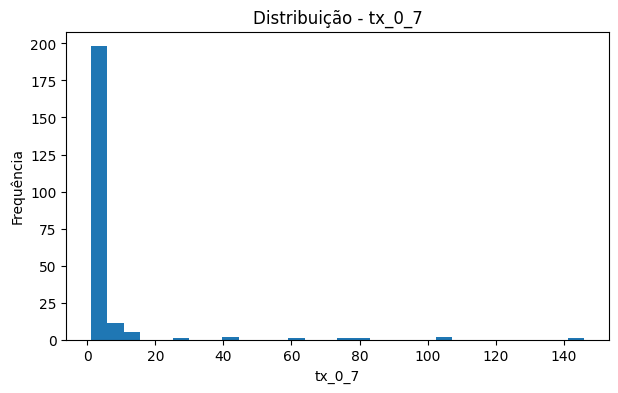

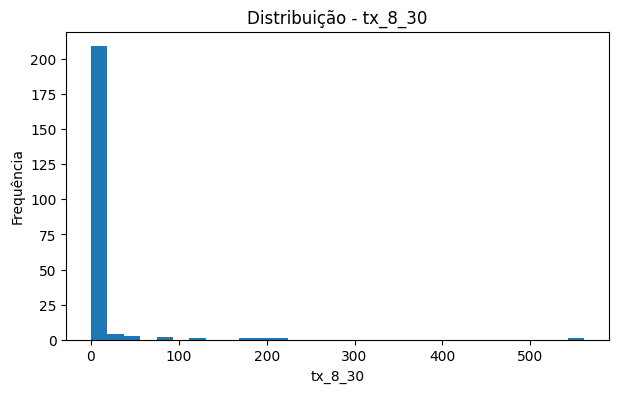

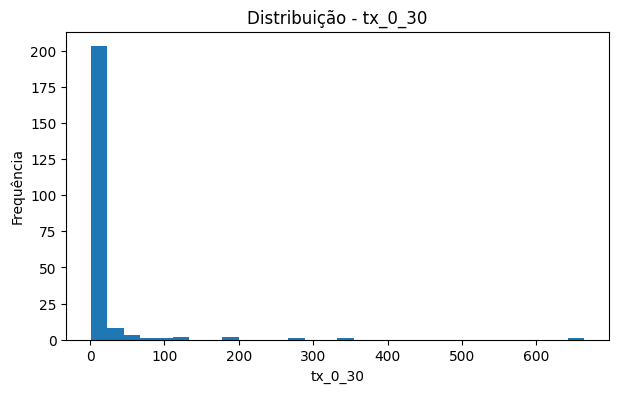

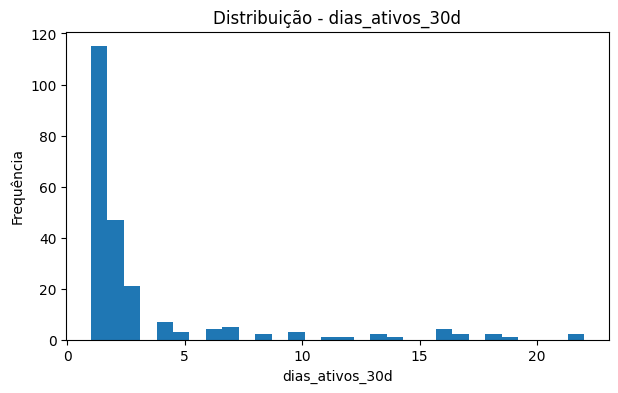

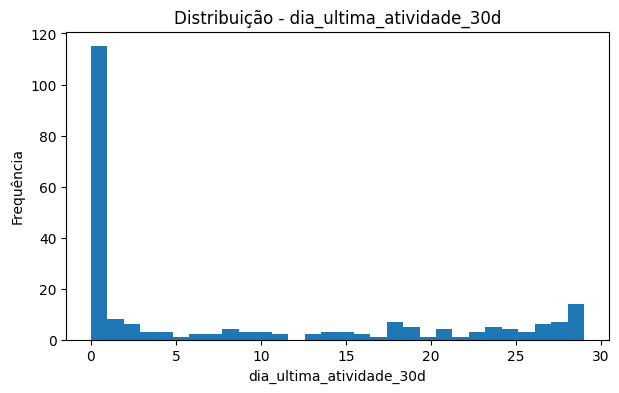

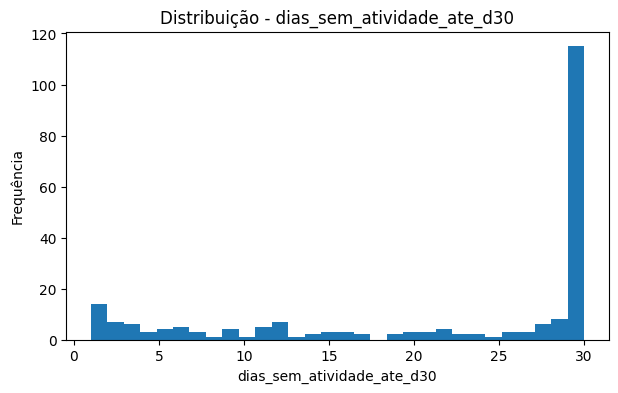

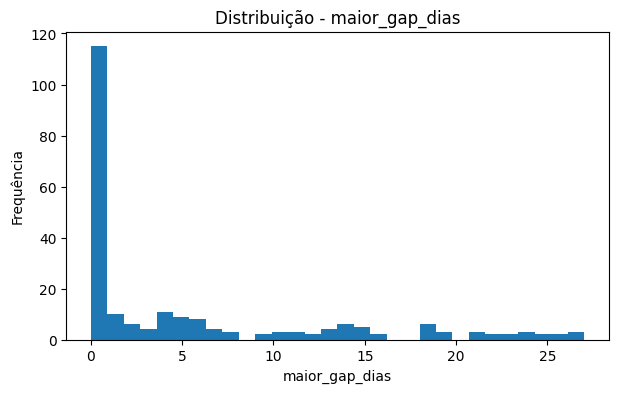

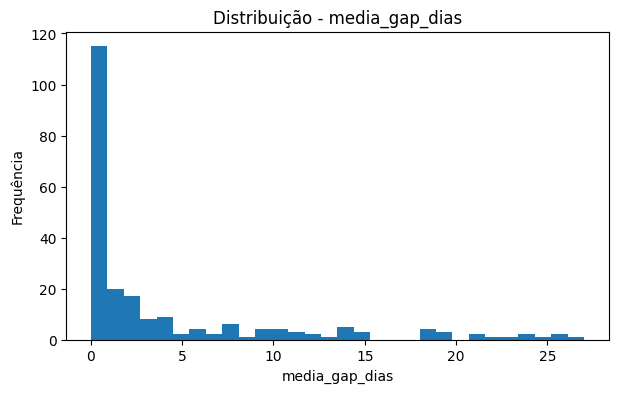

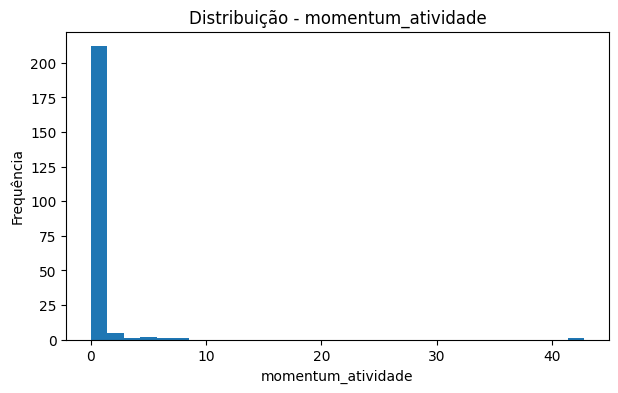

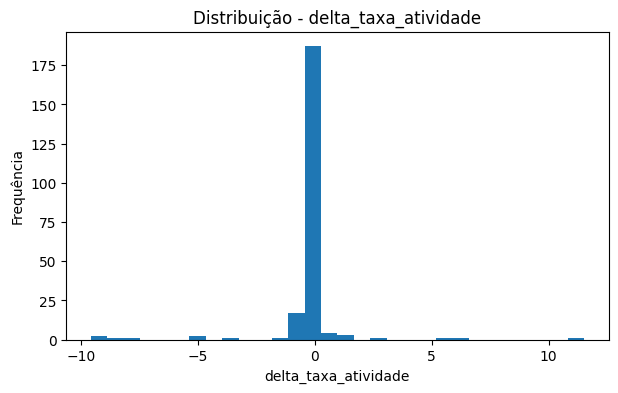

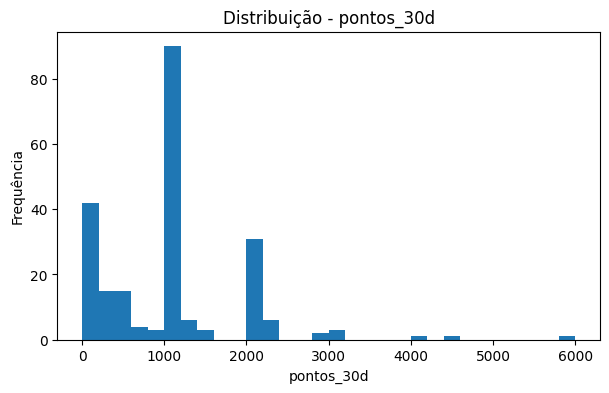

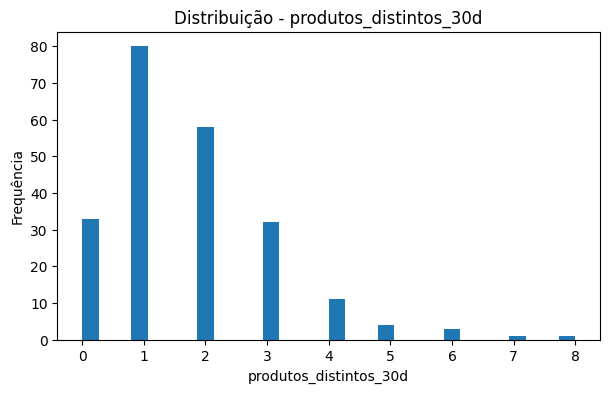

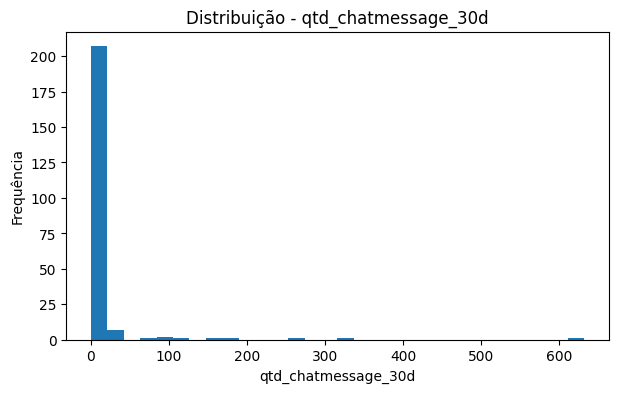

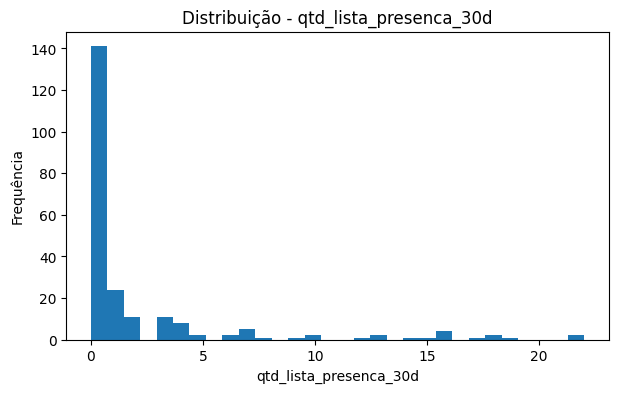

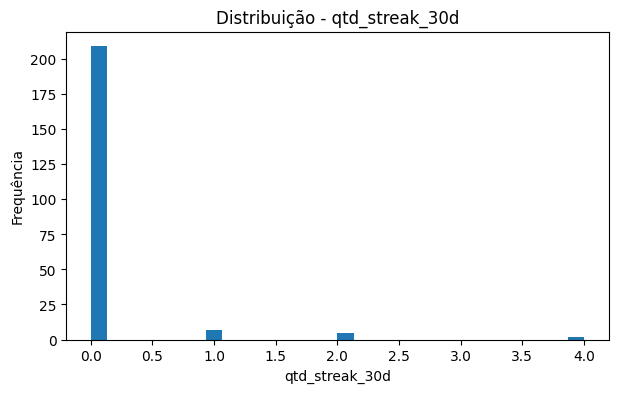

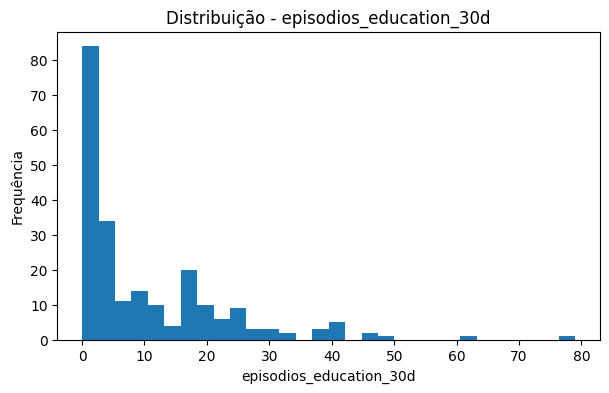

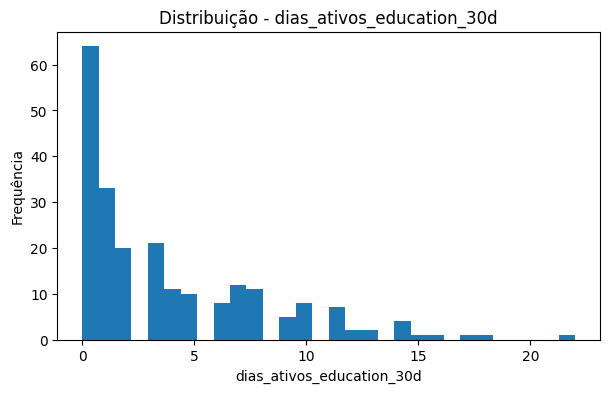

In [0]:
for col in features_eda:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[col].dropna(),
        bins=30
    )

    plt.title(f"Distribuição - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")

    plt.show()

#### Comparar Retidos × Churn



/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


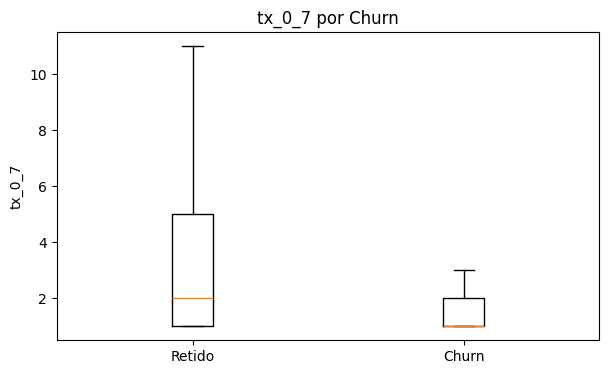

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


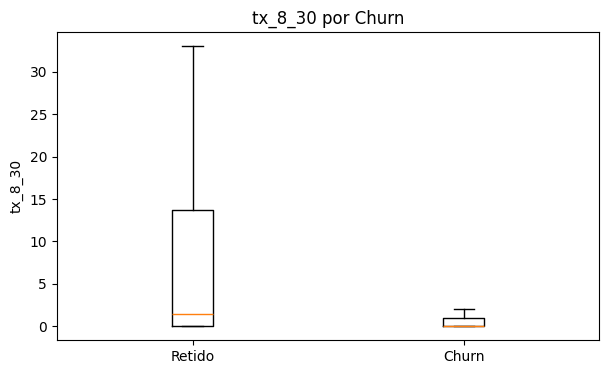

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


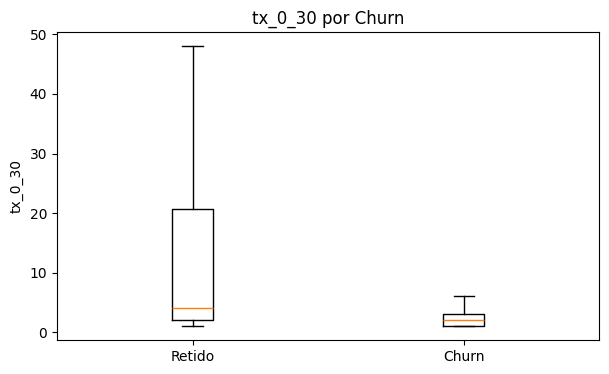

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


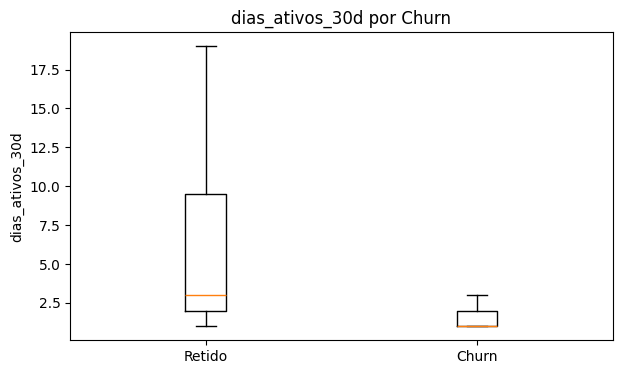

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


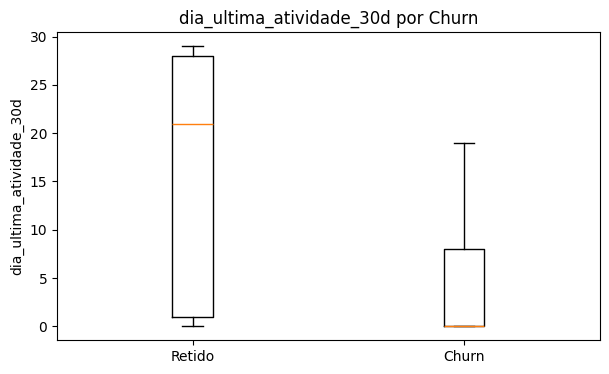

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


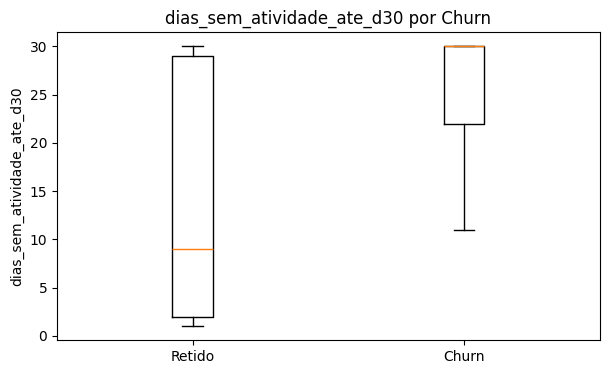

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


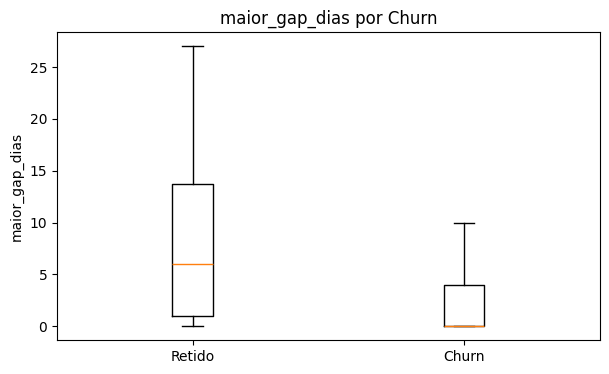

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


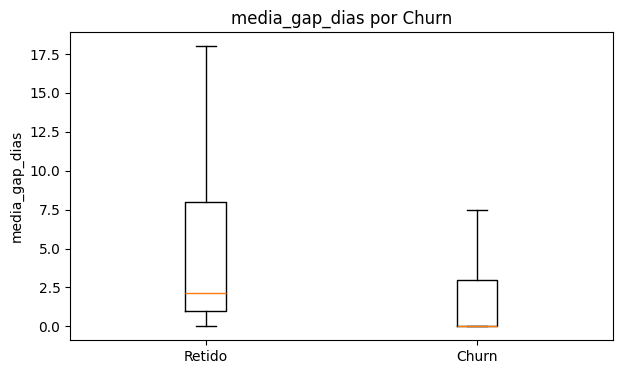

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


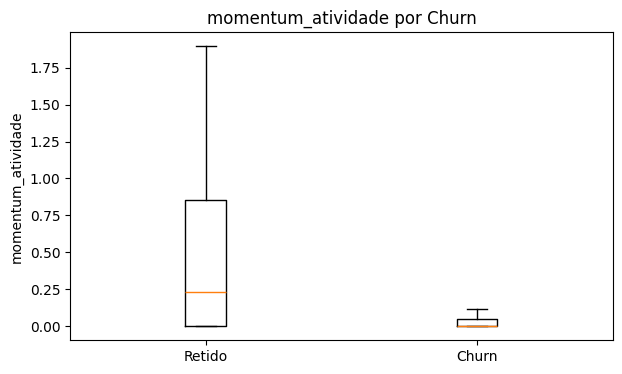

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


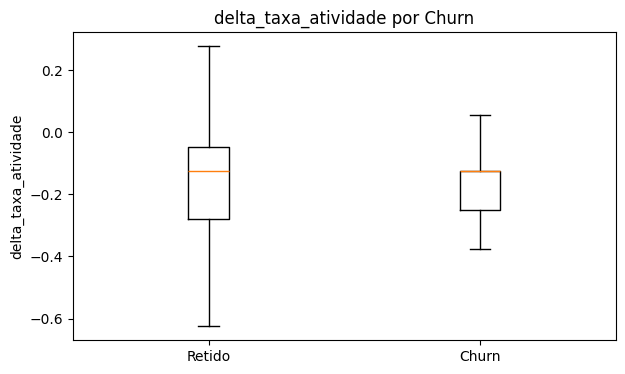

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


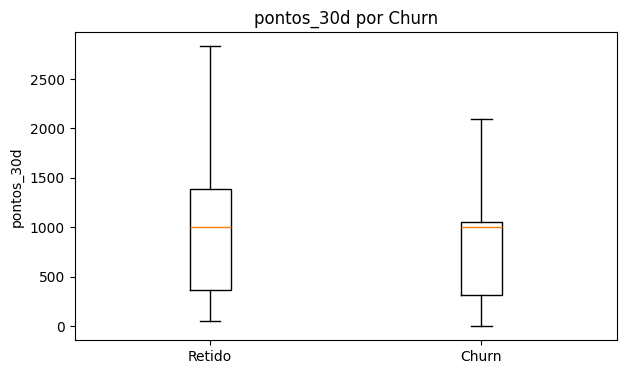

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


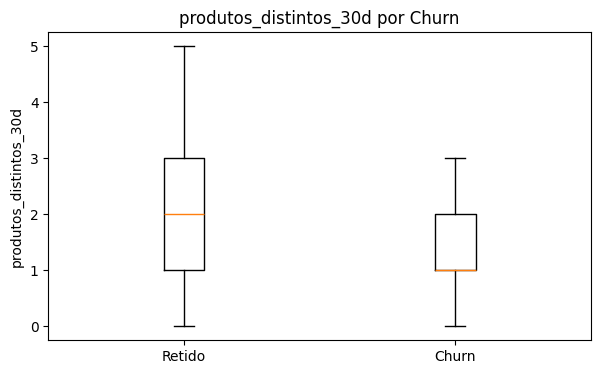

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


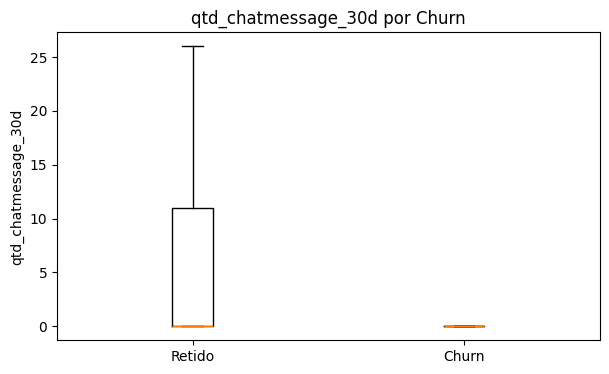

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


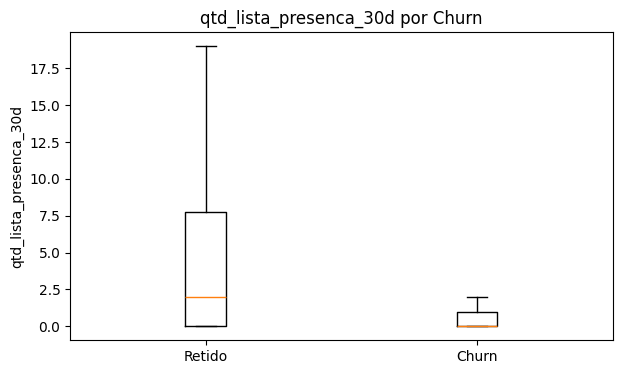

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


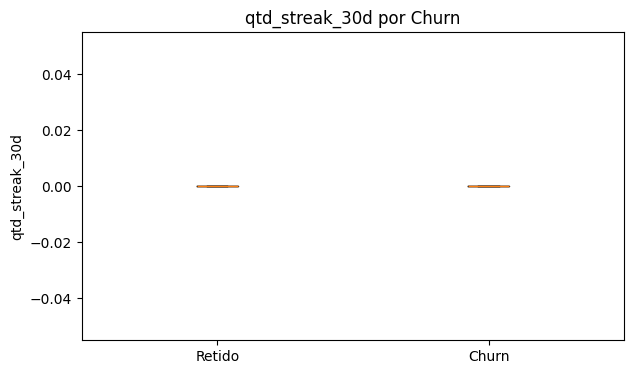

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


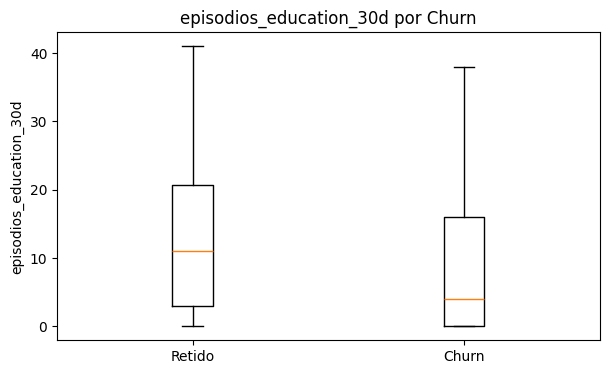

/home/spark-a0aecf9c-73c5-40d5-b14b-3d/.ipykernel/76/command-8998532787398114-4017273092:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


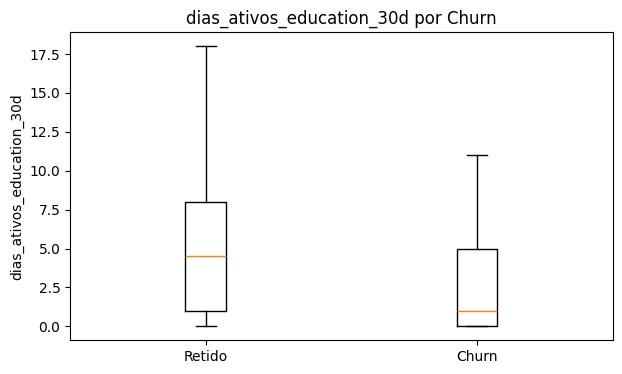

In [0]:
for col in features_eda:
    plt.figure(figsize=(7, 4))

    dados_retidos = df.loc[df["churn_90d"] == 0, col].dropna().astype(float)
    dados_churn = df.loc[df["churn_90d"] == 1, col].dropna().astype(float)

    plt.boxplot(
        [dados_retidos, dados_churn],
        labels=["Retido", "Churn"],
        showfliers=False
    )

    plt.title(f"{col} por Churn")
    plt.ylabel(col)

    plt.show()

#### Correlações
Matriz numérica


In [0]:
corr = df[features_eda + ["churn_90d"]].corr()

corr.round(2)

,tx_0_7,tx_8_30,tx_0_30,dias_ativos_30d,dia_ultima_atividade_30d,dias_sem_atividade_ate_d30,maior_gap_dias,media_gap_dias,momentum_atividade,delta_taxa_atividade,pontos_30d,produtos_distintos_30d,qtd_chatmessage_30d,qtd_lista_presenca_30d,qtd_streak_30d,episodios_education_30d,dias_ativos_education_30d,churn_90d
tx_0_7,1.00,0.67,0.81,0.58,0.33,-0.33,0.01,-0.05,0.01,-0.45,-0.03,0.28,0.81,0.59,0.62,0.00,0.01,-0.22
tx_8_30,0.67,1.00,0.98,0.64,0.35,-0.35,0.03,-0.04,0.26,0.37,-0.01,0.26,0.98,0.63,0.80,0.08,0.09,-0.25
tx_0_30,0.81,0.98,1.00,0.67,0.36,-0.36,0.02,-0.04,0.21,0.16,-0.01,0.28,1.00,0.66,0.81,0.07,0.07,-0.26
dias_ativos_30d,0.58,0.64,0.67,1.00,0.69,-0.69,0.17,0.01,0.34,0.04,0.06,0.44,0.62,0.99,0.76,0.15,0.18,-0.47
dia_ultima_atividade_30d,0.33,0.35,0.36,0.69,1.00,-1.00,0.80,0.65,0.28,0.01,0.06,0.47,0.33,0.64,0.37,0.26,0.30,-0.48
dias_sem_atividade_ate_d30,-0.33,-0.35,-0.36,-0.69,-1.00,1.00,-0.80,-0.65,-0.28,-0.01,-0.06,-0.47,-0.33,-0.64,-0.37,-0.26,-0.30,0.48
maior_gap_dias,0.01,0.03,0.02,0.17,0.80,-0.80,1.00,0.93,0.16,0.02,0.06,0.29,0.01,0.11,-0.01,0.24,0.29,-0.28
media_gap_dias,-0.05,-0.04,-0.04,0.01,0.65,-0.65,0.93,1.00,0.05,0.02,0.09,0.21,-0.05,-0.05,-0.07,0.21,0.26,-0.13
momentum_atividade,0.01,0.26,0.21,0.34,0.28,-0.28,0.16,0.05,1.00,0.31,-0.07,0.24,0.19,0.32,0.33,0.05,0.04,-0.19
delta_taxa_atividade,-0.45,0.37,0.16,0.04,0.01,-0.01,0.02,0.02,0.31,1.00,0.02,-0.03,0.16,0.02,0.19,0.09,0.10,-0.03


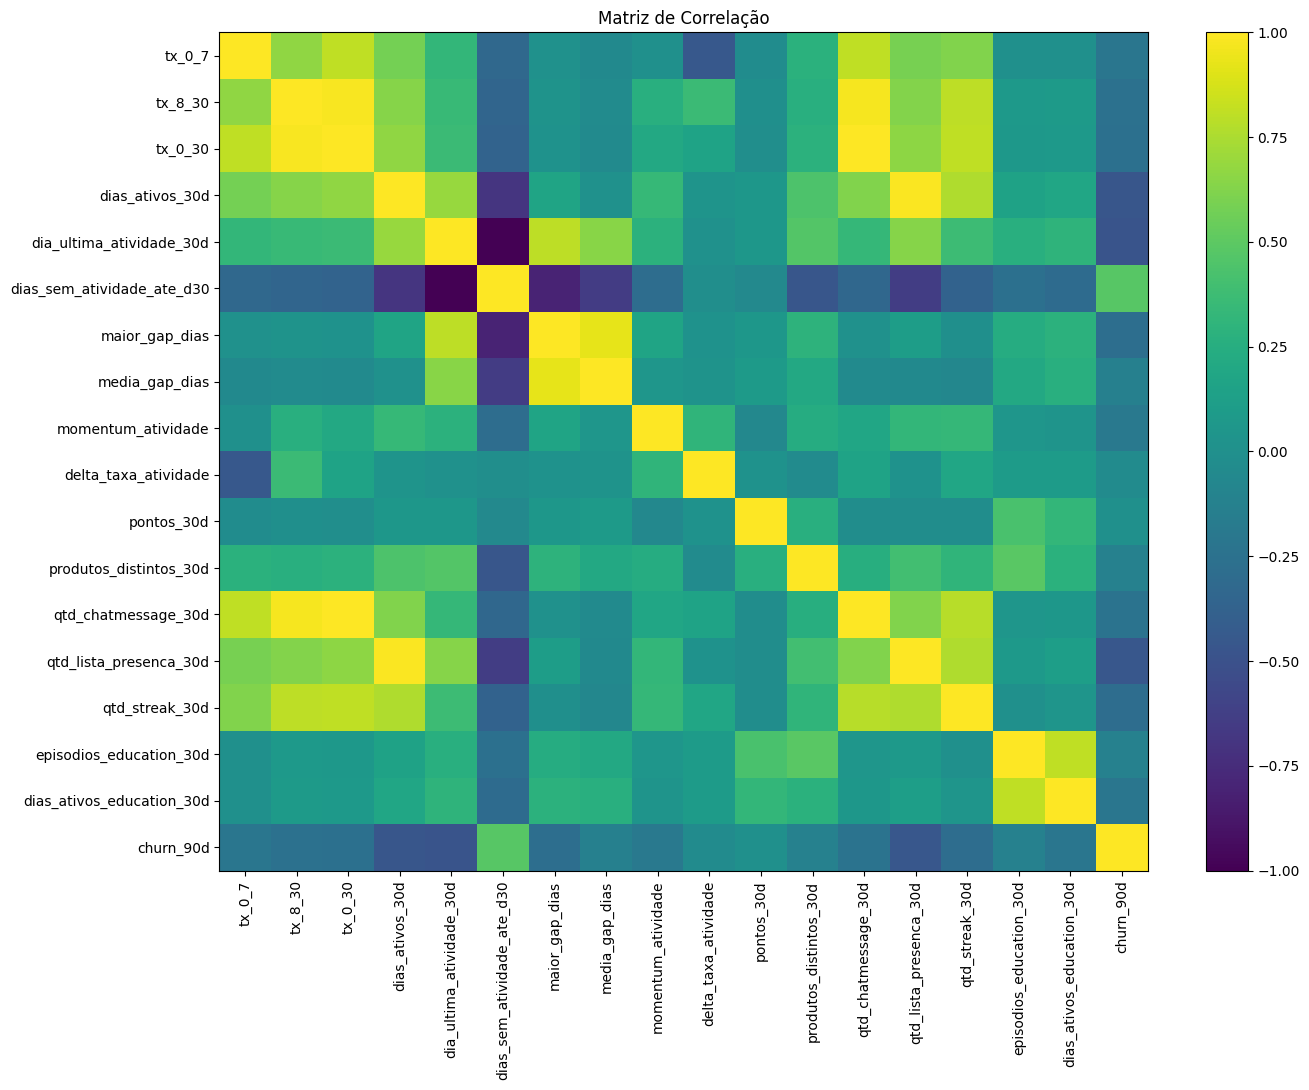

In [0]:
plt.figure(figsize=(14, 11))

plt.imshow(
    corr,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.index)),
    corr.index
)

plt.title("Matriz de Correlação")

plt.tight_layout()
plt.show()

#### Correlação individual com churn

Esta tabela será especialmente útil:


In [0]:
corr_churn = (
    corr["churn_90d"]
    .drop("churn_90d")
    .sort_values(key=abs, ascending=False)
)

corr_churn

dias_sem_atividade_ate_d30    0.477190
dia_ultima_atividade_30d     -0.477190
dias_ativos_30d              -0.468182
qtd_lista_presenca_30d       -0.455501
qtd_streak_30d               -0.285728
maior_gap_dias               -0.277019
tx_0_30                      -0.260907
tx_8_30                      -0.252997
qtd_chatmessage_30d          -0.238878
tx_0_7                       -0.217138
dias_ativos_education_30d    -0.215757
momentum_atividade           -0.190795
media_gap_dias               -0.131774
produtos_distintos_30d       -0.120985
episodios_education_30d      -0.117241
delta_taxa_atividade         -0.032796
pontos_30d                    0.002715
Name: churn_90d, dtype: float64

#### Seleção inicial de features


#### As mais interessantes para o negócio
- **dias_sem_atividade_ate_d30**

Foi provavelmente a feature mais importante do projeto.

Ela responde: “No fim dos primeiros 30 dias, há quanto tempo esse usuário já não aparece?”

Quanto maior, maior o risco.


- **dias_ativos_30d**

Não mede quantas mensagens ou transações ele realizou.
Mede em quantos dias diferentes ele voltou.

É uma excelente representação de formação de hábito.

- **log_tx_0_7**

Mede a intensidade da experiência inicial.
Mostrou que usuários mais ativos logo no início tendem a apresentar menor churn.

- **log_episodios_education_30d**
Foi particularmente interessante porque mostra que o Education acrescenta informação:
maior consumo de episódios esteve associado a maior retenção.

- **As features mais desafiadoras**


**1. Produtos/pontos**: foi necessário deduplicar IdTransacao × IdProduto para evitar multiplicação de linhas nos joins. Além disso, a escala desigual de pontos dificultou sua interpretação como engajamento.

**2. Variáveis temporais**: dias_sem_atividade, gaps e última atividade exigiam garantir que apenas dados D0–D30 fossem utilizados, evitando leakage.

**3. Education**: as atividades educacionais também precisavam ser alinhadas à janela temporal correta após a entrada no Loyalty.

E há uma feature interessante que não sobreviveu ao modelo final:

**log_tx_8_30**

Ela tinha:
- VIF alto;
- forte redundância com dias_ativos_30d;
- coeficiente praticamente zero na Logistic V1.
Foi retirada na V2.

In [0]:
features_modelo = [
    "tx_0_7",
    "tx_8_30",
    "dias_ativos_30d",
    "dias_sem_atividade_ate_d30",
    "pontos_30d",
    "produtos_distintos_30d",
    "qtd_streak_30d",
    "episodios_education_30d",
    "dias_ativos_education_30d"
]

X = df[features_modelo].copy()
y = df["churn_90d"].copy()

#### Transformar variáveis muito assimétricas

Como já vimos 'heavy users', foi preciso fazer log1p em variáveis de contagem/volume


In [0]:
features_log = [
    "tx_0_7",
    "tx_8_30",
    "pontos_30d",
    "qtd_streak_30d",
    "episodios_education_30d"
]

for col in features_log:
    X[f"log_{col}"] = np.log1p(X[col])

X = X.drop(columns=features_log)

In [0]:
X.head()

,dias_ativos_30d,dias_sem_atividade_ate_d30,produtos_distintos_30d,dias_ativos_education_30d,log_tx_0_7,log_tx_8_30,log_pontos_30d,log_qtd_streak_30d,log_episodios_education_30d
0,2,29,0,4,1.098612,0.000000,7.601402,0.000000,2.890372
1,2,9,3,10,0.693147,1.098612,7.003974,0.000000,2.944439
2,1,30,1,2,0.693147,0.000000,6.908755,0.000000,1.098612
3,19,1,3,2,4.990433,5.298317,7.296413,1.098612,1.386294
4,3,22,3,8,1.098612,0.693147,7.170888,0.000000,2.484907


In [0]:
X.shape

(223, 9)

#### Variável resposta — Y
churn_90d

churn_90d = 1
→ nenhuma transação entre D31 e D90

churn_90d = 0
→ pelo menos uma transação entre D31 e D90

A distribuição foi aproximadamente:
- 157 churners — 70,4%
- 66 retidos — 29,6%


#### Variáveis explicativas finais — X
dias_ativos_30d
dias_sem_atividade_ate_d30
produtos_distintos_30d
dias_ativos_education_30d
log_tx_0_7
log_pontos_30d
log_qtd_streak_30d
log_episodios_education_30d





### Temporal Split — Churn Prediction

```text
          OBSERVATION WINDOW                 OUTCOME WINDOW
                (PAST)                          (FUTURE)

D0 ----------------------- D30 | D31 ----------------------- D90
                              |
                              |
             X                |                Y
         Customer             |           churn_90d
         features             |
                              |
          30 days             |             60 days


          

**X → informações disponíveis até D30**


**Y → ocorrência de churn entre D31 e D90**

#### Separação treino × teste

Como a base contém apenas 223 usuários, o split deve preservar a proporção de churn nos dois conjuntos.


In [0]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [0]:
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (167, 9)
Teste: (56, 9)


In [0]:
print("Churn geral:")
print(y.value_counts(normalize=True))

print("\nChurn treino:")
print(y_train.value_counts(normalize=True))

print("\nChurn teste:")
print(y_test.value_counts(normalize=True))

Churn geral:
churn_90d
1    0.704036
0    0.295964
Name: proportion, dtype: float64

Churn treino:
churn_90d
1    0.706587
0    0.293413
Name: proportion, dtype: float64

Churn teste:
churn_90d
1    0.696429
0    0.303571
Name: proportion, dtype: float64


## I - Modelagem
### Regressão Logística


In [0]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

#### Treinar


In [0]:
modelo_logistico.fit(
    X_train,
    y_train
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

#### Predições

y_proba é especialmente importante porque representa: probabilidade estimada de churn


In [0]:
y_pred = modelo_logistico.predict(X_test)

y_proba = modelo_logistico.predict_proba(X_test)[:, 1]

#### Métricas


In [0]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print(
    "Accuracy:",
    round(accuracy_score(y_test, y_pred), 3)
)

print(
    "Precision:",
    round(precision_score(y_test, y_pred), 3)
)

print(
    "Recall:",
    round(recall_score(y_test, y_pred), 3)
)

print(
    "F1:",
    round(f1_score(y_test, y_pred), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_proba), 3)
)

Accuracy: 0.804
Precision: 0.818
Recall: 0.923
F1: 0.867
ROC-AUC: 0.796


In [0]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Retido",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

      Retido       0.75      0.53      0.62        17
       Churn       0.82      0.92      0.87        39

    accuracy                           0.80        56
   macro avg       0.78      0.73      0.74        56
weighted avg       0.80      0.80      0.79        56



#### Matriz de confusão


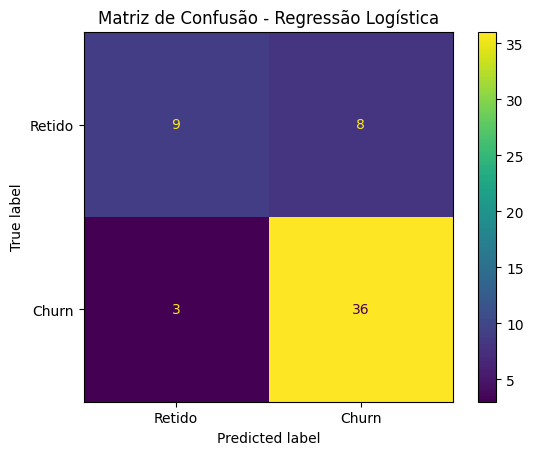

In [0]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Retido",
        "Churn"
    ]
)

disp.plot()

plt.title(
    "Matriz de Confusão - Regressão Logística"
)

plt.show()

#### ROC Curve


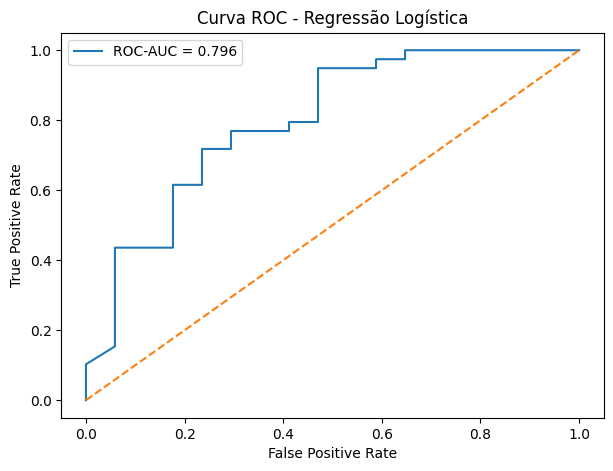

In [0]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "Curva ROC - Regressão Logística"
)

plt.legend()

plt.show()

8. Interpretar os coeficientes

Essa é uma das grandes vantagens da regressão logística.


In [0]:
coeficientes = pd.DataFrame({
    "feature": X.columns,
    "coeficiente":
        modelo_logistico
        .named_steps["modelo"]
        .coef_[0]
})

coeficientes["abs_coef"] = (
    coeficientes["coeficiente"].abs()
)

coeficientes = (
    coeficientes
    .sort_values(
        "abs_coef",
        ascending=False
    )
)

coeficientes

,feature,coeficiente,abs_coef
1,dias_sem_atividade_ate_d30,0.830566,0.830566
0,dias_ativos_30d,-0.741940,0.741940
2,produtos_distintos_30d,0.660826,0.660826
8,log_episodios_education_30d,-0.460730,0.460730
4,log_tx_0_7,-0.396355,0.396355
7,log_qtd_streak_30d,0.134714,0.134714
6,log_pontos_30d,-0.066157,0.066157
5,log_tx_8_30,0.047448,0.047448
3,dias_ativos_education_30d,-0.037657,0.037657


#### Uma validação adicional 

Como temos apenas 223 registros, uma única divisão treino/teste pode produzir resultado instável.




In [0]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_auc = cross_val_score(
    modelo_logistico,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(
    "ROC-AUC por fold:",
    np.round(scores_auc, 3)
)

print(
    "ROC-AUC médio:",
    round(scores_auc.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_auc.std(), 3)
)

ROC-AUC por fold: [0.751 0.843 0.848 0.689 0.811]
ROC-AUC médio: 0.788
Desvio padrão: 0.061


#### Antes da árvore de decisão, duas verificações.

1. Cross-validation - Essa é agora a validação mais importante:


In [0]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_auc = cross_val_score(
    modelo_logistico,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("ROC-AUC por fold:")
print(np.round(scores_auc, 3))

print(
    "\nROC-AUC médio:",
    round(scores_auc.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_auc.std(), 3)
)

ROC-AUC por fold:
[0.751 0.843 0.848 0.689 0.811]

ROC-AUC médio: 0.788
Desvio padrão: 0.061


2. Coeficientes: checar o que o modelo aprendeu.


In [0]:
coeficientes = pd.DataFrame({
    "feature": X.columns,
    "coeficiente":
        modelo_logistico
        .named_steps["modelo"]
        .coef_[0]
})

coeficientes["abs_coef"] = (
    coeficientes["coeficiente"].abs()
)

coeficientes.sort_values(
    "abs_coef",
    ascending=False
)

,feature,coeficiente,abs_coef
1,dias_sem_atividade_ate_d30,0.830566,0.830566
0,dias_ativos_30d,-0.741940,0.741940
2,produtos_distintos_30d,0.660826,0.660826
8,log_episodios_education_30d,-0.460730,0.460730
4,log_tx_0_7,-0.396355,0.396355
7,log_qtd_streak_30d,0.134714,0.134714
6,log_pontos_30d,-0.066157,0.066157
5,log_tx_8_30,0.047448,0.047448
3,dias_ativos_education_30d,-0.037657,0.037657


#### Alerta: multicolinearidade provável



In [0]:
#%pip install statsmodels

In [0]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X.copy()

vif = pd.DataFrame()

vif["feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif.sort_values(
    "VIF",
    ascending=False
)

,feature,VIF
0,dias_ativos_30d,7.541240
5,log_tx_8_30,7.263020
1,dias_sem_atividade_ate_d30,3.400553
8,log_episodios_education_30d,3.372468
7,log_qtd_streak_30d,3.120553
3,dias_ativos_education_30d,3.056107
4,log_tx_0_7,2.423520
2,produtos_distintos_30d,1.687935
6,log_pontos_30d,1.151157


#### Tratamento da multicolinearidade

Vamos eliminar:  **log_tx_8_30**

Entre as duas, vamos manter: **dias_ativos_30d**

porque:

apresentou forte relação com churn em toda a EDA;
possui interpretação de negócio muito melhor;
apareceu com coeficiente forte na regressão;
permitiu encontrar a regra dos 8+ dias ativos;
mede recorrência, não apenas volume.

Já log_tx_8_30:

tem VIF alto;
coeficiente praticamente zero;
é altamente influenciada por heavy users;
é menos intuitiva para uma regra operacional.
Regressão logística V2

Vamos criar uma nova feature set sem log_tx_8_30


#### MLflow — rastreamento dos experimentos

A partir desta etapa, os experimentos passam a ser registrados no MLflow.


In [0]:
import mlflow
import mlflow.sklearn

# Experimento específico para o case
mlflow.set_experiment("/Shared/TMW_Churn_Loyalty")

print("MLflow version:", mlflow.__version__)

MLflow version: 3.8.1


In [0]:
features_modelo_v2 = [
    "dias_ativos_30d",
    "dias_sem_atividade_ate_d30",
    "produtos_distintos_30d",
    "dias_ativos_education_30d",
    "log_tx_0_7",
    "log_pontos_30d",
    "log_qtd_streak_30d",
    "log_episodios_education_30d"
]

X_v2 = X[features_modelo_v2].copy()

In [0]:
from sklearn.model_selection import train_test_split

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [0]:
# Evita conflito caso alguma run anterior tenha ficado aberta
if mlflow.active_run():
    mlflow.end_run()

run = mlflow.start_run(
    run_name="LogisticRegression_V2"
)

print("Run ID:", run.info.run_id)

Run ID: 7cb80cf48c4c4986ab57b0b3fd03748d


Ainda nessa célula, vamos adicionar os principais parâmetros e tags:


In [0]:
mlflow.log_params({
    "algorithm": "LogisticRegression",
    "test_size": 0.25,
    "random_state": 42,
    "max_iter": 1000,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "Logistic Regression V2",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

'dias_ativos_30d, dias_sem_atividade_ate_d30, produtos_distintos_30d, dias_ativos_education_30d, log_tx_0_7, log_pontos_30d, log_qtd_streak_30d, log_episodios_education_30d'

#### Modelo: Regressão Logística, versão 2


In [0]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo_logistico_v2 = Pipeline([
    ("scaler", StandardScaler()),
    (
        "modelo",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

modelo_logistico_v2.fit(
    X_train_v2,
    y_train_v2
)

Pipeline(steps=[('scaler', StandardScaler()),
                ('modelo', LogisticRegression(max_iter=1000, random_state=42))])

#### Predições:


In [0]:
y_pred_v2 = modelo_logistico_v2.predict(X_test_v2)

y_proba_v2 = (
    modelo_logistico_v2
    .predict_proba(X_test_v2)[:, 1]
)

Comparando com o modelo original:


In [0]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy_v2 = accuracy_score(
    y_test_v2,
    y_pred_v2
)

precision_v2 = precision_score(
    y_test_v2,
    y_pred_v2
)

recall_v2 = recall_score(
    y_test_v2,
    y_pred_v2
)

f1_v2 = f1_score(
    y_test_v2,
    y_pred_v2
)

roc_auc_v2 = roc_auc_score(
    y_test_v2,
    y_proba_v2
)

print("MODELO V2")
print("Accuracy:", round(accuracy_v2, 3))
print("Precision:", round(precision_v2, 3))
print("Recall:", round(recall_v2, 3))
print("F1:", round(f1_v2, 3))
print("ROC-AUC:", round(roc_auc_v2, 3))

MODELO V2
Accuracy: 0.804
Precision: 0.818
Recall: 0.923
F1: 0.867
ROC-AUC: 0.798


In [0]:
mlflow.log_metrics({
    "accuracy_test": accuracy_v2,
    "precision_test": precision_v2,
    "recall_test": recall_v2,
    "f1_test": f1_v2,
    "roc_auc_test": roc_auc_v2
})

#### Recalculando o VIF


In [0]:
from sklearn.linear_model import LinearRegression
import pandas as pd

vif_resultados = []

for feature in X_v2.columns:

    y_vif = X_v2[feature]

    X_outros = X_v2.drop(
        columns=[feature]
    )

    modelo_vif = LinearRegression()

    modelo_vif.fit(
        X_outros,
        y_vif
    )

    r2 = modelo_vif.score(
        X_outros,
        y_vif
    )

    vif_valor = 1 / (1 - r2)

    vif_resultados.append({
        "feature": feature,
        "VIF": vif_valor
    })

vif_v2 = pd.DataFrame(
    vif_resultados
)

vif_v2.sort_values(
    "VIF",
    ascending=False
)

,feature,VIF
0,dias_ativos_30d,5.636211
7,log_episodios_education_30d,3.352188
6,log_qtd_streak_30d,3.115303
3,dias_ativos_education_30d,3.042999
1,dias_sem_atividade_ate_d30,2.407109
4,log_tx_0_7,2.357725
2,produtos_distintos_30d,1.663525
5,log_pontos_30d,1.151126


In [0]:
mlflow.log_metric(
    "max_vif",
    vif_v2["VIF"].max()
)

Salvando a tabela completa


In [0]:
vif_v2.to_csv(
    "/tmp/vif_v2.csv",
    index=False
)

mlflow.log_artifact(
    "/tmp/vif_v2.csv",
    artifact_path="diagnostics"
)

In [0]:
# 1. Recalcular VIF no V2
from sklearn.linear_model import LinearRegression
import pandas as pd

vif_resultados = []

for feature in X_v2.columns:
    y_vif = X_v2[feature]
    X_outros = X_v2.drop(columns=[feature])

    modelo_vif = LinearRegression()
    modelo_vif.fit(X_outros, y_vif)

    r2 = modelo_vif.score(X_outros, y_vif)
    vif_valor = 1 / (1 - r2)

    vif_resultados.append({
        "feature": feature,
        "VIF": vif_valor
    })

vif_v2 = pd.DataFrame(vif_resultados)

vif_v2.sort_values(
    "VIF",
    ascending=False
)

,feature,VIF
0,dias_ativos_30d,5.636211
7,log_episodios_education_30d,3.352188
6,log_qtd_streak_30d,3.115303
3,dias_ativos_education_30d,3.042999
1,dias_sem_atividade_ate_d30,2.407109
4,log_tx_0_7,2.357725
2,produtos_distintos_30d,1.663525
5,log_pontos_30d,1.151126


E depois uma validação cruzada estratificada de 5 folds, que para nossa base pequena é mais importante do que olhar apenas esse único split:


In [0]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_auc = cross_val_score(
    modelo_logistico_v2,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

mlflow.log_metrics({
    "roc_auc_cv_mean": scores_auc.mean(),
    "roc_auc_cv_std": scores_auc.std()
})

for i, score in enumerate(
    scores_auc,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        score
    )

print("ROC-AUC por fold:", np.round(scores_auc, 3))
print("ROC-AUC médio:", round(scores_auc.mean(), 3))
print("Desvio padrão:", round(scores_auc.std(), 3))

ROC-AUC por fold: [0.751 0.843 0.855 0.703 0.819]
ROC-AUC médio: 0.794
Desvio padrão: 0.058


Coeficientes definitivos do V2: estraindo os coeficientes do modelo mais enxuto


In [0]:
coef_v2 = pd.DataFrame({
    "feature": X_v2.columns,
    "coeficiente":
        modelo_logistico_v2
        .named_steps["modelo"]
        .coef_[0]
})

coef_v2["odds_ratio"] = np.exp(
    coef_v2["coeficiente"]
)

coef_v2["abs_coef"] = (
    coef_v2["coeficiente"].abs()
)

coef_v2 = coef_v2.sort_values(
    "abs_coef",
    ascending=False
)

coef_v2

,feature,coeficiente,odds_ratio,abs_coef
1,dias_sem_atividade_ate_d30,0.812021,2.252455,0.812021
0,dias_ativos_30d,-0.718331,0.487565,0.718331
2,produtos_distintos_30d,0.662231,1.939113,0.662231
7,log_episodios_education_30d,-0.460227,0.631140,0.460227
4,log_tx_0_7,-0.390481,0.676732,0.390481
6,log_qtd_streak_30d,0.128879,1.137553,0.128879
5,log_pontos_30d,-0.067371,0.934848,0.067371
3,dias_ativos_education_30d,-0.038167,0.962552,0.038167


In [0]:
coef_v2.to_csv(
    "/tmp/coeficientes_logistic_v2.csv",
    index=False
)

mlflow.log_artifact(
    "/tmp/coeficientes_logistic_v2.csv",
    artifact_path="interpretability"
)

Run encontrada: 7cb80cf48c4c4986ab57b0b3fd03748d


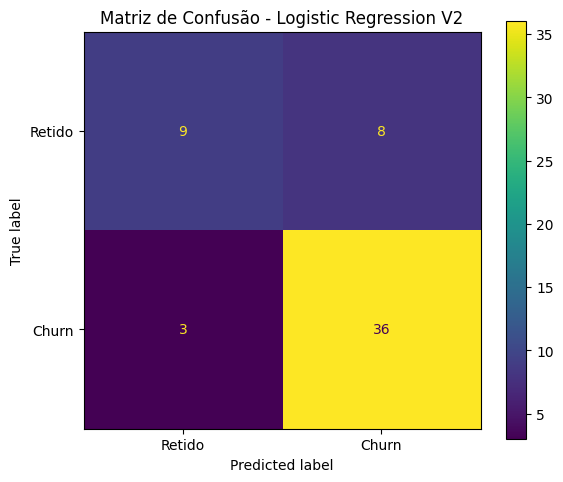

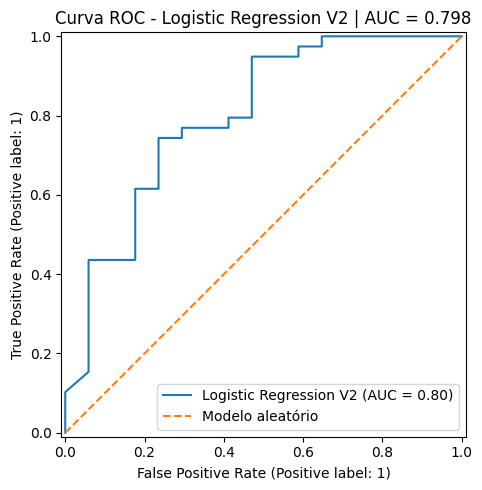

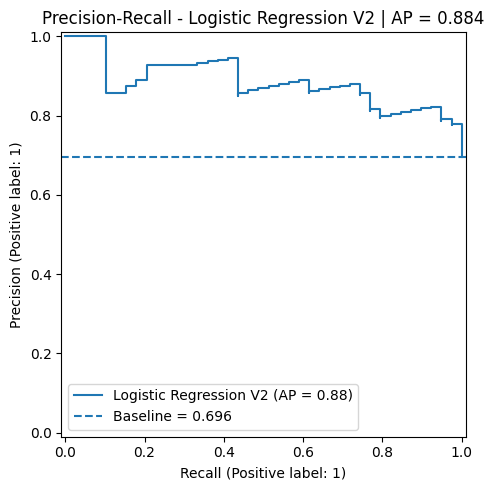

Artefatos adicionados à LogisticRegression_V2.


In [0]:
import mlflow
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    roc_auc_score,
    average_precision_score
)

# ============================================================
# 1. Localiza a Run existente da LogisticRegression_V2
# ============================================================

experiment = mlflow.get_experiment_by_name(
    "/Shared/TMW_Churn_Loyalty"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'LogisticRegression_V2'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

run_id_v2 = runs.iloc[0]["run_id"]

print("Run encontrada:", run_id_v2)


# ============================================================
# 2. Reabre a MESMA Run
# ============================================================

if mlflow.active_run():
    mlflow.end_run()


with mlflow.start_run(run_id=run_id_v2):

    # ========================================================
    # MATRIZ DE CONFUSÃO
    # ========================================================

    cm = confusion_matrix(
        y_test_v2,
        y_pred_v2
    )

    tn, fp, fn, tp = cm.ravel()

    fig_cm, ax = plt.subplots(
        figsize=(6, 5)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Retido",
            "Churn"
        ]
    ).plot(
        ax=ax,
        values_format="d"
    )

    ax.set_title(
        "Matriz de Confusão - Logistic Regression V2"
    )

    fig_cm.tight_layout()

    mlflow.log_figure(
        fig_cm,
        "plots/confusion_matrix_v2.png"
    )

    plt.show()
    plt.close(fig_cm)


    # ========================================================
    # CURVA ROC
    # ========================================================

    roc_auc_v2 = roc_auc_score(
        y_test_v2,
        y_proba_v2
    )

    fig_roc, ax = plt.subplots(
        figsize=(7, 5)
    )

    RocCurveDisplay.from_predictions(
        y_test_v2,
        y_proba_v2,
        name="Logistic Regression V2",
        ax=ax
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Modelo aleatório"
    )

    ax.set_title(
        f"Curva ROC - Logistic Regression V2 | AUC = {roc_auc_v2:.3f}"
    )

    ax.legend()

    fig_roc.tight_layout()

    mlflow.log_figure(
        fig_roc,
        "plots/roc_curve_v2.png"
    )

    plt.show()
    plt.close(fig_roc)


    # ========================================================
    # CURVA PRECISION-RECALL
    # ========================================================

    average_precision_v2 = average_precision_score(
        y_test_v2,
        y_proba_v2
    )

    fig_pr, ax = plt.subplots(
        figsize=(7, 5)
    )

    PrecisionRecallDisplay.from_predictions(
        y_test_v2,
        y_proba_v2,
        name="Logistic Regression V2",
        ax=ax
    )

    baseline = y_test_v2.mean()

    ax.axhline(
        y=baseline,
        linestyle="--",
        label=f"Baseline = {baseline:.3f}"
    )

    ax.set_title(
        "Precision-Recall - Logistic Regression V2"
        f" | AP = {average_precision_v2:.3f}"
    )

    ax.legend()

    fig_pr.tight_layout()

    mlflow.log_figure(
        fig_pr,
        "plots/precision_recall_curve_v2.png"
    )

    plt.show()
    plt.close(fig_pr)


    # ========================================================
    # MÉTRICAS COMPLEMENTARES
    # ========================================================

    mlflow.log_metrics({
        "average_precision_test": average_precision_v2,
        "true_positive_test": int(tp),
        "true_negative_test": int(tn),
        "false_positive_test": int(fp),
        "false_negative_test": int(fn)
    })


print("Artefatos adicionados à LogisticRegression_V2.")

In [0]:
from mlflow.models import infer_signature

signature = infer_signature(
    X_train_v2,
    modelo_logistico_v2.predict(
        X_train_v2
    )
)

input_example = X_train_v2.head(5)

# Reabre a run para registrar o modelo
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_id=run_id_v2):
    mlflow.sklearn.log_model(
        sk_model=modelo_logistico_v2,
        artifact_path="model",
        signature=signature,
        input_example=input_example
    )

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:30:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-1025998145ea4041bfcde

In [0]:
active = mlflow.active_run()

if active is not None:
    run_id = active.info.run_id
    mlflow.end_run()
else:
    run_id = run_id_v2

print(
    "Execução registrada com sucesso."
)

print(
    "Run ID:",
    run_id
)

Execução registrada com sucesso.
Run ID: 7cb80cf48c4c4986ab57b0b3fd03748d


#### Modelo: Árvore de Decisão

Segundo modelo do estudo, utilizado principalmente como apoio à interpretação e comunicação das regras de negócio.


In [0]:
import mlflow
import mlflow.sklearn

if mlflow.active_run():
    mlflow.end_run()

run_arvore = mlflow.start_run(
    run_name="DecisionTree_V1"
)

print("Run ID:", run_arvore.info.run_id)

mlflow.log_params({
    "algorithm": "DecisionTreeClassifier",
    "max_depth": 3,
    "min_samples_leaf": 10,
    "class_weight": "None",
    "random_state": 42,
    "test_size": 0.25,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "Decision Tree V1",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

Run ID: 24733d18263a48f780b081975d85fd86


In [0]:
from sklearn.tree import DecisionTreeClassifier

modelo_arvore = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=10,
    class_weight=None,
    random_state=42
)

modelo_arvore.fit(
    X_train_v2,
    y_train_v2
)

y_pred_arvore = modelo_arvore.predict(
    X_test_v2
)

y_proba_arvore = modelo_arvore.predict_proba(
    X_test_v2
)[:, 1]

#### Avaliação


In [0]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

accuracy_arvore = accuracy_score(
    y_test_v2,
    y_pred_arvore
)

precision_arvore = precision_score(
    y_test_v2,
    y_pred_arvore
)

recall_arvore = recall_score(
    y_test_v2,
    y_pred_arvore
)

f1_arvore = f1_score(
    y_test_v2,
    y_pred_arvore
)

roc_auc_arvore = roc_auc_score(
    y_test_v2,
    y_proba_arvore
)

average_precision_arvore = average_precision_score(
    y_test_v2,
    y_proba_arvore
)

print("ÁRVORE DE DECISÃO")
print("Accuracy:", round(accuracy_arvore, 3))
print("Precision:", round(precision_arvore, 3))
print("Recall:", round(recall_arvore, 3))
print("F1:", round(f1_arvore, 3))
print("ROC-AUC:", round(roc_auc_arvore, 3))

mlflow.log_metrics({
    "accuracy_test": accuracy_arvore,
    "precision_test": precision_arvore,
    "recall_test": recall_arvore,
    "f1_test": f1_arvore,
    "roc_auc_test": roc_auc_arvore,
    "average_precision_test": average_precision_arvore
})

ÁRVORE DE DECISÃO
Accuracy: 0.804
Precision: 0.818
Recall: 0.923
F1: 0.867
ROC-AUC: 0.703


#### Vamos visualizar a árvore


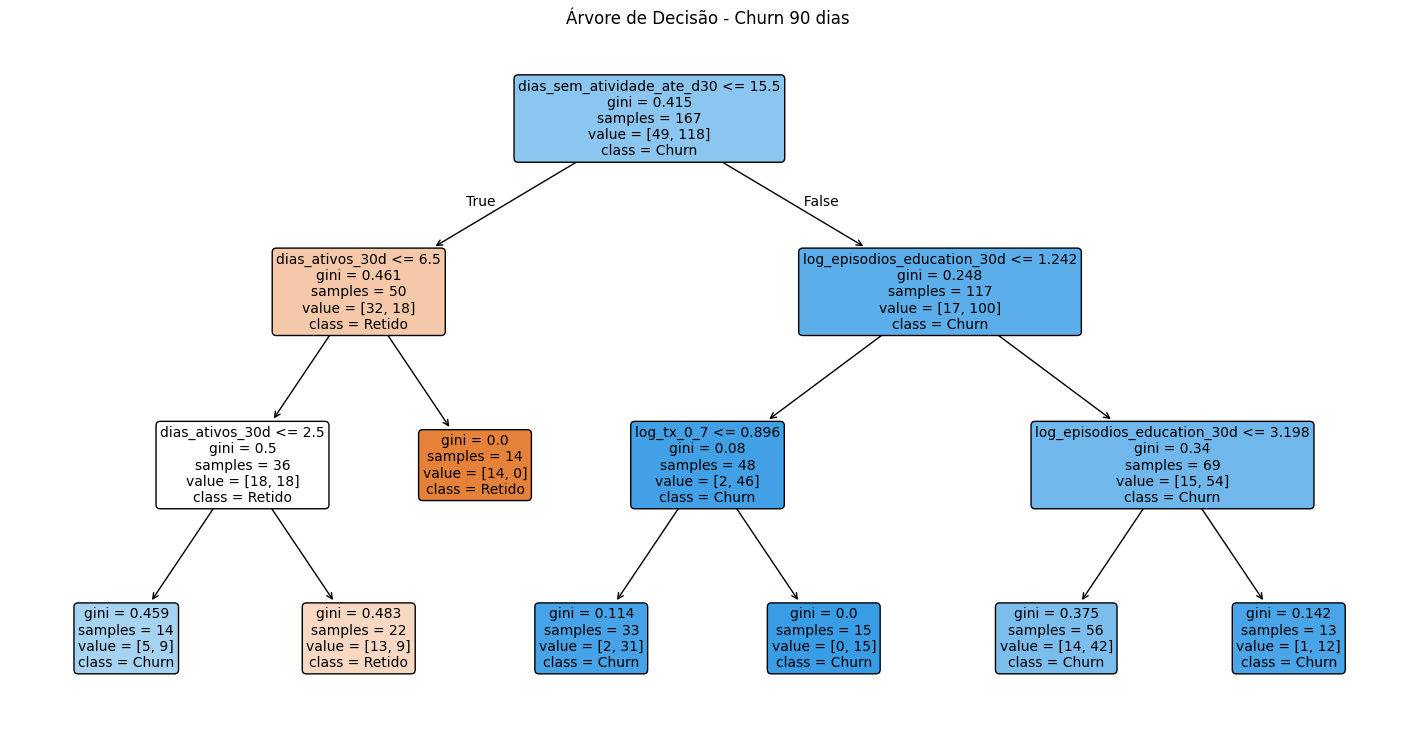

In [0]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

plot_tree(
    modelo_arvore,
    feature_names=X_v2.columns,
    class_names=["Retido", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árvore de Decisão - Churn 90 dias")

plt.show()

#### importância das features


In [0]:
import pandas as pd

importancias = pd.DataFrame({
    "feature": X_v2.columns,
    "importancia": modelo_arvore.feature_importances_
})

importancias = (
    importancias
    .sort_values("importancia", ascending=False)
)

importancias

,feature,importancia
1,dias_sem_atividade_ate_d30,0.670359
0,dias_ativos_30d,0.233612
7,log_episodios_education_30d,0.093066
4,log_tx_0_7,0.002962
2,produtos_distintos_30d,0.000000
3,dias_ativos_education_30d,0.000000
5,log_pontos_30d,0.000000
6,log_qtd_streak_30d,0.000000


#### Cross-validation da árvore


In [0]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_arvore = cross_val_score(
    modelo_arvore,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(
    "ROC-AUC por fold:",
    np.round(scores_arvore, 3)
)

print(
    "ROC-AUC médio:",
    round(scores_arvore.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_arvore.std(), 3)
)

ROC-AUC por fold: [0.66  0.829 0.642 0.733 0.744]
ROC-AUC médio: 0.722
Desvio padrão: 0.067


#### Feature importance da árvore


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

importancias_arvore = pd.DataFrame({
    "feature": X_v2.columns,
    "importancia": modelo_arvore.feature_importances_
})

importancias_arvore = (
    importancias_arvore
    .sort_values("importancia", ascending=False)
    .reset_index(drop=True)
)

importancias_arvore

,feature,importancia
0,dias_sem_atividade_ate_d30,0.670359
1,dias_ativos_30d,0.233612
2,log_episodios_education_30d,0.093066
3,log_tx_0_7,0.002962
4,produtos_distintos_30d,0.000000
5,dias_ativos_education_30d,0.000000
6,log_pontos_30d,0.000000
7,log_qtd_streak_30d,0.000000


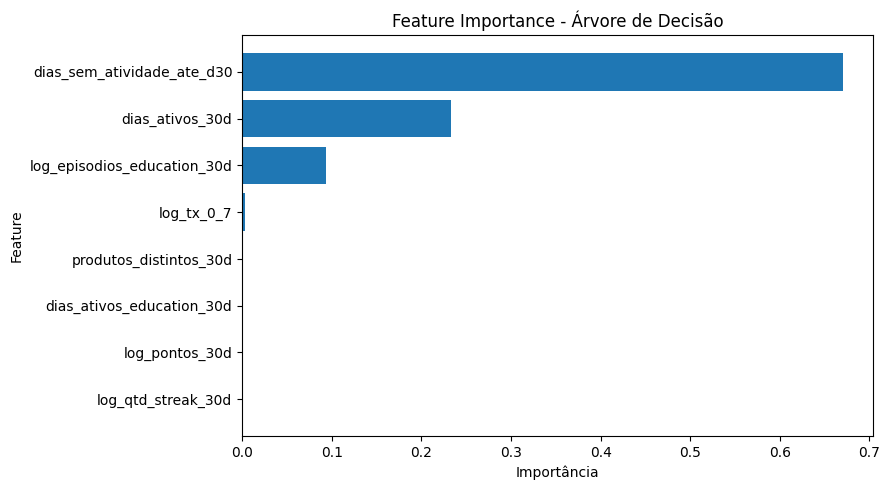

In [0]:
plt.figure(figsize=(9, 5))

plt.barh(
    importancias_arvore["feature"],
    importancias_arvore["importancia"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importância")
plt.ylabel("Feature")
plt.title("Feature Importance - Árvore de Decisão")

plt.tight_layout()
plt.show()

In [0]:
importancias_arvore["importancia"].sum()

np.float64(1.0000000000000002)

#### Cross-validation da árvore

Vamos usar exatamente a mesma estratégia da regressão logística para permitir comparação justa:


In [0]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_arvore_auc = cross_val_score(
    modelo_arvore,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

print(
    "ROC-AUC por fold:",
    np.round(scores_arvore_auc, 3)
)

print(
    "ROC-AUC médio:",
    round(scores_arvore_auc.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_arvore_auc.std(), 3)
)

print(
    "Mínimo:",
    round(scores_arvore_auc.min(), 3)
)

print(
    "Máximo:",
    round(scores_arvore_auc.max(), 3)
)

ROC-AUC por fold: [0.66  0.829 0.642 0.733 0.744]
ROC-AUC médio: 0.722
Desvio padrão: 0.067
Mínimo: 0.642
Máximo: 0.829


In [0]:
mlflow.log_metrics({
    "roc_auc_cv_mean":
        float(scores_arvore_auc.mean()),

    "roc_auc_cv_std":
        float(scores_arvore_auc.std()),

    "roc_auc_cv_min":
        float(scores_arvore_auc.min()),

    "roc_auc_cv_max":
        float(scores_arvore_auc.max())
})

for i, score in enumerate(
    scores_arvore_auc,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        float(score)
    )

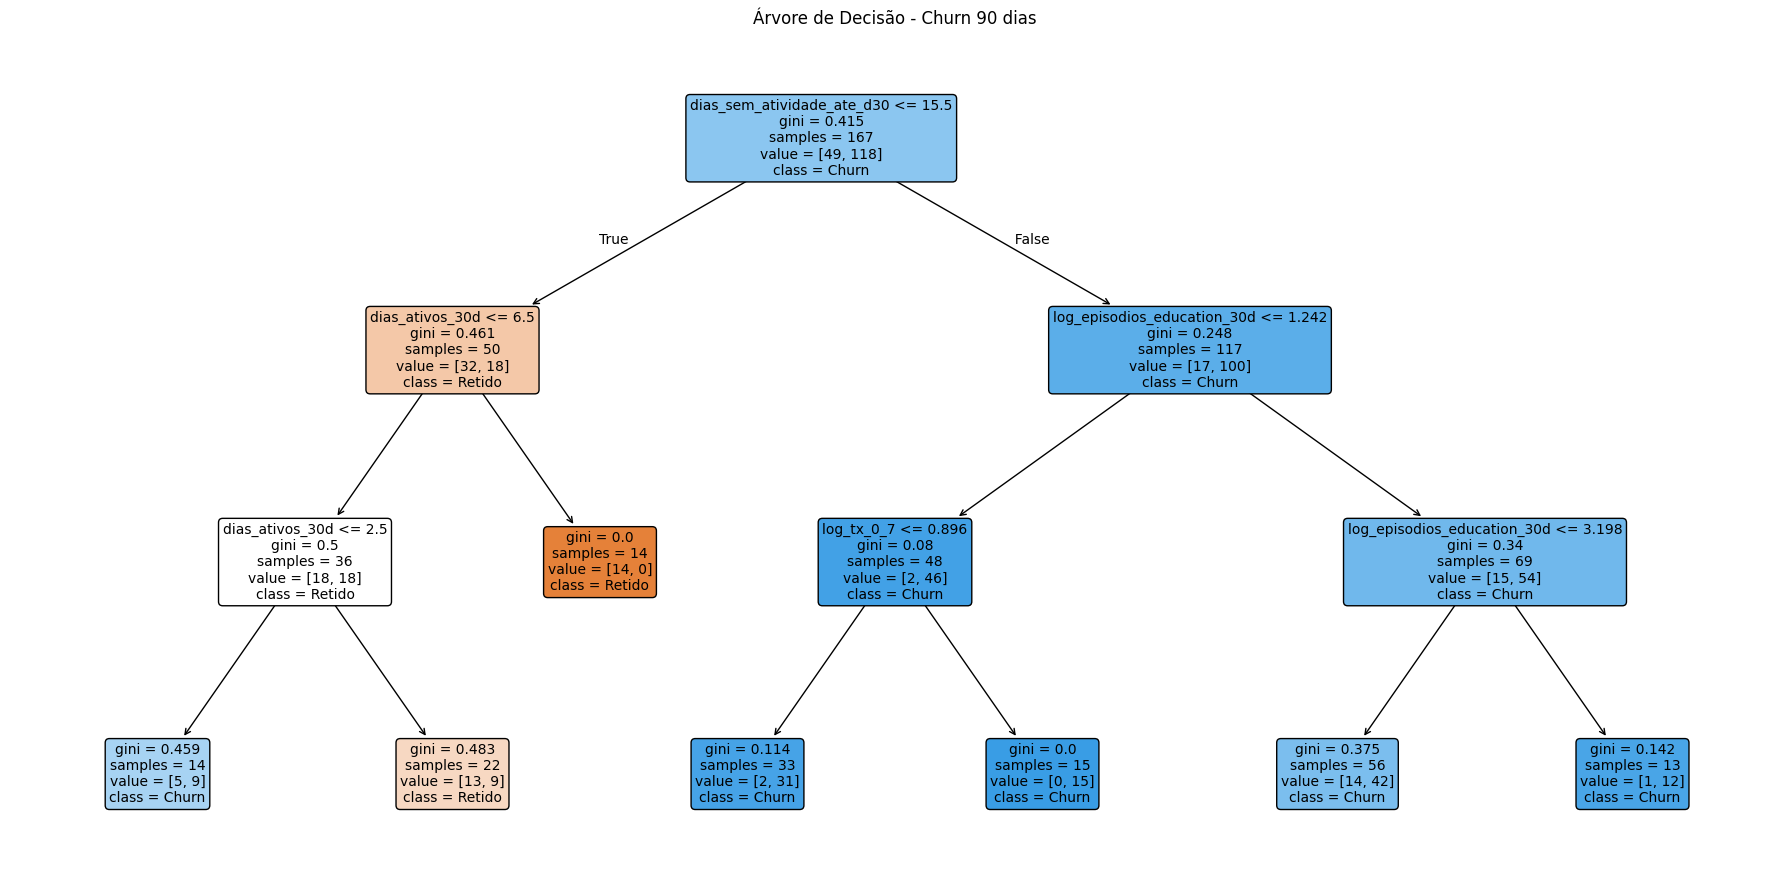

In [0]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

fig_tree, ax = plt.subplots(
    figsize=(18, 9)
)

plot_tree(
    modelo_arvore,
    feature_names=X_v2.columns,
    class_names=[
        "Retido",
        "Churn"
    ],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)

ax.set_title(
    "Árvore de Decisão - Churn 90 dias"
)

fig_tree.tight_layout()

mlflow.log_figure(
    fig_tree,
    "plots/decision_tree_v1.png"
)

plt.show()
plt.close(fig_tree)

In [0]:
import pandas as pd

importancias_arvore = pd.DataFrame({
    "feature":
        X_v2.columns,

    "importancia":
        modelo_arvore.feature_importances_
})

importancias_arvore = (
    importancias_arvore
    .sort_values(
        "importancia",
        ascending=False
    )
    .reset_index(drop=True)
)

In [0]:
importancias_arvore.to_csv(
    "/tmp/feature_importance_tree_v1.csv",
    index=False
)

mlflow.log_artifact(
    "/tmp/feature_importance_tree_v1.csv",
    artifact_path="interpretability"
)

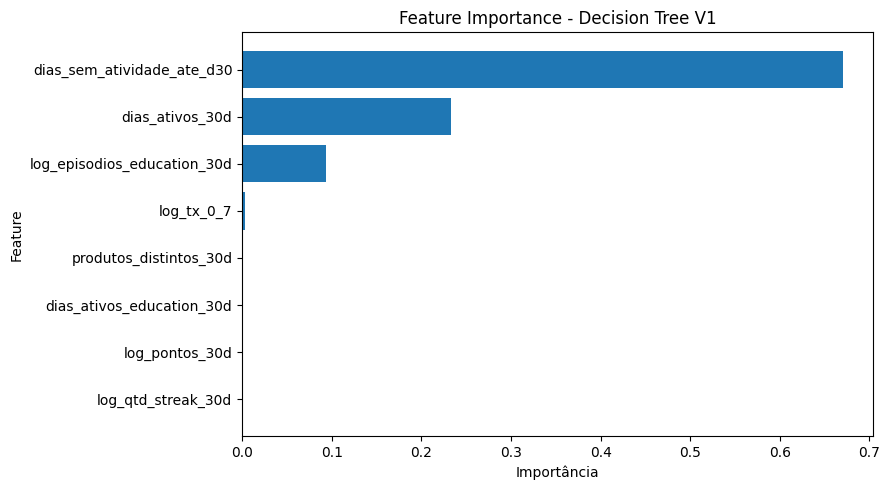

In [0]:
fig_imp, ax = plt.subplots(
    figsize=(9, 5)
)

ax.barh(
    importancias_arvore["feature"],
    importancias_arvore["importancia"]
)

ax.invert_yaxis()

ax.set_xlabel(
    "Importância"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Feature Importance - Decision Tree V1"
)

fig_imp.tight_layout()

mlflow.log_figure(
    fig_imp,
    "plots/feature_importance_tree_v1.png"
)

plt.show()
plt.close(fig_imp)

#### Os mesmos três gráficos da Logistic


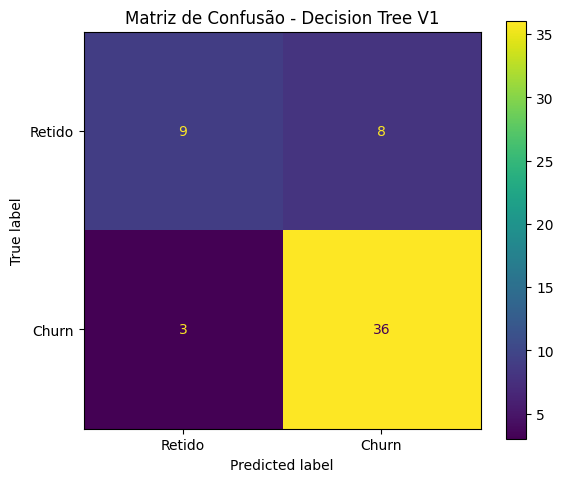

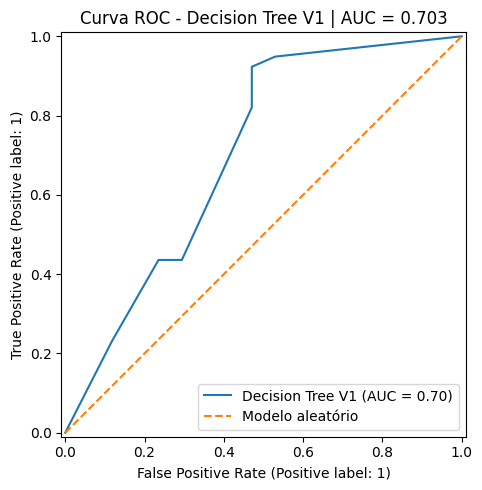

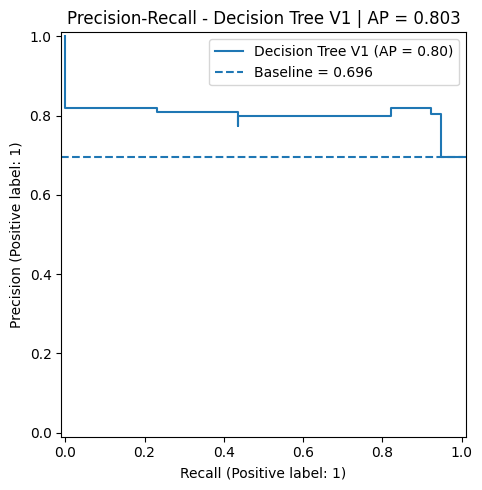

In [0]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# ============================================================
# Matriz de confusão
# ============================================================

cm_tree = confusion_matrix(
    y_test_v2,
    y_pred_arvore
)

tn, fp, fn, tp = cm_tree.ravel()

fig_cm, ax = plt.subplots(
    figsize=(6, 5)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[
        "Retido",
        "Churn"
    ]
).plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Matriz de Confusão - Decision Tree V1"
)

fig_cm.tight_layout()

mlflow.log_figure(
    fig_cm,
    "plots/confusion_matrix_tree_v1.png"
)

plt.show()
plt.close(fig_cm)


# ============================================================
# ROC
# ============================================================

fig_roc, ax = plt.subplots(
    figsize=(7, 5)
)

RocCurveDisplay.from_predictions(
    y_test_v2,
    y_proba_arvore,
    name="Decision Tree V1",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Modelo aleatório"
)

ax.set_title(
    f"Curva ROC - Decision Tree V1 | "
    f"AUC = {roc_auc_arvore:.3f}"
)

ax.legend()

fig_roc.tight_layout()

mlflow.log_figure(
    fig_roc,
    "plots/roc_curve_tree_v1.png"
)

plt.show()
plt.close(fig_roc)


# ============================================================
# Precision-Recall
# ============================================================

fig_pr, ax = plt.subplots(
    figsize=(7, 5)
)

PrecisionRecallDisplay.from_predictions(
    y_test_v2,
    y_proba_arvore,
    name="Decision Tree V1",
    ax=ax
)

baseline = y_test_v2.mean()

ax.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.3f}"
)

ax.set_title(
    "Precision-Recall - Decision Tree V1 "
    f"| AP = {average_precision_arvore:.3f}"
)

ax.legend()

fig_pr.tight_layout()

mlflow.log_figure(
    fig_pr,
    "plots/precision_recall_tree_v1.png"
)

plt.show()
plt.close(fig_pr)


mlflow.log_metrics({
    "true_positive_test": int(tp),
    "true_negative_test": int(tn),
    "false_positive_test": int(fp),
    "false_negative_test": int(fn)
})

#### Registrando o modelo no MLFlow


In [0]:
from mlflow.models import infer_signature

signature_tree = infer_signature(
    X_train_v2,
    modelo_arvore.predict(
        X_train_v2
    )
)

input_example_tree = (
    X_train_v2.head(5)
)

mlflow.sklearn.log_model(
    sk_model=modelo_arvore,
    artifact_path="model",
    signature=signature_tree,
    input_example=input_example_tree
)

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:30:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-40590380a4ca4f33883de

#### Encerrando a segunda Run


In [0]:
run_id_arvore = (
    mlflow.active_run()
    .info
    .run_id
)

mlflow.end_run()

print(
    "DecisionTree_V1 registrada com sucesso."
)

print(
    "Run ID:",
    run_id_arvore
)

DecisionTree_V1 registrada com sucesso.
Run ID: 24733d18263a48f780b081975d85fd86


#### Modelos adicionais

Para enriquecer a comparação, vamos treinar e registrar mais quatro modelos no mesmo experimento MLflow, seguindo exatamente o mesmo padrão dos modelos anteriores:

* **Random Forest** — ensemble de árvores que reduz a variância da Decision Tree individual
* **Gradient Boosting** — árvores sequenciais que corrigem erros do modelo anterior
* **SVM (RBF)** — excelente para datasets pequenos; usa a pipeline com StandardScaler
* **Naive Bayes** — baseline simples e rápido, adequado para poucos dados

Todos usam as mesmas features (`features_modelo_v2`), o mesmo split treino/teste e a mesma validação cruzada estratificada de 5 folds.

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from mlflow.models import infer_signature

if mlflow.active_run():
    mlflow.end_run()

run_rf = mlflow.start_run(run_name="RandomForest_V1")
run_id_rf = run_rf.info.run_id

mlflow.log_params({
    "algorithm": "RandomForestClassifier",
    "n_estimators": 200,
    "max_depth": 4,
    "min_samples_leaf": 10,
    "random_state": 42,
    "test_size": 0.25,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "Random Forest V1",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

modelo_rf.fit(
    X_train_v2,
    y_train_v2
)

y_pred_rf = modelo_rf.predict(
    X_test_v2
)

y_proba_rf = (
    modelo_rf
    .predict_proba(X_test_v2)[:, 1]
)

accuracy_rf = accuracy_score(
    y_test_v2,
    y_pred_rf
)

precision_rf = precision_score(
    y_test_v2,
    y_pred_rf
)

recall_rf = recall_score(
    y_test_v2,
    y_pred_rf
)

f1_rf = f1_score(
    y_test_v2,
    y_pred_rf
)

roc_auc_rf = roc_auc_score(
    y_test_v2,
    y_proba_rf
)

avg_precision_rf = average_precision_score(
    y_test_v2,
    y_proba_rf
)

print("RANDOM FOREST")
print("Accuracy:", round(accuracy_rf, 3))
print("Precision:", round(precision_rf, 3))
print("Recall:", round(recall_rf, 3))
print("F1:", round(f1_rf, 3))
print("ROC-AUC:", round(roc_auc_rf, 3))

mlflow.log_metrics({
    "accuracy_test": accuracy_rf,
    "precision_test": precision_rf,
    "recall_test": recall_rf,
    "f1_test": f1_rf,
    "roc_auc_test": roc_auc_rf,
    "average_precision_test": avg_precision_rf
})

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_rf = cross_val_score(
    modelo_rf,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

mlflow.log_metrics({
    "roc_auc_cv_mean": float(scores_rf.mean()),
    "roc_auc_cv_std": float(scores_rf.std())
})

for i, score in enumerate(
    scores_rf,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        score
    )

print(
    "\nROC-AUC CV médio:",
    round(scores_rf.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_rf.std(), 3)
)

signature_rf = infer_signature(
    X_train_v2,
    modelo_rf.predict(X_train_v2)
)

mlflow.sklearn.log_model(
    sk_model=modelo_rf,
    artifact_path="model",
    signature=signature_rf,
    input_example=X_train_v2.head(5)
)

mlflow.end_run()

print(
    "\nRandomForest_V1 registrada. Run ID:",
    run_id_rf
)

RANDOM FOREST
Accuracy: 0.821
Precision: 0.822
Recall: 0.949
F1: 0.881
ROC-AUC: 0.801


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:30:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



ROC-AUC CV médio: 0.778
Desvio padrão: 0.049


🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-253ea591d4e148d386d55905e9249615?o=7474654859451417



RandomForest_V1 registrada. Run ID: 31a357727034446c954e6c1375e1699c


In [0]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from mlflow.models import infer_signature

if mlflow.active_run():
    mlflow.end_run()

run_gb = mlflow.start_run(run_name="GradientBoosting_V1")
run_id_gb = run_gb.info.run_id

mlflow.log_params({
    "algorithm": "GradientBoostingClassifier",
    "n_estimators": 100,
    "max_depth": 3,
    "learning_rate": 0.1,
    "min_samples_leaf": 10,
    "random_state": 42,
    "test_size": 0.25,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "Gradient Boosting V1",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

modelo_gb = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_samples_leaf=10,
    random_state=42
)

modelo_gb.fit(
    X_train_v2,
    y_train_v2
)

y_pred_gb = modelo_gb.predict(
    X_test_v2
)

y_proba_gb = (
    modelo_gb
    .predict_proba(X_test_v2)[:, 1]
)

accuracy_gb = accuracy_score(
    y_test_v2,
    y_pred_gb
)

precision_gb = precision_score(
    y_test_v2,
    y_pred_gb
)

recall_gb = recall_score(
    y_test_v2,
    y_pred_gb
)

f1_gb = f1_score(
    y_test_v2,
    y_pred_gb
)

roc_auc_gb = roc_auc_score(
    y_test_v2,
    y_proba_gb
)

avg_precision_gb = average_precision_score(
    y_test_v2,
    y_proba_gb
)

print("GRADIENT BOOSTING")
print("Accuracy:", round(accuracy_gb, 3))
print("Precision:", round(precision_gb, 3))
print("Recall:", round(recall_gb, 3))
print("F1:", round(f1_gb, 3))
print("ROC-AUC:", round(roc_auc_gb, 3))

mlflow.log_metrics({
    "accuracy_test": accuracy_gb,
    "precision_test": precision_gb,
    "recall_test": recall_gb,
    "f1_test": f1_gb,
    "roc_auc_test": roc_auc_gb,
    "average_precision_test": avg_precision_gb
})

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_gb = cross_val_score(
    modelo_gb,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

mlflow.log_metrics({
    "roc_auc_cv_mean": float(scores_gb.mean()),
    "roc_auc_cv_std": float(scores_gb.std())
})

for i, score in enumerate(
    scores_gb,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        score
    )

print(
    "\nROC-AUC CV médio:",
    round(scores_gb.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_gb.std(), 3)
)

signature_gb = infer_signature(
    X_train_v2,
    modelo_gb.predict(X_train_v2)
)

mlflow.sklearn.log_model(
    sk_model=modelo_gb,
    artifact_path="model",
    signature=signature_gb,
    input_example=X_train_v2.head(5)
)

mlflow.end_run()

print(
    "\nGradientBoosting_V1 registrada. Run ID:",
    run_id_gb
)

GRADIENT BOOSTING
Accuracy: 0.786
Precision: 0.814
Recall: 0.897
F1: 0.854
ROC-AUC: 0.729


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



ROC-AUC CV médio: 0.723
Desvio padrão: 0.035


🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-253d928345de4c7abf456f909b803f70?o=7474654859451417



GradientBoosting_V1 registrada. Run ID: 90869e8310d643d9b9f0f3730bb4792e


In [0]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from mlflow.models import infer_signature

if mlflow.active_run():
    mlflow.end_run()

run_svm = mlflow.start_run(run_name="SVM_RBF_V1")
run_id_svm = run_svm.info.run_id

mlflow.log_params({
    "algorithm": "SVC",
    "kernel": "rbf",
    "C": 1.0,
    "gamma": "scale",
    "random_state": 42,
    "test_size": 0.25,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "SVM RBF V1",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

modelo_svm = Pipeline([
    ("scaler", StandardScaler()),
    (
        "modelo",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=42
        )
    )
])

modelo_svm.fit(
    X_train_v2,
    y_train_v2
)

y_pred_svm = modelo_svm.predict(
    X_test_v2
)

y_proba_svm = (
    modelo_svm
    .predict_proba(X_test_v2)[:, 1]
)

accuracy_svm = accuracy_score(
    y_test_v2,
    y_pred_svm
)

precision_svm = precision_score(
    y_test_v2,
    y_pred_svm
)

recall_svm = recall_score(
    y_test_v2,
    y_pred_svm
)

f1_svm = f1_score(
    y_test_v2,
    y_pred_svm
)

roc_auc_svm = roc_auc_score(
    y_test_v2,
    y_proba_svm
)

avg_precision_svm = average_precision_score(
    y_test_v2,
    y_proba_svm
)

print("SVM RBF")
print("Accuracy:", round(accuracy_svm, 3))
print("Precision:", round(precision_svm, 3))
print("Recall:", round(recall_svm, 3))
print("F1:", round(f1_svm, 3))
print("ROC-AUC:", round(roc_auc_svm, 3))

mlflow.log_metrics({
    "accuracy_test": accuracy_svm,
    "precision_test": precision_svm,
    "recall_test": recall_svm,
    "f1_test": f1_svm,
    "roc_auc_test": roc_auc_svm,
    "average_precision_test": avg_precision_svm
})

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_svm = cross_val_score(
    modelo_svm,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

mlflow.log_metrics({
    "roc_auc_cv_mean": float(scores_svm.mean()),
    "roc_auc_cv_std": float(scores_svm.std())
})

for i, score in enumerate(
    scores_svm,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        score
    )

print(
    "\nROC-AUC CV médio:",
    round(scores_svm.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_svm.std(), 3)
)

signature_svm = infer_signature(
    X_train_v2,
    modelo_svm.predict(X_train_v2)
)

mlflow.sklearn.log_model(
    sk_model=modelo_svm,
    artifact_path="model",
    signature=signature_svm,
    input_example=X_train_v2.head(5)
)

mlflow.end_run()

print(
    "\nSVM_RBF_V1 registrada. Run ID:",
    run_id_svm
)

SVM RBF
Accuracy: 0.821
Precision: 0.809
Recall: 0.974
F1: 0.884
ROC-AUC: 0.701

ROC-AUC CV médio: 0.715
Desvio padrão: 0.092


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:31:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-5eb07ea7559a47358ae98


SVM_RBF_V1 registrada. Run ID: 286287e4531049389476b182a0ad9216


In [0]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from mlflow.models import infer_signature

if mlflow.active_run():
    mlflow.end_run()

run_nb = mlflow.start_run(run_name="NaiveBayes_V1")
run_id_nb = run_nb.info.run_id

mlflow.log_params({
    "algorithm": "GaussianNB",
    "test_size": 0.25,
    "random_state": 42,
    "n_features": len(features_modelo_v2),
    "n_registros": len(X_v2)
})

mlflow.log_param(
    "features",
    ", ".join(features_modelo_v2)
)

mlflow.set_tags({
    "projeto": "TMW",
    "case": "Churn Loyalty",
    "modelo": "Naive Bayes V1",
    "target": "churn_90d",
    "observation_window": "D0-D30",
    "target_window": "D31-D90"
})

modelo_nb = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", GaussianNB())
])

modelo_nb.fit(
    X_train_v2,
    y_train_v2
)

y_pred_nb = modelo_nb.predict(
    X_test_v2
)

y_proba_nb = (
    modelo_nb
    .predict_proba(X_test_v2)[:, 1]
)

accuracy_nb = accuracy_score(
    y_test_v2,
    y_pred_nb
)

precision_nb = precision_score(
    y_test_v2,
    y_pred_nb
)

recall_nb = recall_score(
    y_test_v2,
    y_pred_nb
)

f1_nb = f1_score(
    y_test_v2,
    y_pred_nb
)

roc_auc_nb = roc_auc_score(
    y_test_v2,
    y_proba_nb
)

avg_precision_nb = average_precision_score(
    y_test_v2,
    y_proba_nb
)

print("NAIVE BAYES")
print("Accuracy:", round(accuracy_nb, 3))
print("Precision:", round(precision_nb, 3))
print("Recall:", round(recall_nb, 3))
print("F1:", round(f1_nb, 3))
print("ROC-AUC:", round(roc_auc_nb, 3))

mlflow.log_metrics({
    "accuracy_test": accuracy_nb,
    "precision_test": precision_nb,
    "recall_test": recall_nb,
    "f1_test": f1_nb,
    "roc_auc_test": roc_auc_nb,
    "average_precision_test": avg_precision_nb
})

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_nb = cross_val_score(
    modelo_nb,
    X_v2,
    y,
    cv=cv,
    scoring="roc_auc"
)

mlflow.log_metrics({
    "roc_auc_cv_mean": float(scores_nb.mean()),
    "roc_auc_cv_std": float(scores_nb.std())
})

for i, score in enumerate(
    scores_nb,
    start=1
):
    mlflow.log_metric(
        f"roc_auc_fold_{i}",
        score
    )

print(
    "\nROC-AUC CV médio:",
    round(scores_nb.mean(), 3)
)

print(
    "Desvio padrão:",
    round(scores_nb.std(), 3)
)

signature_nb = infer_signature(
    X_train_v2,
    modelo_nb.predict(X_train_v2)
)

mlflow.sklearn.log_model(
    sk_model=modelo_nb,
    artifact_path="model",
    signature=signature_nb,
    input_example=X_train_v2.head(5)
)

mlflow.end_run()

print(
    "\nNaiveBayes_V1 registrada. Run ID:",
    run_id_nb
)

NAIVE BAYES
Accuracy: 0.804
Precision: 0.804
Recall: 0.949
F1: 0.871
ROC-AUC: 0.744


/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/10/06 21:31:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



ROC-AUC CV médio: 0.775
Desvio padrão: 0.027


🔗 View Logged Model at: https://dbc-62ed25ef-dd83.cloud.databricks.com/ml/experiments/1628557705952187/models/m-6aa48103db394dc6b594daa4f5a4ef95?o=7474654859451417



NaiveBayes_V1 registrada. Run ID: 9fb1e3fcf1eb4182aa6ebd4ba8864235


#### Comparação dos modelos


In [0]:
comparacao_modelos = pd.DataFrame({
    "modelo": [
        "Regressão Logística V2",
        "Árvore de Decisão",
        "Random Forest",
        "Gradient Boosting",
        "SVM RBF",
        "Naive Bayes"
    ],
    "roc_auc_cv_medio": [
        scores_auc.mean(),
        scores_arvore_auc.mean(),
        scores_rf.mean(),
        scores_gb.mean(),
        scores_svm.mean(),
        scores_nb.mean()
    ],
    "desvio_padrao": [
        scores_auc.std(),
        scores_arvore_auc.std(),
        scores_rf.std(),
        scores_gb.std(),
        scores_svm.std(),
        scores_nb.std()
    ]
})

comparacao_modelos = (
    comparacao_modelos
    .sort_values(
        "roc_auc_cv_medio",
        ascending=False
    )
)

comparacao_modelos.round(3)

,modelo,roc_auc_cv_medio,desvio_padrao
0,Regressão Logística V2,0.794,0.058
2,Random Forest,0.778,0.049
5,Naive Bayes,0.775,0.027
3,Gradient Boosting,0.723,0.035
1,Árvore de Decisão,0.722,0.067
4,SVM RBF,0.715,0.092


In [0]:
comparacao_completa = pd.DataFrame({
    "modelo": [
        "Regressão Logística V2",
        "Random Forest",
        "Naive Bayes",
        "Gradient Boosting",
        "Árvore de Decisão",
        "SVM RBF"
    ],
    "roc_auc_test": [
        roc_auc_v2,
        roc_auc_rf,
        roc_auc_nb,
        roc_auc_gb,
        roc_auc_arvore,
        roc_auc_svm
    ],
    "roc_auc_cv": [
        scores_auc.mean(),
        scores_rf.mean(),
        scores_nb.mean(),
        scores_gb.mean(),
        scores_arvore_auc.mean(),
        scores_svm.mean()
    ],
    "roc_auc_cv_std": [
        scores_auc.std(),
        scores_rf.std(),
        scores_nb.std(),
        scores_gb.std(),
        scores_arvore_auc.std(),
        scores_svm.std()
    ],
    "accuracy": [
        accuracy_v2,
        accuracy_rf,
        accuracy_nb,
        accuracy_gb,
        accuracy_arvore,
        accuracy_svm
    ],
    "precision": [
        precision_v2,
        precision_rf,
        precision_nb,
        precision_gb,
        precision_arvore,
        precision_svm
    ],
    "recall": [
        recall_v2,
        recall_rf,
        recall_nb,
        recall_gb,
        recall_arvore,
        recall_svm
    ],
    "f1": [
        f1_v2,
        f1_rf,
        f1_nb,
        f1_gb,
        f1_arvore,
        f1_svm
    ]
})

comparacao_completa = (
    comparacao_completa
    .sort_values(
        "roc_auc_cv",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    comparacao_completa.round(3)
)

modelo,roc_auc_test,roc_auc_cv,roc_auc_cv_std,accuracy,precision,recall,f1
Regressão Logística V2,0.798,0.794,0.058,0.804,0.818,0.923,0.867
Random Forest,0.801,0.778,0.049,0.821,0.822,0.949,0.881
Naive Bayes,0.744,0.775,0.027,0.804,0.804,0.949,0.871
Gradient Boosting,0.729,0.723,0.035,0.786,0.814,0.897,0.854
Árvore de Decisão,0.703,0.722,0.067,0.804,0.818,0.923,0.867
SVM RBF,0.701,0.715,0.092,0.821,0.809,0.974,0.884


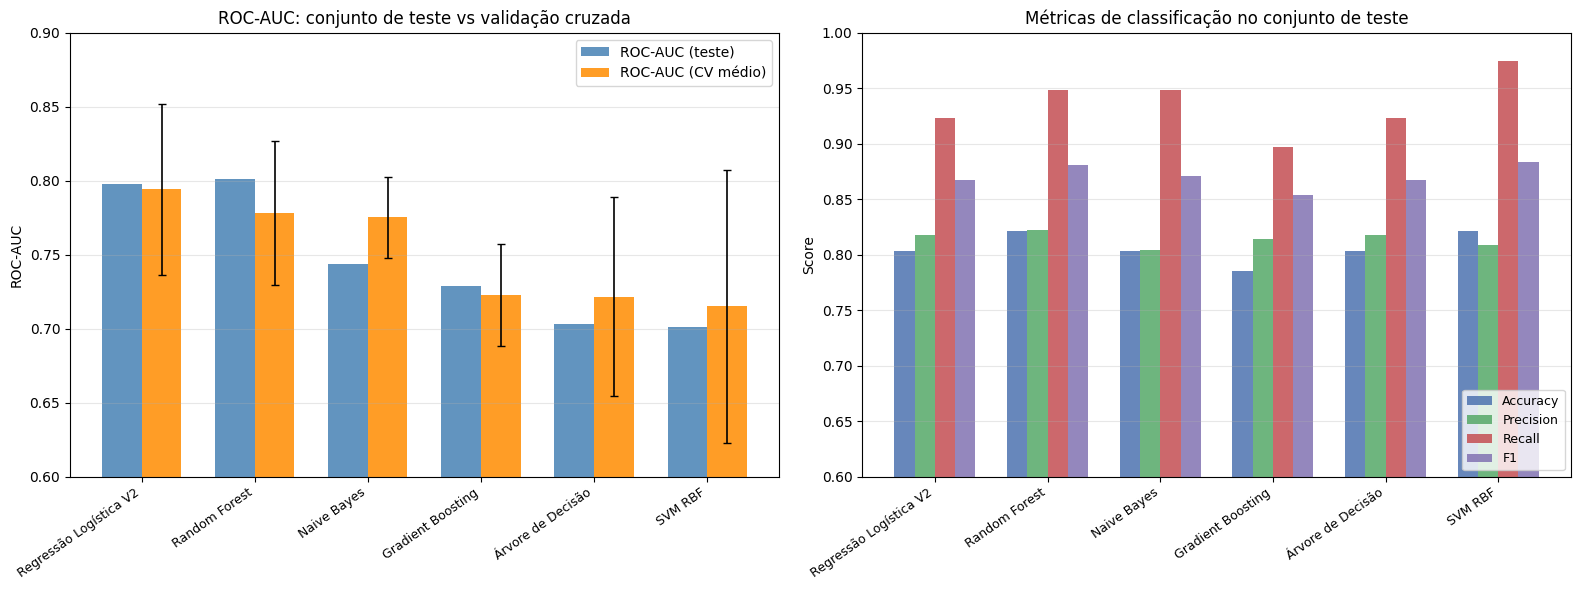

In [0]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

modelos = comparacao_completa["modelo"]
x = np.arange(
    len(modelos)
)

# --- Gráfico 1: ROC-AUC (test vs CV) ---
ax1 = axes[0]
width = 0.35

bars_test = ax1.bar(
    x - width / 2,
    comparacao_completa["roc_auc_test"],
    width,
    label="ROC-AUC (teste)",
    color="steelblue",
    alpha=0.85
)

bars_cv = ax1.bar(
    x + width / 2,
    comparacao_completa["roc_auc_cv"],
    width,
    label="ROC-AUC (CV médio)",
    color="darkorange",
    alpha=0.85
)

ax1.errorbar(
    x + width / 2,
    comparacao_completa["roc_auc_cv"],
    yerr=comparacao_completa["roc_auc_cv_std"],
    fmt="none",
    ecolor="black",
    capsize=3,
    linewidth=1.2
)

ax1.set_xticks(x)
ax1.set_xticklabels(
    modelos,
    rotation=35,
    ha="right",
    fontsize=9
)
ax1.set_ylabel("ROC-AUC")
ax1.set_title(
    "ROC-AUC: conjunto de teste vs validação cruzada",
    fontsize=12
)
ax1.legend()
ax1.set_ylim(0.6, 0.9)
ax1.axhline(
    y=0.5,
    color="gray",
    linestyle="--",
    alpha=0.5
)
ax1.grid(axis="y", alpha=0.3)

# --- Gráfico 2: Métricas de classificação ---
ax2 = axes[1]
metricas = ["accuracy", "precision", "recall", "f1"]
cores = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for i, metrica in enumerate(metricas):
    ax2.bar(
        x + i * 0.18 - 0.27,
        comparacao_completa[metrica],
        0.18,
        label=metrica.capitalize(),
        color=cores[i],
        alpha=0.85
    )

ax2.set_xticks(x)
ax2.set_xticklabels(
    modelos,
    rotation=35,
    ha="right",
    fontsize=9
)
ax2.set_ylabel("Score")
ax2.set_title(
    "Métricas de classificação no conjunto de teste",
    fontsize=12
)
ax2.legend(loc="lower right", fontsize=9)
ax2.set_ylim(0.6, 1.0)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

#### Análise comparativa dos 6 modelos

| Modelo | ROC-AUC (teste) | ROC-AUC (CV) | CV std | Accuracy | Precision | Recall | F1 |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **Regressão Logística V2** | 0.798 | **0.794** | 0.058 | 0.804 | 0.818 | 0.923 | 0.867 |
| **Random Forest** | **0.801** | 0.778 | 0.049 | 0.821 | 0.822 | 0.949 | 0.881 |
| Naive Bayes | 0.744 | 0.775 | **0.027** | 0.804 | 0.804 | 0.949 | 0.871 |
| Gradient Boosting | 0.729 | 0.723 | 0.035 | 0.786 | 0.814 | 0.897 | 0.854 |
| Árvore de Decisão | 0.703 | 0.722 | 0.067 | 0.804 | 0.818 | 0.923 | 0.867 |
| SVM RBF | 0.701 | 0.715 | 0.092 | 0.821 | 0.809 | **0.974** | 0.884 |

**Principais conclusões:**

* A **Regressão Logística V2** segue como o melhor modelo em ROC-AUC CV (0.794), com a vantagem de oferecer interpretabilidade via odds ratios e calibração satisfatória (Brier = 0.149). É o modelo mais equilibrado.

* O **Random Forest** foi o melhor no conjunto de teste (0.801) e o segundo em CV (0.778). Destaca-se pelo maior recall (0.949) e F1 (0.881), mas sem superar a regressão logística na validação cruzada — o que sugere que parte da vantagem no teste pode ser sorteio do split.

* O **Naive Bayes** surpreende como o modelo mais estável, com o menor desvio padrão (0.027) e ROC-AUC CV de 0.775. Sendo um modelo simples, esse resultado é notável e confirma que com 223 registros, modelos complexos não ganham muito.

* O **Gradient Boosting**, a **Árvore de Decisão** e o **SVM RBF** ficaram agrupados entre 0.715 e 0.723 em CV. O SVM teve o recall mais alto (0.974) mas com baixa precisão e alta variância (0.092), indicando que classifica quase tudo como churn.

* **Modelo escolhido:** Regressão Logística V2 — melhor performance generalizada, interpretabilidade, calibração e estabilidade.

#### Consolidação dos modelos:

Regressão Logística V2 → modelo oficial de previsão
ROC-AUC CV ≈ 0,794, recall alto e boa interpretabilidade por odds ratios.

Árvore de Decisão → modelo de comunicação
ROC-AUC CV ≈ 0,722, mas excelente para transformar o modelo em regras como:

Mais de ~15 dias sem atividade até D30
→ risco muito alto

Mantém atividade até a segunda metade do mês
+
7 ou mais dias distintos ativos
→ perfil de retenção muito mais forte

Há também um ponto metodológico positivo: a árvore não tentou usar todas as variáveis disponíveis. Isso mostra que, para explicar churn de maneira simples, persistência + regularidade + algum sinal de Education já capturam boa parte da estrutura.

Neste ponto, eu considero encerrada a comparação Regressão Logística × Árvore de Decisão. O passo seguinte mais valioso seria sair da pergunta “qual modelo ganhou?” e trabalhar a parte operacional: definir faixas de risco a partir da probabilidade da regressão — baixo, médio e alto risco — e avaliar qual threshold oferece o melhor equilíbrio entre recall, precision e custo de intervenção. Isso transformaria o modelo em uma ferramenta utilizável de prevenção de churn.


## J - Probabilidades Out-of-Fold e definição de threshold

As probabilidades OOF são geradas utilizando os mesmos cinco folds empregados na validação cruzada.


In [0]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

import numpy as np
import pandas as pd

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

proba_oof = cross_val_predict(
    modelo_logistico_v2,
    X_v2,
    y,
    cv=cv,
    method="predict_proba"
)[:, 1]

avaliacao = pd.DataFrame({
    "churn_real": np.asarray(y),
    "prob_churn": proba_oof
})

avaliacao.head()

,churn_real,prob_churn
0,1,0.632908
1,1,0.711318
2,1,0.872788
3,0,0.015636
4,0,0.832919


In [0]:
avaliacao["prob_churn"].describe()

count    223.000000
mean       0.703392
std        0.249928
min        0.009219
25%        0.596940
50%        0.800556
75%        0.885521
max        0.989732
Name: prob_churn, dtype: float64

#### Antes das faixas: verificar calibração

Quanto mais próxima a curva estiver da diagonal, melhor.

O Brier varia de 0 a 1; quanto menor, melhor.


Brier Score: 0.149


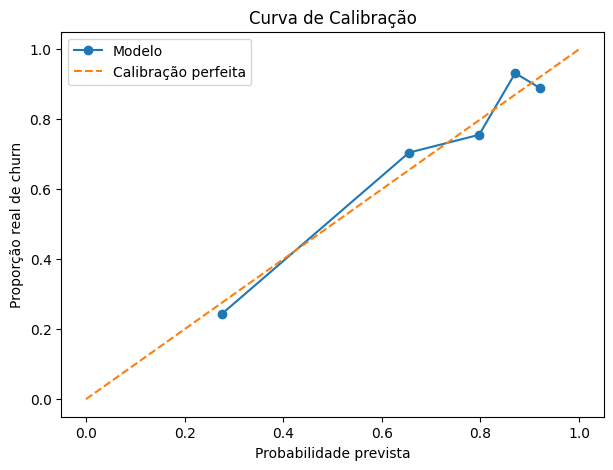

In [0]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

prob_real, prob_prevista = calibration_curve(
    avaliacao["churn_real"],
    avaliacao["prob_churn"],
    n_bins=5,
    strategy="quantile"
)

brier = brier_score_loss(
    avaliacao["churn_real"],
    avaliacao["prob_churn"]
)

print(
    "Brier Score:",
    round(brier, 3)
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_prevista,
    prob_real,
    marker="o",
    label="Modelo"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibração perfeita"
)

plt.xlabel("Probabilidade prevista")
plt.ylabel("Proporção real de churn")
plt.title("Curva de Calibração")

plt.legend()
plt.show()

#### Testar diferentes thresholds

Agora vamos testar vários cortes entre 0,10 e 0,90.


In [0]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

resultados_threshold = []

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

for threshold in thresholds:

    pred = (
        avaliacao["prob_churn"] >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        avaliacao["churn_real"],
        pred,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        avaliacao["churn_real"],
        pred,
        zero_division=0
    )

    recall = recall_score(
        avaliacao["churn_real"],
        pred,
        zero_division=0
    )

    f1 = f1_score(
        avaliacao["churn_real"],
        pred,
        zero_division=0
    )

    especificidade = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    npv = (
        tn / (tn + fn)
        if (tn + fn) > 0
        else 0
    )

    taxa_alerta = pred.mean()

    resultados_threshold.append({
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "precision": precision,
        "recall": recall,
        "specificity": especificidade,
        "NPV": npv,
        "F1": f1,
        "pct_clientes_alertados": taxa_alerta
    })

tabela_threshold = pd.DataFrame(
    resultados_threshold
)

tabela_threshold.round(3)

,threshold,TP,FP,TN,FN,precision,recall,specificity,NPV,F1,pct_clientes_alertados
0,0.10,157,53,13,0,0.748,1.000,0.197,1.000,0.856,0.942
1,0.15,156,51,15,1,0.754,0.994,0.227,0.938,0.857,0.928
2,0.20,156,48,18,1,0.765,0.994,0.273,0.947,0.864,0.915
3,0.25,156,46,20,1,0.772,0.994,0.303,0.952,0.869,0.906
4,0.30,155,45,21,2,0.775,0.987,0.318,0.913,0.868,0.897
5,0.35,154,43,23,3,0.782,0.981,0.348,0.885,0.870,0.883
6,0.40,152,42,24,5,0.784,0.968,0.364,0.828,0.866,0.870
7,0.45,151,39,27,6,0.795,0.962,0.409,0.818,0.870,0.852
8,0.50,148,36,30,9,0.804,0.943,0.455,0.769,0.868,0.825
9,0.55,143,32,34,14,0.817,0.911,0.515,0.708,0.861,0.785


#### Visualizar Precision × Recall × F1


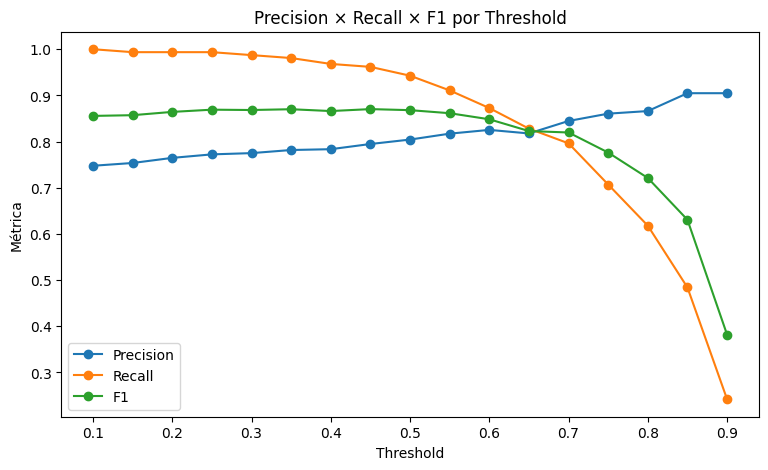

In [0]:
plt.figure(figsize=(9, 5))

plt.plot(
    tabela_threshold["threshold"],
    tabela_threshold["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    tabela_threshold["threshold"],
    tabela_threshold["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    tabela_threshold["threshold"],
    tabela_threshold["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")

plt.title(
    "Precision × Recall × F1 por Threshold"
)

plt.legend()

plt.show()

#### Melhor threshold pelo F1

Como primeira referência estatística:


In [0]:
melhor_f1 = (
    tabela_threshold
    .sort_values(
        "F1",
        ascending=False
    )
    .iloc[0]
)

melhor_f1

threshold                   0.450000
TP                        151.000000
FP                         39.000000
TN                         27.000000
FN                          6.000000
precision                   0.794737
recall                      0.961783
specificity                 0.409091
NPV                         0.818182
F1                          0.870317
pct_clientes_alertados      0.852018
Name: 7, dtype: float64

In [0]:
print(
    "Threshold melhor F1:",
    round(melhor_f1["threshold"], 2)
)

print(
    "Precision:",
    round(melhor_f1["precision"], 3)
)

print(
    "Recall:",
    round(melhor_f1["recall"], 3)
)

print(
    "F1:",
    round(melhor_f1["F1"], 3)
)

Threshold melhor F1: 0.45
Precision: 0.795
Recall: 0.962
F1: 0.87


#### Incorporar custo da intervenção

Imagine inicialmente esta relação apenas como exemplo:

Custo de abordar alguém = 1

Custo de deixar um churn escapar = 5



In [0]:
CUSTO_INTERVENCAO = 1
CUSTO_CHURN_NAO_TRATADO = 5

tabela_threshold[
    "custo_operacional"
] = (

    (
        tabela_threshold["TP"]
        +
        tabela_threshold["FP"]
    )
    * CUSTO_INTERVENCAO

    +

    tabela_threshold["FN"]
    * CUSTO_CHURN_NAO_TRATADO
)

tabela_threshold[
    [
        "threshold",
        "precision",
        "recall",
        "F1",
        "pct_clientes_alertados",
        "FN",
        "FP",
        "custo_operacional"
    ]
].round(3)

,threshold,precision,recall,F1,pct_clientes_alertados,FN,FP,custo_operacional
0,0.10,0.748,1.000,0.856,0.942,0,53,210
1,0.15,0.754,0.994,0.857,0.928,1,51,212
2,0.20,0.765,0.994,0.864,0.915,1,48,209
3,0.25,0.772,0.994,0.869,0.906,1,46,207
4,0.30,0.775,0.987,0.868,0.897,2,45,210
5,0.35,0.782,0.981,0.870,0.883,3,43,212
6,0.40,0.784,0.968,0.866,0.870,5,42,219
7,0.45,0.795,0.962,0.870,0.852,6,39,220
8,0.50,0.804,0.943,0.868,0.825,9,36,229
9,0.55,0.817,0.911,0.861,0.785,14,32,245


#### Encontrar o threshold de menor custo


In [0]:
melhor_custo = (
    tabela_threshold
    .sort_values(
        "custo_operacional"
    )
    .iloc[0]
)

melhor_custo

threshold                   0.250000
TP                        156.000000
FP                         46.000000
TN                         20.000000
FN                          1.000000
precision                   0.772277
recall                      0.993631
specificity                 0.303030
NPV                         0.952381
F1                          0.869081
pct_clientes_alertados      0.905830
custo_operacional         207.000000
Name: 3, dtype: float64

In [0]:
threshold_alto = float(
    melhor_custo["threshold"]
)

print(
    "Threshold operacional:",
    round(threshold_alto, 2)
)

print(
    "Precision:",
    round(melhor_custo["precision"], 3)
)

print(
    "Recall:",
    round(melhor_custo["recall"], 3)
)

print(
    "% usuários alertados:",
    round(
        melhor_custo[
            "pct_clientes_alertados"
        ] * 100,
        1
    )
)

Threshold operacional: 0.25
Precision: 0.772
Recall: 0.994
% usuários alertados: 90.6


#### Definir o limite de baixo risco

Para BAIXO RISCO, queremos o raciocínio contrário:

Qual é o maior threshold abaixo do qual o churn observado continua muito baixo?

Vamos inicialmente exigir:

churn observado <= 20%
mínimo 15 usuários


In [0]:
candidatos_baixo = []

for threshold in np.arange(
    0.05,
    threshold_alto,
    0.025
):

    grupo = avaliacao[
        avaliacao["prob_churn"]
        < threshold
    ]

    if len(grupo) >= 15:

        taxa_churn = (
            grupo["churn_real"].mean()
        )

        candidatos_baixo.append({
            "threshold": threshold,
            "usuarios": len(grupo),
            "taxa_churn_real": taxa_churn
        })

candidatos_baixo = pd.DataFrame(
    candidatos_baixo
)

candidatos_baixo.round(3)

,threshold,usuarios,taxa_churn_real
0,0.125,15,0.067
1,0.150,16,0.062
2,0.175,17,0.059
3,0.200,19,0.053
4,0.225,19,0.053
5,0.250,21,0.048


In [0]:
validos_baixo = candidatos_baixo[
    candidatos_baixo[
        "taxa_churn_real"
    ] <= 0.20
]

validos_baixo

,threshold,usuarios,taxa_churn_real
0,0.125,15,0.066667
1,0.150,16,0.062500
2,0.175,17,0.058824
3,0.200,19,0.052632
4,0.225,19,0.052632
5,0.250,21,0.047619


In [0]:
threshold_baixo = (
    validos_baixo
    .sort_values(
        "threshold",
        ascending=False
    )
    .iloc[0]["threshold"]
)

print(
    "Threshold baixo risco:",
    round(threshold_baixo, 3)
)

Threshold baixo risco: 0.25


#### Criar as três faixas


In [0]:
avaliacao["faixa_risco"] = np.select(

    [
        avaliacao["prob_churn"]
            < threshold_baixo,

        avaliacao["prob_churn"]
            >= threshold_alto
    ],

    [
        "BAIXO",
        "ALTO"
    ],

    default="MEDIO"
)

In [0]:
resumo_risco = (
    avaliacao
    .groupby("faixa_risco")
    .agg(
        usuarios=(
            "churn_real",
            "size"
        ),

        churns_reais=(
            "churn_real",
            "sum"
        ),

        taxa_churn_real=(
            "churn_real",
            "mean"
        ),

        prob_media=(
            "prob_churn",
            "mean"
        ),

        prob_min=(
            "prob_churn",
            "min"
        ),

        prob_max=(
            "prob_churn",
            "max"
        )
    )
    .reset_index()
)

resumo_risco[
    "taxa_churn_real"
] *= 100

resumo_risco.round(2)

,faixa_risco,usuarios,churns_reais,taxa_churn_real,prob_media,prob_min,prob_max
0,ALTO,202,156,77.23,0.77,0.25,0.99
1,BAIXO,21,1,4.76,0.09,0.01,0.23


Run encontrada: 7cb80cf48c4c4986ab57b0b3fd03748d


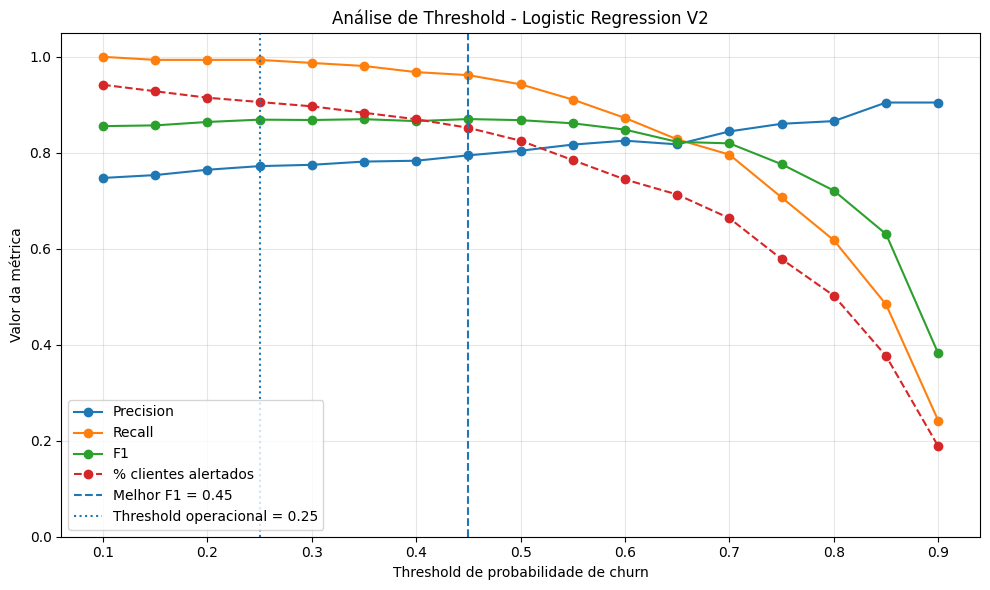

In [0]:
import mlflow
import matplotlib.pyplot as plt

# ============================================================
# Localiza a Run existente da LogisticRegression_V2
# ============================================================

experiment = mlflow.get_experiment_by_name(
    "/Shared/TMW_Churn_Loyalty"
)

runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'LogisticRegression_V2'",
    order_by=["attributes.start_time DESC"],
    max_results=1
)

run_id_v2 = runs.iloc[0]["run_id"]

print("Run encontrada:", run_id_v2)


# ============================================================
# Valores importantes da análise de threshold
# ============================================================

threshold_f1 = float(
    melhor_f1["threshold"]
)

threshold_operacional = float(
    melhor_custo["threshold"]
)


# ============================================================
# Cria o gráfico
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    tabela_threshold["threshold"],
    tabela_threshold["precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    tabela_threshold["threshold"],
    tabela_threshold["recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    tabela_threshold["threshold"],
    tabela_threshold["F1"],
    marker="o",
    label="F1"
)

ax.plot(
    tabela_threshold["threshold"],
    tabela_threshold["pct_clientes_alertados"],
    marker="o",
    linestyle="--",
    label="% clientes alertados"
)

# Melhor threshold pelo F1
ax.axvline(
    threshold_f1,
    linestyle="--",
    label=f"Melhor F1 = {threshold_f1:.2f}"
)

# Threshold operacional/custo
ax.axvline(
    threshold_operacional,
    linestyle=":",
    label=f"Threshold operacional = {threshold_operacional:.2f}"
)

ax.set_xlabel(
    "Threshold de probabilidade de churn"
)

ax.set_ylabel(
    "Valor da métrica"
)

ax.set_title(
    "Análise de Threshold - Logistic Regression V2"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend(
    loc="best"
)

ax.grid(
    alpha=0.3
)

fig.tight_layout()

plt.show()

Vamos produzir uma tabela por decis de score. Ela nos mostrará se o risco realmente aumenta à medida que a probabilidade prevista cresce


In [0]:
avaliacao["decil_risco"] = pd.qcut(
    avaliacao["prob_churn"],
    q=10,
    duplicates="drop"
)

analise_decis = (
    avaliacao
    .groupby(
        "decil_risco",
        observed=True
    )
    .agg(
        usuarios=("churn_real", "size"),
        churns=("churn_real", "sum"),
        taxa_churn=("churn_real", "mean"),
        prob_media=("prob_churn", "mean"),
        prob_min=("prob_churn", "min"),
        prob_max=("prob_churn", "max")
    )
    .reset_index()
)

analise_decis["taxa_churn"] *= 100

analise_decis.round(3)

,decil_risco,usuarios,churns,taxa_churn,prob_media,prob_min,prob_max
0,"(0.008220000000000002, 0.299]",23,2,8.696,0.110,0.009,0.293
1,"(0.299, 0.534]",22,9,40.909,0.450,0.321,0.532
2,"(0.534, 0.672]",22,17,77.273,0.601,0.538,0.670
3,"(0.672, 0.742]",22,14,63.636,0.709,0.673,0.742
4,"(0.742, 0.801]",23,19,82.609,0.770,0.742,0.801
5,"(0.801, 0.847]",22,15,68.182,0.826,0.802,0.847
6,"(0.847, 0.867]",22,21,95.455,0.857,0.848,0.867
7,"(0.867, 0.896]",22,20,90.909,0.883,0.867,0.896
8,"(0.896, 0.913]",22,19,86.364,0.907,0.897,0.912
9,"(0.913, 0.99]",23,21,91.304,0.934,0.914,0.990


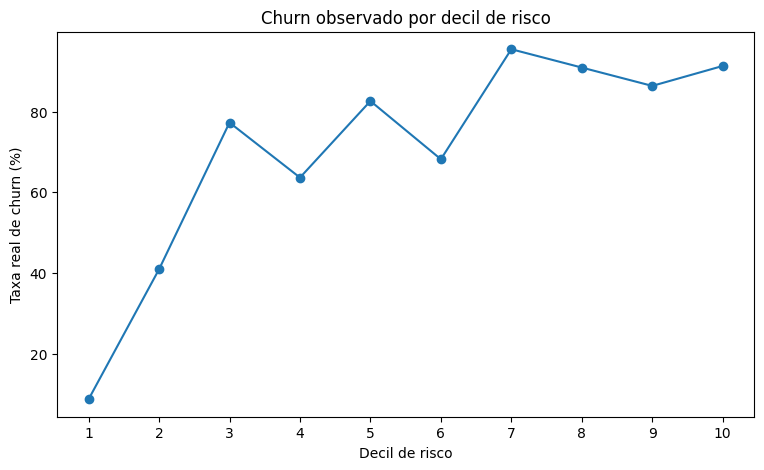

In [0]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(analise_decis) + 1),
    analise_decis["taxa_churn"],
    marker="o"
)

plt.xlabel("Decil de risco")
plt.ylabel("Taxa real de churn (%)")
plt.title("Churn observado por decil de risco")

plt.xticks(
    range(1, len(analise_decis) + 1)
)

plt.show()

Em seguida, custo de negócio

Podemos simular diferentes relações entre:

- custo de uma intervenção;
- prejuízo de deixar um churn escapar.




In [0]:
def avaliar_custo(
    tabela,
    custo_intervencao=1,
    custo_churn_perdido=5
):
    
    resultado = tabela.copy()

    resultado["custo"] = (
        (resultado["TP"] + resultado["FP"])
        * custo_intervencao
        +
        resultado["FN"]
        * custo_churn_perdido
    )

    return resultado.sort_values("custo")


custos = avaliar_custo(
    tabela_threshold,
    custo_intervencao=1,
    custo_churn_perdido=5
)

custos[
    [
        "threshold",
        "precision",
        "recall",
        "pct_clientes_alertados",
        "FP",
        "FN",
        "custo"
    ]
].round(3)

,threshold,precision,recall,pct_clientes_alertados,FP,FN,custo
3,0.25,0.772,0.994,0.906,46,1,207
2,0.20,0.765,0.994,0.915,48,1,209
0,0.10,0.748,1.000,0.942,53,0,210
4,0.30,0.775,0.987,0.897,45,2,210
1,0.15,0.754,0.994,0.928,51,1,212
5,0.35,0.782,0.981,0.883,43,3,212
6,0.40,0.784,0.968,0.870,42,5,219
7,0.45,0.795,0.962,0.852,39,6,220
8,0.50,0.804,0.943,0.825,36,9,229
9,0.55,0.817,0.911,0.785,32,14,245


#### Código para criar as faixas de churn


In [0]:
def classificar_risco(prob):

    if prob < 0.30:
        return "BAIXO"

    elif prob < 0.85:
        return "MEDIO"

    else:
        return "ALTO"


avaliacao["faixa_risco"] = (
    avaliacao["prob_churn"]
    .apply(classificar_risco)
)

In [0]:
resumo_faixas = (
    avaliacao
    .groupby("faixa_risco")
    .agg(
        usuarios=("churn_real", "size"),
        churns=("churn_real", "sum"),
        prob_media=("prob_churn", "mean"),
        prob_min=("prob_churn", "min"),
        prob_max=("prob_churn", "max"),
        taxa_churn=("churn_real", "mean")
    )
    .reset_index()
)

resumo_faixas["taxa_churn"] *= 100

resumo_faixas.round(3)

,faixa_risco,usuarios,churns,prob_media,prob_min,prob_max,taxa_churn
0,ALTO,84,76,0.899,0.853,0.990,90.476
1,BAIXO,23,2,0.110,0.009,0.293,8.696
2,MEDIO,116,79,0.680,0.321,0.849,68.103


Fazerndo um comparativo pela lógica da Matriz de Confusão:

- TP + FP → clientes que recebem intervenção;
- FN → churns que escapam;

Cada intervenção tem um custo e cada churn perdido tem um custo maior.



In [0]:
def simular_custos(
    tabela_threshold,
    custo_intervencao,
    custo_churn_perdido
):
    
    resultado = tabela_threshold.copy()

    resultado["custo_intervencoes"] = (
        (resultado["TP"] + resultado["FP"])
        * custo_intervencao
    )

    resultado["custo_churn_perdido"] = (
        resultado["FN"]
        * custo_churn_perdido
    )

    resultado["custo_total"] = (
        resultado["custo_intervencoes"]
        +
        resultado["custo_churn_perdido"]
    )

    resultado["clientes_intervencao"] = (
        resultado["TP"]
        +
        resultado["FP"]
    )

    return (
        resultado
        .sort_values("threshold")
        .reset_index(drop=True)
    )

#### Cenário A — intervenção barata

Por exemplo:
- intervenção = 1
- churn perdido = 10


Isso representa e-mail, push, conteúdo ou gamificação barata (Ação)


In [0]:
cenario_a = simular_custos(
    tabela_threshold,
    custo_intervencao=1,
    custo_churn_perdido=10
)

cenario_a[
    [
        "threshold",
        "clientes_intervencao",
        "FP",
        "FN",
        "precision",
        "recall",
        "custo_total"
    ]
].round(3)

,threshold,clientes_intervencao,FP,FN,precision,recall,custo_total
0,0.10,210,53,0,0.748,1.000,210
1,0.15,207,51,1,0.754,0.994,217
2,0.20,204,48,1,0.765,0.994,214
3,0.25,202,46,1,0.772,0.994,212
4,0.30,200,45,2,0.775,0.987,220
5,0.35,197,43,3,0.782,0.981,227
6,0.40,194,42,5,0.784,0.968,244
7,0.45,190,39,6,0.795,0.962,250
8,0.50,184,36,9,0.804,0.943,274
9,0.55,175,32,14,0.817,0.911,315


In [0]:
melhor_a = (
    cenario_a
    .sort_values("custo_total")
    .iloc[0]
)

melhor_a

threshold                   0.100000
TP                        157.000000
FP                         53.000000
TN                         13.000000
FN                          0.000000
precision                   0.747619
recall                      1.000000
specificity                 0.196970
NPV                         1.000000
F1                          0.855586
pct_clientes_alertados      0.941704
custo_operacional         210.000000
custo_intervencoes        210.000000
custo_churn_perdido         0.000000
custo_total               210.000000
clientes_intervencao      210.000000
Name: 0, dtype: float64

Nesse cenário, eu esperaria um threshold relativamente baixo, porque perder churn é muito caro.


#### Cenário B — custo intermediário

- intervenção = 1
- churn perdido = 5

Esse cenário provavelmente ficará próximo daquele nosso candidato de 0,55–0,60.


In [0]:
cenario_b = simular_custos(
    tabela_threshold,
    custo_intervencao=1,
    custo_churn_perdido=5
)

melhor_b = (
    cenario_b
    .sort_values("custo_total")
    .iloc[0]
)

melhor_b

threshold                   0.250000
TP                        156.000000
FP                         46.000000
TN                         20.000000
FN                          1.000000
precision                   0.772277
recall                      0.993631
specificity                 0.303030
NPV                         0.952381
F1                          0.869081
pct_clientes_alertados      0.905830
custo_operacional         207.000000
custo_intervencoes        202.000000
custo_churn_perdido         5.000000
custo_total               207.000000
clientes_intervencao      202.000000
Name: 3, dtype: float64

#### Cenário C — intervenção cara

Agora imagine um benefício financeiro, atendimento humano ou recompensa relevante:

- intervenção = 3

- churn perdido = 5

Aqui o threshold tende a subir, porque falso positivo ficou mais caro.


In [0]:
cenario_c = simular_custos(
    tabela_threshold,
    custo_intervencao=3,
    custo_churn_perdido=5
)

melhor_c = (
    cenario_c
    .sort_values("custo_total")
    .iloc[0]
)

melhor_c

threshold                   0.550000
TP                        143.000000
FP                         32.000000
TN                         34.000000
FN                         14.000000
precision                   0.817143
recall                      0.910828
specificity                 0.515152
NPV                         0.708333
F1                          0.861446
pct_clientes_alertados      0.784753
custo_operacional         245.000000
custo_intervencoes        525.000000
custo_churn_perdido        70.000000
custo_total               595.000000
clientes_intervencao      175.000000
Name: 9, dtype: float64

#### Comparar os três cenários

Essa provavelmente será uma das tabelas mais importantes do estudo.


In [0]:
comparacao_custos = pd.DataFrame([
    {
        "cenario": "A - intervenção barata",
        "custo_intervencao": 1,
        "custo_churn_perdido": 10,
        "threshold_otimo": melhor_a["threshold"],
        "precision": melhor_a["precision"],
        "recall": melhor_a["recall"],
        "clientes_alertados": melhor_a["pct_clientes_alertados"],
        "custo_total": melhor_a["custo_total"]
    },
    {
        "cenario": "B - intermediário",
        "custo_intervencao": 1,
        "custo_churn_perdido": 5,
        "threshold_otimo": melhor_b["threshold"],
        "precision": melhor_b["precision"],
        "recall": melhor_b["recall"],
        "clientes_alertados": melhor_b["pct_clientes_alertados"],
        "custo_total": melhor_b["custo_total"]
    },
    {
        "cenario": "C - intervenção cara",
        "custo_intervencao": 3,
        "custo_churn_perdido": 5,
        "threshold_otimo": melhor_c["threshold"],
        "precision": melhor_c["precision"],
        "recall": melhor_c["recall"],
        "clientes_alertados": melhor_c["pct_clientes_alertados"],
        "custo_total": melhor_c["custo_total"]
    }
])

comparacao_custos.round(3)

,cenario,custo_intervencao,custo_churn_perdido,threshold_otimo,precision,recall,clientes_alertados,custo_total
0,A - intervenção barata,1,10,0.10,0.748,1.000,0.942,210.0
1,B - intermediário,1,5,0.25,0.772,0.994,0.906,207.0
2,C - intervenção cara,3,5,0.55,0.817,0.911,0.785,595.0


#### Visualizar custo × threshold

A curva deve mostrar algo em formato próximo de U: 
- thresholds muito baixos custam caro porque abordamos quase todo mundo; 
- thresholds muito altos custam caro porque deixamos muitos churns escaparem.


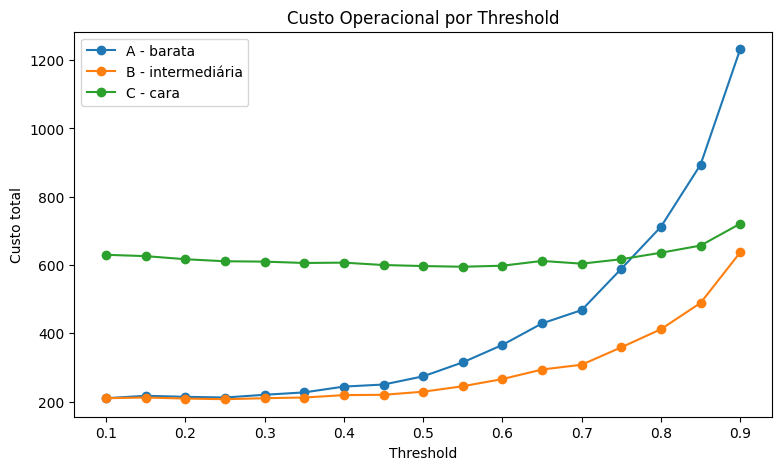

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    cenario_a["threshold"],
    cenario_a["custo_total"],
    marker="o",
    label="A - barata"
)

plt.plot(
    cenario_b["threshold"],
    cenario_b["custo_total"],
    marker="o",
    label="B - intermediária"
)

plt.plot(
    cenario_c["threshold"],
    cenario_c["custo_total"],
    marker="o",
    label="C - cara"
)

plt.xlabel("Threshold")
plt.ylabel("Custo total")
plt.title("Custo Operacional por Threshold")

plt.legend()
plt.show()

#### Podemos também calcular economia versus não usar modelo

Isso é muito interessante para negócio.

Imagine a estratégia:

abordar todos os 223 usuários.

O custo seria:


In [0]:
total_clientes = len(avaliacao)

custo_abordar_todos = (
    total_clientes * 1
)

print(
    "Custo de abordar todos:",
    custo_abordar_todos
)

Custo de abordar todos: 223


Ou estratégia nenhuma:

não abordar ninguém.


In [0]:
total_churn = avaliacao["churn_real"].sum()

custo_nao_fazer_nada = (
    total_churn * 5
)

print(
    "Custo de não fazer nada:",
    custo_nao_fazer_nada
)

Custo de não fazer nada: 785


E comparar com o modelo:

Mas aqui há uma sutileza: essa conta supõe que a intervenção evita completamente o churn, o que provavelmente não é verdade.


In [0]:
custo_modelo = melhor_b["custo_total"]

economia_vs_todos = (
    custo_abordar_todos
    -
    custo_modelo
)

economia_vs_nada = (
    custo_nao_fazer_nada
    -
    custo_modelo
)

print(
    "Economia vs abordar todos:",
    economia_vs_todos
)

print(
    "Economia vs não fazer nada:",
    economia_vs_nada
)

Economia vs abordar todos: 16.0
Economia vs não fazer nada: 578.0


#### Versão mais realista: taxa de sucesso da intervenção

Suponha que a ação de retenção consiga evitar apenas 30% dos churns tratados.



In [0]:
def simular_custos_com_eficacia(
    tabela_threshold,
    custo_intervencao,
    custo_churn,
    eficacia_intervencao
):
    
    resultado = tabela_threshold.copy()

    resultado["clientes_intervencao"] = (
        resultado["TP"] + resultado["FP"]
    )

    resultado["churns_evados"] = (
        resultado["TP"]
        * eficacia_intervencao
    )

    resultado["churns_remanescentes"] = (
        resultado["FN"]
        +
        resultado["TP"]
        * (1 - eficacia_intervencao)
    )

    resultado["custo_total"] = (
        resultado["clientes_intervencao"]
        * custo_intervencao
        +
        resultado["churns_remanescentes"]
        * custo_churn
    )

    return resultado

Essa versão é muito melhor para uma discussão real de ROI.


In [0]:
from IPython.display import display, Markdown

display(
    Markdown(
        "### Cenário intermediário — custo intervenção = 1, custo churn = 5, eficácia = 30%"
    )
)

cenario_realista = simular_custos_com_eficacia(
    tabela_threshold,
    custo_intervencao=1,
    custo_churn=5,
    eficacia_intervencao=0.30
)

cenario_realista[
    [
        "threshold",
        "clientes_intervencao",
        "churns_evados",
        "churns_remanescentes",
        "custo_total"
    ]
].sort_values(
    "custo_total"
).round(2)

### Cenário intermediário — custo intervenção = 1, custo churn = 5, eficácia = 30%

,threshold,clientes_intervencao,churns_evados,churns_remanescentes,custo_total
9,0.55,175,42.9,114.1,745.5
10,0.60,166,41.1,115.9,745.5
12,0.70,148,37.5,119.5,745.5
8,0.50,184,44.4,112.6,747.0
13,0.75,129,33.3,123.7,747.5
7,0.45,190,45.3,111.7,748.5
11,0.65,159,39.0,118.0,749.0
5,0.35,197,46.2,110.8,751.0
6,0.40,194,45.6,111.4,751.0
14,0.80,112,29.1,127.9,751.5


In [0]:
from IPython.display import display, Markdown

display(
    Markdown(
        "### Cenário barato — custo intervenção = 1, custo churn = 10, eficácia = 20%"
    )
)

cenario_realista = simular_custos_com_eficacia(
    tabela_threshold,
    custo_intervencao=1,
    custo_churn=10,
    eficacia_intervencao=0.20
)

cenario_realista[
    [
        "threshold",
        "clientes_intervencao",
        "churns_evados",
        "churns_remanescentes",
        "custo_total"
    ]
].sort_values(
    "custo_total"
).round(2)

### Cenário barato — custo intervenção = 1, custo churn = 10, eficácia = 20%

,threshold,clientes_intervencao,churns_evados,churns_remanescentes,custo_total
8,0.50,184,29.6,127.4,1458.0
7,0.45,190,30.2,126.8,1458.0
5,0.35,197,30.8,126.2,1459.0
9,0.55,175,28.6,128.4,1459.0
3,0.25,202,31.2,125.8,1460.0
4,0.30,200,31.0,126.0,1460.0
6,0.40,194,30.4,126.6,1460.0
2,0.20,204,31.2,125.8,1462.0
10,0.60,166,27.4,129.6,1462.0
1,0.15,207,31.2,125.8,1465.0


In [0]:
from IPython.display import display, Markdown

display(
    Markdown(
        "### Cenário caro — custo intervenção = 3, custo churn = 5, eficácia = 40%"
    )
)

cenario_realista = simular_custos_com_eficacia(
    tabela_threshold,
    custo_intervencao=3,
    custo_churn=5,
    eficacia_intervencao=0.40
)

cenario_realista[
    [
        "threshold",
        "clientes_intervencao",
        "churns_evados",
        "churns_remanescentes",
        "custo_total"
    ]
].sort_values(
    "custo_total"
).round(2)

### Cenário caro — custo intervenção = 3, custo churn = 5, eficácia = 40%

,threshold,clientes_intervencao,churns_evados,churns_remanescentes,custo_total
16,0.90,42,15.2,141.8,835.0
15,0.85,84,30.4,126.6,885.0
14,0.80,112,38.8,118.2,927.0
13,0.75,129,44.4,112.6,950.0
12,0.70,148,50.0,107.0,979.0
11,0.65,159,52.0,105.0,1002.0
10,0.60,166,54.8,102.2,1009.0
9,0.55,175,57.2,99.8,1024.0
8,0.50,184,59.2,97.8,1041.0
7,0.45,190,60.4,96.6,1053.0


### Célula para calcular o threshold econômico teórico


In [0]:
def threshold_economico(
    custo_intervencao,
    custo_churn,
    eficacia
):
    
    beneficio_churn_certo = (
        eficacia * custo_churn
    )

    threshold = (
        custo_intervencao /
        beneficio_churn_certo
    )

    if threshold > 1:
        return {
            "threshold": threshold,
            "decisao":
                "INTERVENÇÃO NÃO É ECONOMICAMENTE VIÁVEL"
        }

    return {
        "threshold": threshold,
        "decisao":
            f"Intervir quando prob_churn >= {threshold:.2f}"
    }

## K - Conclusão do estudo de caso


Temos duas questões:

#### Explicação: quais comportamentos caracterizam maior ou menor risco de churn?

#### Predição/ranking: quais usuários apresentam maior probabilidade estimada de churn?

Para ambas, vamos usar a Regressão Logística V2 como modelo principal, deixando a árvore como apoio explicativo. 

A resposta mais importante do seu estudo é: churn está mais relacionado à falta de continuidade e formação de hábito do que ao volume bruto de interação.

Os coeficientes da Logistic V2 foram estes:


| Característica                |  Coef. | Odds Ratio | Interpretação                                        |
| ----------------------------- | -----: | ---------: | ---------------------------------------------------- |
| `dias_sem_atividade_ate_d30`  | +0,812 |   **2,25** | Forte aumento do risco                               |
| `dias_ativos_30d`             | -0,718 |   **0,49** | Forte proteção contra churn                          |
| `produtos_distintos_30d`      | +0,662 |   **1,94** | Associação positiva com churn no modelo multivariado |
| `log_episodios_education_30d` | -0,460 |   **0,63** | Maior consumo no Education reduz risco               |
| `log_tx_0_7`                  | -0,390 |   **0,68** | Maior atividade inicial reduz risco                  |
| `log_qtd_streak_30d`          | +0,129 |       1,14 | Efeito pequeno                                       |
| `log_pontos_30d`              | -0,067 |       0,93 | Efeito independente muito pequeno                    |
| `dias_ativos_education_30d`   | -0,038 |       0,96 | Efeito pequeno depois das demais variáveis           |


A conclusão para a resposta da questão 1 seria:

**Os usuários com maior probabilidade de churn são principalmente aqueles que deixam de interagir cedo durante os primeiros 30 dias, apresentam poucos dias distintos de atividade e menor continuidade de uso. Em sentido contrário, usuários que retornam em vários dias, mantêm atividade mais próxima do final do primeiro mês, apresentam maior atividade inicial e consomem mais conteúdos no Education têm maior tendência à retenção. O volume de pontos acumulados, isoladamente, mostrou baixa capacidade explicativa.**

A árvore confirma esse diagnóstico por outra perspectiva. No notebook, o principal corte ocorre em torno de 15,5 dias sem atividade até D30; usuários que desaparecem cedo apresentam risco bastante maior, enquanto continuidade e maior número de dias ativos caracterizam retenção. A árvore atingiu ROC-AUC CV médio de 0,722, contra 0,794 da regressão.

Há um ponto que não dá para afirmar como conclusão de negócio: "produtos_distintos_30d causa churn". O coeficiente positivo aparece depois do ajuste simultâneo pelas outras variáveis e pode refletir relações entre as features. Ele merece investigação, mas não uma interpretação causal direta.


Para a pergunta 2: quais são os 50 usuários com maior probabilidade de churn?



Como a mesma base foi usada para desenvolver o modelo, isso daria probabilidades parcialmente *in-sample*.

Já criamos no notebook probabilidades *Out-of-Fold (OOF)* com *cross_val_predict*. Isso é muito melhor para responder à pergunta sobre os 223 usuários históricos, porque cada usuário recebe um score produzido por um modelo que não foi treinado naquele próprio usuário.

Vamos apenas incorporar os identificadores.


In [0]:
# ============================================================
# RANKING DOS USUÁRIOS POR PROBABILIDADE DE CHURN
# usando probabilidades Out-of-Fold
# ============================================================

ranking_churn = df[
    [
        "idUsuario",
        "idTMWCliente",
        "churn_90d",
        "dias_ativos_30d",
        "dias_sem_atividade_ate_d30",
        "produtos_distintos_30d",
        "episodios_education_30d",
        "dias_ativos_education_30d"
    ]
].copy()

# proba_oof já foi calculada anteriormente no notebook
ranking_churn["prob_churn"] = proba_oof

# converter para percentual
ranking_churn["prob_churn_pct"] = (
    ranking_churn["prob_churn"] * 100
).round(2)

# ranking
ranking_churn = (
    ranking_churn
    .sort_values(
        "prob_churn",
        ascending=False
    )
    .reset_index(drop=True)
)

ranking_churn["ranking"] = (
    ranking_churn.index + 1
)

top_50_churn = ranking_churn.head(50)

top_50_churn[
    [
        "ranking",
        "idUsuario",
        "idTMWCliente",
        "prob_churn_pct",
        "churn_90d"
    ]
]

,ranking,idUsuario,idTMWCliente,prob_churn_pct,churn_90d
0,1,bf25b3b6-f2ec-43ee-835d-6e7246734c60,81fc9a3c-1b98-4107-b970-b690049281d2,98.97,1
1,2,d835dd87-8520-4d8e-ab27-ac97a8b91821,c67b54b0-762a-4551-b3d5-f3be62559329,96.32,1
2,3,9b5b3c5d-c1e1-4c7a-a4b3-17aa7a9a3dd0,225af5e5-9bdd-400d-9301-7c8165166ae6,96.13,1
3,4,898e2cdb-8a85-49a2-8b94-e30749458540,f75a4cd2-f498-412d-8450-d0153e6abaab,95.57,0
4,5,320b6f7c-09cf-4135-a93e-580c16a85d3f,1f59c504-88f5-4dbb-bccc-960bc9eea78a,95.13,1
5,6,1309deac-12b8-4f11-84bd-e17d381f3fa1,7fe13342-9631-486e-8954-4cd7c4497f15,94.93,1
6,7,0bb17e6f-2c61-494b-8085-43703b89537e,aae1a6a4-7a1f-4363-aefe-2a4dc25ed1a3,93.85,1
7,8,54d3efcb-f84a-47b4-a410-3ecbe0690f4d,2f09bcd1-cc48-4e61-b4e5-e28ba8ae3950,93.69,1
8,9,4137c936-5013-415c-ac8e-5fdb12eed093,0028dda2-334f-40bb-9582-475fb6719471,93.61,1
9,10,3907241a-63cf-4a3c-ab4a-82db544cb202,a43a8b85-fd1c-495d-a451-95a16cc04955,93.28,1


Brier Score: 0.149


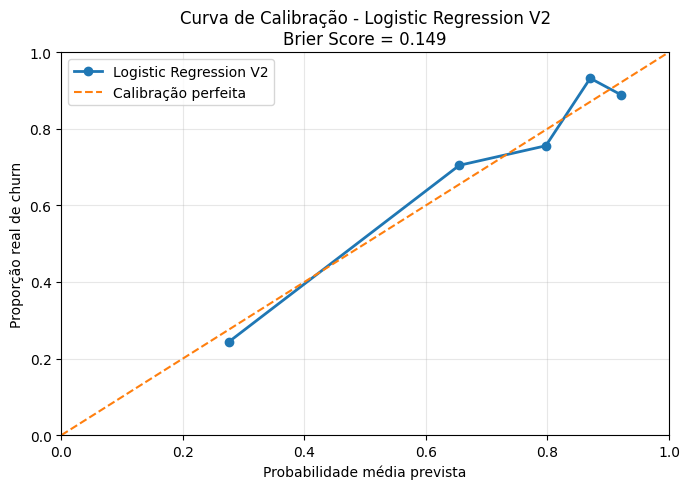

In [0]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# 1. Curva de calibração usando probabilidades OOF
# ============================================================

prob_real, prob_prevista = calibration_curve(
    y,
    proba_oof,
    n_bins=5,
    strategy="quantile"
)

# ============================================================
# 2. Brier Score
# ============================================================

brier = brier_score_loss(
    y,
    proba_oof
)

print(
    "Brier Score:",
    round(brier, 3)
)

# ============================================================
# 3. Gráfico
# ============================================================

fig_cal, ax = plt.subplots(
    figsize=(7, 5)
)

ax.plot(
    prob_prevista,
    prob_real,
    marker="o",
    linewidth=2,
    label="Logistic Regression V2"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Calibração perfeita"
)

ax.set_xlabel(
    "Probabilidade média prevista"
)

ax.set_ylabel(
    "Proporção real de churn"
)

ax.set_title(
    f"Curva de Calibração - Logistic Regression V2\n"
    f"Brier Score = {brier:.3f}"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

ax.grid(alpha=0.3)

ax.legend()

fig_cal.tight_layout()

plt.show()

![image_1790300962493.png](./image_1790300962493.png "image_1790300962493.png")

![image_1790300992014.png](./image_1790300992014.png "image_1790300992014.png")

In [0]:
# ============================================================
# Brier de referência
# modelo ingênuo = taxa média de churn para todos
# ============================================================

prevalencia_churn = y.mean()

prob_baseline = np.repeat(
    prevalencia_churn,
    len(y)
)

brier_baseline = brier_score_loss(
    y,
    prob_baseline
)

brier_skill = (
    1 - brier / brier_baseline
)

print(
    "Taxa de churn:",
    round(prevalencia_churn, 3)
)

print(
    "Brier modelo:",
    round(brier, 3)
)

print(
    "Brier baseline:",
    round(brier_baseline, 3)
)

print(
    "Brier Skill Score:",
    round(brier_skill, 3)
)

Taxa de churn: 0.704
Brier modelo: 0.149
Brier baseline: 0.208
Brier Skill Score: 0.285


Isso significa que a Logistic V2 reduz em aproximadamente 28,5% o erro probabilístico em relação a simplesmente atribuir 70,4% de risco a todo mundo.

Essa comparação é muito mais informativa do que olhar apenas o 0.149.


Criando também a tabela da calibração

E guardando os números por trás do gráfico:


In [0]:
tabela_calibracao = pd.DataFrame({
    "probabilidade_prevista_media":
        prob_prevista,

    "taxa_churn_observada":
        prob_real
})

tabela_calibracao["diferenca"] = (
    tabela_calibracao[
        "taxa_churn_observada"
    ]
    -
    tabela_calibracao[
        "probabilidade_prevista_media"
    ]
)

tabela_calibracao

,probabilidade_prevista_media,taxa_churn_observada,diferenca
0,0.276250,0.244444,-0.031805
1,0.654930,0.704545,0.049615
2,0.797288,0.755556,-0.041732
3,0.870395,0.931818,0.061423
4,0.920731,0.888889,-0.031842


Registrar tudo no MLflow

Como estamos enriquecendo a LogisticRegression_V2, vamos reabrir a mesma Run.


In [0]:
import mlflow

experiment = mlflow.get_experiment_by_name(
    "/Shared/TMW_Churn_Loyalty"
)

runs = mlflow.search_runs(
    experiment_ids=[
        experiment.experiment_id
    ],
    filter_string=(
        "tags.mlflow.runName = "
        "'LogisticRegression_V2'"
    ),
    order_by=[
        "attributes.start_time DESC"
    ],
    max_results=1
)

run_id_v2 = runs.iloc[0]["run_id"]

print(
    "Run encontrada:",
    run_id_v2
)

Run encontrada: 7cb80cf48c4c4986ab57b0b3fd03748d


In [0]:
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(
    run_id=run_id_v2
):

    mlflow.log_metric(
        "brier_score_oof",
        float(brier)
    )

    mlflow.log_metric(
        "brier_baseline",
        float(brier_baseline)
    )

    mlflow.log_metric(
        "brier_skill_score",
        float(brier_skill)
    )

    mlflow.log_figure(
        fig_cal,
        "plots/calibration_curve_v2.png"
    )

    tabela_calibracao.to_csv(
        "/tmp/calibration_table_v2.csv",
        index=False
    )

    mlflow.log_artifact(
        "/tmp/calibration_table_v2.csv",
        artifact_path="calibration"
    )

plt.close(fig_cal)

#### O que dá para concluir neste momento

- A Logistic V2 já apresenta três sinais positivos diferentes:

Discriminação: ROC-AUC CV ≈ 0,794 — consegue ordenar razoavelmente bem usuários de maior e menor risco.

Classificação: no seu holdout, Recall ≈ 0,923 — encontrou grande parte dos churners.

Probabilidade: Brier OOF ≈ 0,149, contra uma referência de aproximadamente 0,208 — as probabilidades acrescentam informação relevante além da taxa média de churn.

- Mas não dá para escrever automaticamente:

"Usuário X tem exatamente 87% de chance de churn."

- Primeiro vamos olhar a forma da curva de calibração. Se os cinco pontos estiverem razoavelmente próximos da diagonal, podemos usar linguagem de probabilidade estimada de churn. Se houver desvios sistemáticos, continuaremos usando predict_proba() para o ranking dos 50, mas provavelmente chamaremos o número de score de risco ou faremos uma segunda etapa de calibração.



![image_1790301248336.png](./image_1790301248336.png "image_1790301248336.png")

O resultado é bom o suficiente para tratarmos o predict_proba() da Logistic V2 como uma probabilidade estimada de churn, com a ressalva de que não é uma probabilidade exata. A curva acompanha razoavelmente bem a diagonal, e o Brier Score = 0,149 reforça essa leitura.

Visualmente, os cinco grupos estão aproximadamente assim:

| Probabilidade média prevista | Churn observado | Leitura             |
| ---------------------------: | --------------: | ------------------- |
|                         ~28% |            ~24% | leve superestimação |
|                         ~65% |            ~71% | leve subestimação   |
|                         ~80% |            ~75% | leve superestimação |
|                         ~87% |            ~93% | subestimação        |
|                         ~92% |            ~89% | leve superestimação |


Ou seja, os desvios parecem ficar, grosso modo, na faixa de 3 a 6 pontos percentuais. Não vemos um comportamento como "modelo prevê 80%, mas apenas 40% churnam", que indicaria calibração ruim.

Há ainda um ponto favorável: a base tem taxa histórica de churn de cerca de 70,4%. Um modelo ingênuo que atribuísse 70,4% a todos teria Brier por volta de 0,208. Portanto:

Brier baseline ≈ 0,208
Brier Logistic V2 = 0,149

redução aproximada do erro probabilístico
≈ 28,5%

Isso é relevante porque mostra que a Logistic V2 não está apenas ordenando clientes; suas probabilidades carregam informação útil.

O que a gente pode inferir:

**A Logistic Regression V2 apresentou calibração satisfatória. A curva de calibração permaneceu próxima da diagonal de calibração perfeita nos diferentes intervalos de probabilidade, indicando correspondência razoável entre as probabilidades previstas e as taxas de churn efetivamente observadas. O Brier Score foi de 0,149, inferior ao valor aproximado de 0,208 obtido por um modelo de referência baseado apenas na prevalência de churn, indicando ganho relevante na qualidade das estimativas probabilísticas.**

E agora podemos responder sua segunda pergunta usando: "probabilidade estimada de churn" em vez de apenas "score de risco".



In [0]:
import pandas as pd
import numpy as np

# ============================================================
# TABELA DE CALIBRAÇÃO - 5 FAIXAS POR QUANTIL
# ============================================================

avaliacao_cal = avaliacao.copy()

# Cria 5 grupos com tamanhos aproximadamente iguais
avaliacao_cal["faixa_calibracao"] = pd.qcut(
    avaliacao_cal["prob_churn"],
    q=5,
    duplicates="drop"
)

# Agregação por faixa
tabela_calibracao_detalhada = (
    avaliacao_cal
    .groupby(
        "faixa_calibracao",
        observed=True
    )
    .agg(
        n_clientes=(
            "churn_real",
            "size"
        ),

        prob_media=(
            "prob_churn",
            "mean"
        ),

        prob_min=(
            "prob_churn",
            "min"
        ),

        prob_max=(
            "prob_churn",
            "max"
        ),

        churn_observado=(
            "churn_real",
            "mean"
        )
    )
    .reset_index()
)

# ============================================================
# ERRO DE CALIBRAÇÃO POR FAIXA
# ============================================================

tabela_calibracao_detalhada["erro_abs"] = (
    tabela_calibracao_detalhada["prob_media"]
    -
    tabela_calibracao_detalhada["churn_observado"]
).abs()

# Peso da faixa no total
total_clientes = len(avaliacao_cal)

tabela_calibracao_detalhada["peso"] = (
    tabela_calibracao_detalhada["n_clientes"]
    / total_clientes
)

# Contribuição de cada faixa para o ECE
tabela_calibracao_detalhada["contrib_ece"] = (
    tabela_calibracao_detalhada["peso"]
    *
    tabela_calibracao_detalhada["erro_abs"]
)

# ============================================================
# ECE - Expected Calibration Error
# ============================================================

ece = (
    tabela_calibracao_detalhada["contrib_ece"]
    .sum()
)

print(
    "ECE:",
    round(ece, 4)
)

print(
    "ECE (%):",
    round(ece * 100, 2),
    "p.p."
)

tabela_calibracao_detalhada

ECE: 0.0432
ECE (%): 4.32 p.p.


,faixa_calibracao,n_clientes,prob_media,prob_min,prob_max,churn_observado,erro_abs,peso,contrib_ece
0,"(0.008220000000000002, 0.534]",45,0.276250,0.009219,0.531589,0.244444,0.031805,0.201794,0.006418
1,"(0.534, 0.742]",44,0.654930,0.537814,0.741729,0.704545,0.049615,0.197309,0.009790
2,"(0.742, 0.847]",45,0.797288,0.742154,0.847226,0.755556,0.041732,0.201794,0.008421
3,"(0.847, 0.896]",44,0.870395,0.847815,0.895799,0.931818,0.061423,0.197309,0.012119
4,"(0.896, 0.99]",45,0.920731,0.896549,0.989732,0.888889,0.031842,0.201794,0.006426


![image_1790301454924.png](./image_1790301454924.png "image_1790301454924.png")

In [0]:
tabela_calibracao_exibicao = (
    tabela_calibracao_detalhada
    .copy()
)

tabela_calibracao_exibicao[
    "prob_media_pct"
] = (
    tabela_calibracao_exibicao[
        "prob_media"
    ] * 100
).round(2)

tabela_calibracao_exibicao[
    "churn_observado_pct"
] = (
    tabela_calibracao_exibicao[
        "churn_observado"
    ] * 100
).round(2)

tabela_calibracao_exibicao[
    "erro_abs_pp"
] = (
    tabela_calibracao_exibicao[
        "erro_abs"
    ] * 100
).round(2)

display(
    tabela_calibracao_exibicao[
        [
            "faixa_calibracao",
            "n_clientes",
            "prob_min",
            "prob_max",
            "prob_media_pct",
            "churn_observado_pct",
            "erro_abs_pp"
        ]
    ]
)

,faixa_calibracao,n_clientes,prob_min,prob_max,prob_media_pct,churn_observado_pct,erro_abs_pp
0,"(0.008220000000000002, 0.534]",45,0.009219,0.531589,27.62,24.44,3.18
1,"(0.534, 0.742]",44,0.537814,0.741729,65.49,70.45,4.96
2,"(0.742, 0.847]",45,0.742154,0.847226,79.73,75.56,4.17
3,"(0.847, 0.896]",44,0.847815,0.895799,87.04,93.18,6.14
4,"(0.896, 0.99]",45,0.896549,0.989732,92.07,88.89,3.18


![image_1790301507730.png](./image_1790301507730.png "image_1790301507730.png")

In [0]:
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(
    run_id=run_id_v2
):

    mlflow.log_metric(
        "ece_oof",
        float(ece)
    )

    tabela_calibracao_detalhada.to_csv(
        "/tmp/calibration_bins_v2.csv",
        index=False
    )

    mlflow.log_artifact(
        "/tmp/calibration_bins_v2.csv",
        artifact_path="calibration"
    )

Com essa tabela, já dá para fechar a avaliação de calibração da Logistic Regression V2 com bem mais segurança.

O ECE calculado a partir dessas cinco faixas é aproximadamente 0,0432, ou seja, 4,32 pontos percentuais de erro médio ponderado de calibração.

A leitura faixa a faixa é:

| Faixa de probabilidade |  N | Prob. média prevista | Churn observado |          Erro | Comportamento |
| ---------------------- | -: | -------------------: | --------------: | ------------: | ------------- |
| 0,8%–53,4%             | 45 |               27,62% |          24,44% |     3,18 p.p. | superestima   |
| 53,4%–74,2%            | 44 |               65,49% |          70,45% |     4,96 p.p. | subestima     |
| 74,2%–84,7%            | 45 |               79,73% |          75,56% |     4,17 p.p. | superestima   |
| 84,7%–89,6%            | 44 |               87,04% |          93,18% | **6,14 p.p.** | subestima     |
| 89,6%–99,0%            | 45 |               92,07% |          88,89% |     3,18 p.p. | superestima   |

O ponto mais interessante é que não existe um viés sistemático em uma única direção. O modelo ora superestima, ora subestima, e todos os desvios ficaram relativamente contidos. O maior está no quarto grupo, em que prevê aproximadamente 87%, mas a taxa real foi 93,2%.

**Resultado consolidado**

Agora temos três evidências complementares:

ROC-AUC CV ≈ 0,794 --> boa capacidade de ordenar risco

Brier Score = 0,149 x baseline ≈ 0,208 --> boa qualidade probabilística relativa

ECE ≈ 0,043 --> erro médio de calibração ≈ 4,3 p.p.

Para uma amostra relativamente pequena, de 223 usuários, vamos classificaria isso como uma calibração satisfatória para o propósito do case.

Isso muda a forma como podemos apresentar a resposta da segunda pergunta. Podemos dizer:

"O modelo estima que o cliente X apresenta 91,7% de probabilidade de churn."

Em vez de limitar a saída a:

"Score de risco = 0,917."

Só manteria a palavra "estimada", porque a calibração valida grupos de usuários, não garante que cada indivíduo com score 0,917 possua literalmente uma chance exata de 91,7%.

Há inclusive uma evidência concreta disso no seu último grupo:

Probabilidade média prevista = 92,07%
Churn realmente observado    = 88,89%

Portanto, uma previsão de ~92% está, historicamente, associada a algo próximo de 89% de churn nessa faixa. A diferença é pequena, mas existe.

Texto pronto para colocar no trabalho

**A calibração das probabilidades da Regressão Logística V2 foi avaliada utilizando probabilidades Out-of-Fold e cinco grupos de tamanho aproximadamente equivalente. O modelo apresentou Brier Score de 0,149 e Expected Calibration Error (ECE) de aproximadamente 0,043, correspondendo a um desvio médio ponderado de 4,3 pontos percentuais entre as probabilidades previstas e as taxas de churn observadas. Os desvios por faixa variaram entre aproximadamente 3,2 e 6,1 pontos percentuais, sem evidência de superestimação ou subestimação sistemática. Os resultados indicam que as probabilidades produzidas pelo modelo apresentam calibração satisfatória para utilização como estimativas de risco de churn.**



#### Scoring operacional

Após a validação, o modelo é retreinado para gerar o ranking operacional de risco.


In [0]:
from sklearn.base import clone

# Reutiliza exatamente a mesma arquitetura da Logistic V2
modelo_logistico_v2_final = clone(
    modelo_logistico_v2
)

# Após validação concluída, refaz o modelo
# usando toda a base histórica disponível
modelo_logistico_v2_final.fit(
    X_v2,
    y
)

print(
    "Modelo final treinado com:",
    len(X_v2),
    "usuários"
)

Modelo final treinado com: 223 usuários


#### Carregar a população operacional

Mas há uma distinção importante para a questão 2

Esse Top 50 responde perfeitamente à pergunta acadêmica usando os 223 usuários do case, mas ainda não é uma lista de clientes sobre os quais você poderia agir hoje.

![image_1790299554507.png](./image_1790299554507.png "image_1790299554507.png")


Todos os usuários dessa base já possuem 90 dias completos de acompanhamento. Portanto, seus resultados de churn já são historicamente conhecidos. A própria view traz idUsuario e idTMWCliente como identificadores e define o churn pela ausência de transações entre D31 e D90.

Para transformar isso em uma aplicação real de retenção, teremos que construir uma segunda view:


Ou seja, todos os usuários dessa base já possuem 90 dias completos de acompanhamento. Portanto, seus resultados de churn já são historicamente conhecidos. A própria view traz idUsuario e idTMWCliente como identificadores e define o churn pela ausência de transações entre D31 e D90.

Para transformar isso em uma aplicação real de retenção, teremos que construir uma segunda view:

![image_1790299611615.png](./image_1790299611615.png "image_1790299611615.png")

A melhor arquitetura é criar a vw_scoring_churn como uma ABT operacional, espelhando exatamente a lógica da base de treinamento, mas com duas diferenças fundamentais:

entram usuários com D30 já completo, mas D90 ainda não completo; não existe tx_31_90 nem churn_90d na view.

No notebook, a base de treinamento exige 90 dias completos após a primeira transação Loyalty e calcula o target usando D31–D90. Já a Logistic V2 utiliza exatamente oito features, incluindo quatro transformações logarítmicas. Essas transformações foram feitas com np.log1p().



![image_1790299969480.png](./image_1790299969480.png "image_1790299969480.png")


![image_1790299999557.png](./image_1790299999557.png "image_1790299999557.png")

In [0]:
%sql

CREATE OR REPLACE TEMP VIEW vw_scoring_churn AS

WITH limites AS (

    SELECT
        MAX(DtCriacao) AS dt_max
    FROM tmw_loyalty.transacoes
),

/* ============================================================
   1. PRIMEIRA ATIVIDADE REAL NO EDUCATION
   ============================================================ */

inicio_education AS (

    SELECT
        u.idUsuario,
        u.idTMWCliente,
        MIN(ec.dtCriacao) AS primeira_atividade_education

    FROM tmw_education.usuarios_tmw u

    INNER JOIN tmw_education.cursos_episodios_completos ec
        ON u.idUsuario = ec.idUsuario

    GROUP BY
        u.idUsuario,
        u.idTMWCliente
),

/* ============================================================
   2. PRIMEIRA TRANSAÇÃO NO LOYALTY
   ============================================================ */

primeira_loyalty AS (

    SELECT
        IdCliente,
        MIN(DtCriacao) AS primeira_transacao_loyalty

    FROM tmw_loyalty.transacoes

    GROUP BY
        IdCliente
),

/* ============================================================
   3. POPULAÇÃO DE SCORING

   Regras:
   - mesma definição de entrada da base de treino
   - D30 já completamente observado
   - D90 ainda NÃO completamente observado

   Portanto:
       30 <= idade_cliente < 90 dias
   ============================================================ */

coorte_scoring AS (

    SELECT
        e.idUsuario,
        e.idTMWCliente,
        e.primeira_atividade_education,
        l.primeira_transacao_loyalty,

        DATEDIFF(
            lim.dt_max,
            l.primeira_transacao_loyalty
        ) AS dias_desde_primeira_loyalty

    FROM inicio_education e

    INNER JOIN primeira_loyalty l
        ON e.idTMWCliente = l.IdCliente

    CROSS JOIN limites lim

    WHERE
        l.primeira_transacao_loyalty
            >= e.primeira_atividade_education

        AND l.primeira_transacao_loyalty
            < DATE_ADD(
                e.primeira_atividade_education,
                90
            )

        /* D30 já observado */
        AND l.primeira_transacao_loyalty
            <= DATE_SUB(lim.dt_max, 30)

        /* D90 ainda não observado */
        AND l.primeira_transacao_loyalty
            > DATE_SUB(lim.dt_max, 90)
),

/* ============================================================
   4. FEATURES LOYALTY — SOMENTE D0-D30
   ============================================================ */

features_transacoes AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        /* transações D0-D7 */
        SUM(
            CASE
                WHEN t.DtCriacao
                        >= c.primeira_transacao_loyalty

                 AND t.DtCriacao
                        <= DATE_ADD(
                            c.primeira_transacao_loyalty,
                            7
                        )

                THEN 1
                ELSE 0
            END
        ) AS tx_0_7,

        /* dias distintos ativos em D0-D30 */
        COUNT(
            DISTINCT CASE
                WHEN t.DtCriacao
                        >= c.primeira_transacao_loyalty

                 AND t.DtCriacao
                        <= DATE_ADD(
                            c.primeira_transacao_loyalty,
                            30
                        )

                THEN DATE(t.DtCriacao)
            END
        ) AS dias_ativos_30d,

        /* última atividade observada até D30 */
        MAX(
            CASE
                WHEN t.DtCriacao
                        >= c.primeira_transacao_loyalty

                 AND t.DtCriacao
                        <= DATE_ADD(
                            c.primeira_transacao_loyalty,
                            30
                        )

                THEN t.DtCriacao
            END
        ) AS ultima_atividade_30d,

        /* pontos acumulados D0-D30 */
        SUM(
            CASE
                WHEN t.DtCriacao
                        >= c.primeira_transacao_loyalty

                 AND t.DtCriacao
                        <= DATE_ADD(
                            c.primeira_transacao_loyalty,
                            30
                        )

                THEN COALESCE(t.QtdePontos, 0)

                ELSE 0
            END
        ) AS pontos_30d

    FROM coorte_scoring c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

/* ============================================================
   5. REMOVE DUPLICIDADE TRANSAÇÃO × PRODUTO
   ============================================================ */

itens_produto AS (

    SELECT DISTINCT
        IdTransacao,
        IdProduto

    FROM tmw_loyalty.transacao_produto
),

/* ============================================================
   6. FEATURES DE PRODUTO — SOMENTE D0-D30
   ============================================================ */

features_produto AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        COUNT(
            DISTINCT ip.IdProduto
        ) AS produtos_distintos_30d,

        SUM(
            CASE
                WHEN LOWER(TRIM(p.DescNomeProduto))
                     = 'presença streak'

                THEN 1
                ELSE 0
            END
        ) AS qtd_streak_30d

    FROM coorte_scoring c

    LEFT JOIN tmw_loyalty.transacoes t
        ON c.idTMWCliente = t.IdCliente

       AND t.DtCriacao
            >= c.primeira_transacao_loyalty

       AND t.DtCriacao
            <= DATE_ADD(
                c.primeira_transacao_loyalty,
                30
            )

    LEFT JOIN itens_produto ip
        ON t.IdTransacao = ip.IdTransacao

    LEFT JOIN tmw_loyalty.produtos p
        ON ip.IdProduto = p.IdProduto

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

/* ============================================================
   7. FEATURES EDUCATION — SOMENTE D0-D30
   ============================================================ */

features_education AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        COUNT(
            DISTINCT ec.idCursoEpisodioCompleto
        ) AS episodios_education_30d,

        COUNT(
            DISTINCT DATE(ec.dtCriacao)
        ) AS dias_ativos_education_30d

    FROM coorte_scoring c

    LEFT JOIN tmw_education.cursos_episodios_completos ec
        ON c.idUsuario = ec.idUsuario

       AND ec.dtCriacao
            >= c.primeira_transacao_loyalty

       AND ec.dtCriacao
            <= DATE_ADD(
                c.primeira_transacao_loyalty,
                30
            )

    GROUP BY
        c.idUsuario,
        c.idTMWCliente
),

/* ============================================================
   8. FEATURES BRUTAS
   ============================================================ */

features_finais AS (

    SELECT
        c.idUsuario,
        c.idTMWCliente,

        c.primeira_atividade_education,
        c.primeira_transacao_loyalty,
        c.dias_desde_primeira_loyalty,

        COALESCE(
            t.dias_ativos_30d,
            0
        ) AS dias_ativos_30d,

        COALESCE(
            30 - DATEDIFF(
                t.ultima_atividade_30d,
                c.primeira_transacao_loyalty
            ),
            30
        ) AS dias_sem_atividade_ate_d30,

        COALESCE(
            p.produtos_distintos_30d,
            0
        ) AS produtos_distintos_30d,

        COALESCE(
            e.dias_ativos_education_30d,
            0
        ) AS dias_ativos_education_30d,

        COALESCE(
            t.tx_0_7,
            0
        ) AS tx_0_7,

        COALESCE(
            t.pontos_30d,
            0
        ) AS pontos_30d,

        COALESCE(
            p.qtd_streak_30d,
            0
        ) AS qtd_streak_30d,

        COALESCE(
            e.episodios_education_30d,
            0
        ) AS episodios_education_30d

    FROM coorte_scoring c

    LEFT JOIN features_transacoes t
        ON c.idUsuario = t.idUsuario

    LEFT JOIN features_produto p
        ON c.idUsuario = p.idUsuario

    LEFT JOIN features_education e
        ON c.idUsuario = e.idUsuario
)

/* ============================================================
   9. DATASET FINAL PARA O MODELO

   Exatamente as 8 features da LogisticRegression_V2.
   LN(1+x) reproduz a transformação np.log1p(x).
   ============================================================ */

SELECT
    idUsuario,
    idTMWCliente,

    primeira_atividade_education,
    primeira_transacao_loyalty,
    dias_desde_primeira_loyalty,

    /* 1 */
    dias_ativos_30d,

    /* 2 */
    dias_sem_atividade_ate_d30,

    /* 3 */
    produtos_distintos_30d,

    /* 4 */
    dias_ativos_education_30d,

    /* 5 */
    LN(1 + tx_0_7)
        AS log_tx_0_7,

    /* 6 */
    LN(1 + pontos_30d)
        AS log_pontos_30d,

    /* 7 */
    LN(1 + qtd_streak_30d)
        AS log_qtd_streak_30d,

    /* 8 */
    LN(1 + episodios_education_30d)
        AS log_episodios_education_30d

FROM features_finais;

#### Algumas validações da view: vw_scoring_churn

In [0]:
%sql

SELECT
    idUsuario,
    COUNT(*) AS qtd

FROM vw_scoring_churn

GROUP BY idUsuario

HAVING COUNT(*) > 1;

idUsuario,qtd


In [0]:
%sql

SELECT
    idUsuario,
    COUNT(*) AS qtd

FROM vw_scoring_churn

GROUP BY idUsuario

HAVING COUNT(*) > 1;

idUsuario,qtd


In [0]:
%sql

SELECT

    SUM(CASE
        WHEN dias_ativos_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_dias_ativos,

    SUM(CASE
        WHEN dias_sem_atividade_ate_d30 IS NULL
        THEN 1 ELSE 0
    END) AS null_recencia,

    SUM(CASE
        WHEN produtos_distintos_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_produtos,

    SUM(CASE
        WHEN dias_ativos_education_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_education,

    SUM(CASE
        WHEN log_tx_0_7 IS NULL
        THEN 1 ELSE 0
    END) AS null_tx,

    SUM(CASE
        WHEN log_pontos_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_pontos,

    SUM(CASE
        WHEN log_qtd_streak_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_streak,

    SUM(CASE
        WHEN log_episodios_education_30d IS NULL
        THEN 1 ELSE 0
    END) AS null_episodios

FROM vw_scoring_churn;

null_dias_ativos,null_recencia,null_produtos,null_education,null_tx,null_pontos,null_streak,null_episodios
0,0,0,0,0,0,0,0


In [0]:
df_scoring = (
    spark
    .table("vw_scoring_churn")
    .toPandas()
)

print(
    "Usuários elegíveis para scoring:",
    len(df_scoring)
)

display(
    df_scoring.head()
)

Usuários elegíveis para scoring: 32


,idUsuario,idTMWCliente,primeira_atividade_education,primeira_transacao_loyalty,dias_desde_primeira_loyalty,dias_ativos_30d,dias_sem_atividade_ate_d30,produtos_distintos_30d,dias_ativos_education_30d,log_tx_0_7,log_pontos_30d,log_qtd_streak_30d,log_episodios_education_30d
0,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,2026-06-09 00:50:13,2026-06-19 00:50:15.089,61,1,30,1,0,0.693147,6.908755,0.0,0.000000
1,42b57f7f-cb02-4b18-b0b9-5dcb9edb472f,2dbe372e-07a2-4e8a-bdbd-777cea490ebc,2026-06-09 12:38:10,2026-06-12 20:20:40.826,68,10,9,9,13,2.708050,7.239933,0.0,3.761200
2,a0961f43-d820-4793-97d8-3d8af02c257f,a2cef762-3cc9-4d22-b2f4-657c1fee9278,2026-05-17 21:26:39,2026-06-01 13:16:06.039,79,2,29,1,2,1.098612,4.615121,0.0,2.079442
3,4a1d9685-bad7-4c69-8141-4acab446fce7,9419c300-6b50-4dbb-a0c9-1007ce9ac3d7,2026-03-31 13:24:20,2026-05-27 16:20:28.161,84,1,30,1,3,0.693147,6.908755,0.0,1.791759
4,b32e9e37-536c-4028-8912-3f8044f37382,8b6ee007-4700-4184-925d-a5b12b480621,2026-05-22 14:46:35,2026-06-09 13:42:13.331,71,13,6,4,0,2.302585,6.478510,0.0,0.000000


In [0]:
print(
    "Usuários distintos:",
    df_scoring["idUsuario"].nunique()
)

print(
    "Clientes distintos:",
    df_scoring["idTMWCliente"].nunique()
)

print(
    "Duplicados idUsuario:",
    df_scoring["idUsuario"]
    .duplicated()
    .sum()
)

Usuários distintos: 32
Clientes distintos: 32
Duplicados idUsuario: 0


#### Montar exatamente o X do scoring


In [0]:
features_modelo_v2 = [
    "dias_ativos_30d",
    "dias_sem_atividade_ate_d30",
    "produtos_distintos_30d",
    "dias_ativos_education_30d",
    "log_tx_0_7",
    "log_pontos_30d",
    "log_qtd_streak_30d",
    "log_episodios_education_30d"
]

X_scoring = (
    df_scoring[
        features_modelo_v2
    ]
    .copy()
)

In [0]:
display(
    X_scoring.isnull().sum()
)

dias_ativos_30d                0
dias_sem_atividade_ate_d30     0
produtos_distintos_30d         0
dias_ativos_education_30d      0
log_tx_0_7                     0
log_pontos_30d                 0
log_qtd_streak_30d             0
log_episodios_education_30d    0
dtype: int64

#### Aplicar à Regressão Logística

In [0]:
df_scoring["prob_churn"] = (
    modelo_logistico_v2_final
    .predict_proba(
        X_scoring
    )[:, 1]
)

In [0]:
df_scoring["prob_churn_pct"] = (
    df_scoring["prob_churn"] * 100
).round(2)

#### Criar o ranking


In [0]:
ranking_churn_atual = (
    df_scoring
    .sort_values(
        "prob_churn",
        ascending=False
    )
    .reset_index(drop=True)
    .copy()
)

ranking_churn_atual[
    "ranking"
] = (
    ranking_churn_atual.index + 1
)

In [0]:
top_50_churn = (
    ranking_churn_atual
    .head(50)
    .copy()
)

#### Para a resposta objetiva da questão


In [0]:
top_50_resumo = top_50_churn[
    [
        "ranking",
        "idUsuario",
        "idTMWCliente",
        "prob_churn_pct"
    ]
]

display(
    top_50_resumo
)

,ranking,idUsuario,idTMWCliente,prob_churn_pct
0,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,96.85
1,2,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.72
2,3,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.02
3,4,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,92.48
4,5,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,91.74
5,6,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,91.74
6,7,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,91.74
7,8,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,91.74
8,9,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,91.74
9,10,d3e0c9d8-d4b4-42f8-b064-62c387a0cfa4,2caa1a94-0e76-4688-9f0b-f9ac7eb7773c,91.74


#### Criando também uma tabela explicativa

Essa é a tabela para ser usada na apresentação do case:


In [0]:
top_50_detalhado = top_50_churn[
    [
        "ranking",
        "idUsuario",
        "idTMWCliente",
        "prob_churn_pct",
        "dias_desde_primeira_loyalty",
        "dias_sem_atividade_ate_d30",
        "dias_ativos_30d",
        "produtos_distintos_30d",
        "dias_ativos_education_30d",
        "log_tx_0_7",
        "log_pontos_30d",
        "log_qtd_streak_30d",
        "log_episodios_education_30d"
    ]
]

display(
    top_50_detalhado
)

,ranking,idUsuario,idTMWCliente,prob_churn_pct,dias_desde_primeira_loyalty,dias_sem_atividade_ate_d30,dias_ativos_30d,produtos_distintos_30d,dias_ativos_education_30d,log_tx_0_7,log_pontos_30d,log_qtd_streak_30d,log_episodios_education_30d
0,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,96.85,70,30,1,4,2,1.609438,8.023225,0.0,1.098612
1,2,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.72,74,30,1,2,0,1.098612,7.601402,0.0,0.000000
2,3,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.02,86,30,1,2,0,1.098612,5.707110,0.0,0.000000
3,4,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,92.48,38,30,1,2,1,1.098612,5.860786,0.0,0.693147
4,5,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,91.74,61,30,1,1,0,0.693147,6.908755,0.0,0.000000
5,6,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,91.74,81,30,1,1,0,0.693147,6.908755,0.0,0.000000
6,7,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,91.74,79,30,1,1,0,0.693147,6.908755,0.0,0.000000
7,8,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,91.74,37,30,1,1,0,0.693147,6.908755,0.0,0.000000
8,9,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,91.74,32,30,1,1,0,0.693147,6.908755,0.0,0.000000
9,10,d3e0c9d8-d4b4-42f8-b064-62c387a0cfa4,2caa1a94-0e76-4688-9f0b-f9ac7eb7773c,91.74,48,30,1,1,0,0.693147,6.908755,0.0,0.000000


#### Adicionar faixa de risco
- Baixo < 30%
- Médio 30% a 85%
- Alto >= 85%

In [0]:
import numpy as np

ranking_churn_atual[
    "faixa_risco"
] = np.select(
    [
        ranking_churn_atual[
            "prob_churn"
        ] < 0.30,

        ranking_churn_atual[
            "prob_churn"
        ] < 0.85
    ],
    [
        "BAIXO",
        "MEDIO"
    ],
    default="ALTO"
)

In [0]:
top_50_churn = (
    ranking_churn_atual
    .head(50)
    .copy()
)

In [0]:
display(
    top_50_churn[
        [
            "ranking",
            "idUsuario",
            "idTMWCliente",
            "prob_churn_pct",
            "faixa_risco"
        ]
    ]
)

,ranking,idUsuario,idTMWCliente,prob_churn_pct,faixa_risco
0,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,96.85,ALTO
1,2,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.72,ALTO
2,3,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.02,ALTO
3,4,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,92.48,ALTO
4,5,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,91.74,ALTO
5,6,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,91.74,ALTO
6,7,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,91.74,ALTO
7,8,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,91.74,ALTO
8,9,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,91.74,ALTO
9,10,d3e0c9d8-d4b4-42f8-b064-62c387a0cfa4,2caa1a94-0e76-4688-9f0b-f9ac7eb7773c,91.74,ALTO


#### Algumas estatísticas muito úteis

Antes mesmo de olhar os 50 nomes:


In [0]:
print(
    "Total elegível:",
    len(ranking_churn_atual)
)

print(
    "Probabilidade média:",
    round(
        ranking_churn_atual[
            "prob_churn"
        ].mean() * 100,
        2
    ),
    "%"
)

print(
    "Mediana:",
    round(
        ranking_churn_atual[
            "prob_churn"
        ].median() * 100,
        2
    ),
    "%"
)

print(
    "Risco alto:",
    (
        ranking_churn_atual[
            "faixa_risco"
        ] == "ALTO"
    ).sum()
)

Total elegível: 32
Probabilidade média: 80.11 %
Mediana: 87.06 %
Risco alto: 19


In [0]:
display(
    ranking_churn_atual[
        "faixa_risco"
    ]
    .value_counts()
    .rename_axis(
        "faixa_risco"
    )
    .reset_index(
        name="usuarios"
    )
)

,faixa_risco,usuarios
0,ALTO,19
1,MEDIO,12
2,BAIXO,1


#### Salvar o ranking como tabela no Databricks



In [0]:
spark_top50 = spark.createDataFrame(
    top_50_churn
)

In [0]:
(
    spark_top50
    .write
    .mode("overwrite")
    .saveAsTable(
        "top_50_churn_loyalty"
    )
)

In [0]:
spark_ranking = spark.createDataFrame(
    ranking_churn_atual
)

(
    spark_ranking
    .write
    .mode("overwrite")
    .saveAsTable(
        "scoring_churn_loyalty"
    )
)

#### Registrar no MLflow

Acrescentando ao modelo vencedor: Regressão Logística

In [0]:
import mlflow

top_50_churn.to_csv(
    "/tmp/top_50_scoring_churn.csv",
    index=False
)

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(
    run_id=run_id_v2
):

    mlflow.log_artifact(
        "/tmp/top_50_scoring_churn.csv",
        artifact_path="scoring"
    )

    mlflow.log_metric(
        "scoring_population_size",
        len(ranking_churn_atual)
    )

    mlflow.log_metric(
        "scoring_high_risk_users",
        int(
            (
                ranking_churn_atual[
                    "faixa_risco"
                ] == "ALTO"
            ).sum()
        )
    )

Um detalhe metodológico importante: vamos chamar essa lista de "Top 50 usuários elegíveis atualmente para intervenção segundo a probabilidade estimada de churn entre D31 e D90". Isso deixa claro que o ranking se refere à população da vw_scoring_churn, isto é, clientes que já completaram D30, mas cujo resultado D90 ainda não é conhecido.



#### Deixando o ranking mais explicável


In [0]:
top_50_detalhado = top_50_churn[
    [
        "ranking",
        "idUsuario",
        "idTMWCliente",
        "prob_churn_pct",
        "dias_sem_atividade_ate_d30",
        "dias_ativos_30d",
        "produtos_distintos_30d",
        "log_episodios_education_30d",
        "dias_ativos_education_30d"
    ]
]

display(top_50_detalhado)

,ranking,idUsuario,idTMWCliente,prob_churn_pct,dias_sem_atividade_ate_d30,dias_ativos_30d,produtos_distintos_30d,log_episodios_education_30d,dias_ativos_education_30d
0,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,96.85,30,1,4,1.098612,2
1,2,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.72,30,1,2,0.000000,0
2,3,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.02,30,1,2,0.000000,0
3,4,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,92.48,30,1,2,0.693147,1
4,5,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,91.74,30,1,1,0.000000,0
5,6,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,91.74,30,1,1,0.000000,0
6,7,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,91.74,30,1,1,0.000000,0
7,8,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,91.74,30,1,1,0.000000,0
8,9,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,91.74,30,1,1,0.000000,0
9,10,d3e0c9d8-d4b4-42f8-b064-62c387a0cfa4,2caa1a94-0e76-4688-9f0b-f9ac7eb7773c,91.74,30,1,1,0.000000,0


#### Agora conseguimos responder não apenas:

"O usuário X tem 92% de risco."

mas:

"O usuário X apresenta 92% de risco, tendo ficado 27 dias sem atividade até D30, utilizado o Loyalty em apenas dois dias distintos e apresentado pouca atividade no Education."

Isso é muito mais útil para negócio.


Podemos também classificá-los nas faixas definidas



In [0]:
def classificar_risco(prob):

    if prob < 0.30:
        return "BAIXO"

    elif prob < 0.85:
        return "MEDIO"

    else:
        return "ALTO"


ranking_churn_atual["faixa_risco"] = (
    ranking_churn_atual["prob_churn"]
    .apply(classificar_risco)
)

In [0]:
top_50_churn = (
    ranking_churn_atual
    .head(50)
)

display(
    top_50_churn[
        [
            "ranking",
            "idUsuario",
            "idTMWCliente",
            "prob_churn_pct",
            "faixa_risco"
        ]
    ]
)

,ranking,idUsuario,idTMWCliente,prob_churn_pct,faixa_risco
0,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,96.85,ALTO
1,2,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.72,ALTO
2,3,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.02,ALTO
3,4,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,92.48,ALTO
4,5,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,91.74,ALTO
5,6,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,91.74,ALTO
6,7,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,91.74,ALTO
7,8,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,91.74,ALTO
8,9,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,91.74,ALTO
9,10,d3e0c9d8-d4b4-42f8-b064-62c387a0cfa4,2caa1a94-0e76-4688-9f0b-f9ac7eb7773c,91.74,ALTO


E registrando o Top 50 no MLflow


In [0]:
top_50_churn.to_csv(
    "/tmp/top_50_churn.csv",
    index=False
)

if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(
    run_id=run_id_v2
):

    mlflow.log_artifact(
        "/tmp/top_50_churn.csv",
        artifact_path="scoring"
    )

In [0]:
df_scoring["prob_churn"] = (
    modelo_logistico_v2
    .predict_proba(X_scoring)[:, 1]
)

In [0]:
df_scoring["prob_churn_pct"] = (
    df_scoring["prob_churn"] * 100
).round(2)

In [0]:
top_50_scoring = (
    df_scoring
    .sort_values(
        "prob_churn",
        ascending=False
    )
    .head(50)
    .copy()
)

top_50_scoring["ranking"] = (
    range(
        1,
        len(top_50_scoring) + 1
    )
)

In [0]:
display(
    top_50_scoring[
        [
            "ranking",
            "idUsuario",
            "idTMWCliente",
            "prob_churn_pct",
            "dias_sem_atividade_ate_d30",
            "dias_ativos_30d",
            "produtos_distintos_30d",
            "dias_ativos_education_30d"
        ]
    ]
)

,ranking,idUsuario,idTMWCliente,prob_churn_pct,dias_sem_atividade_ate_d30,dias_ativos_30d,produtos_distintos_30d,dias_ativos_education_30d
18,1,f7ae6b7f-a4fa-47c2-aba6-b4c01655a63d,e6128ff2-dd02-499e-befe-108705324555,95.36,30,1,4,2
5,2,e466da89-4c1c-41d2-8183-3a5507a7e02c,d646ff94-d663-420b-bf0f-609f817b5f81,94.54,30,1,2,0
23,3,b5ef3204-7ffe-4bfc-a71a-b8e8d9e24590,2558d88c-39b4-45e1-8a63-28bc1ab350f2,94.02,30,1,2,0
30,4,b7c1fcfb-31da-44a4-80ae-a2f5bb8cf8e5,1dc954ac-46ab-4aab-99d9-d374a6c5d2e6,93.15,30,1,1,0
9,5,b720d11a-4d9e-4a04-a88a-25ed72bd7f55,482ea22d-b969-44ee-8f34-59e1609e9d91,93.02,30,1,2,1
0,6,7d171861-901f-4c2b-9db8-9c7e0030408b,a61f1c0f-1e9b-4b85-9681-4c0f0e700cdd,92.54,30,1,1,0
26,7,5e67171b-ccb6-4517-9054-4fdc80821778,dd3654e0-dc7b-4dcc-9f9d-8342456a3fef,92.54,30,1,1,0
19,8,79ad1c9d-847a-4f33-97a7-40233f2ad914,f2494f58-dbfd-4b79-9330-fb04ddc3f7fe,92.54,30,1,1,0
12,9,2358493e-02d3-4632-9519-f46184c7317b,aa2d8fb3-b986-4f48-95d3-f75ac0ac25b8,92.54,30,1,1,0
31,10,cfee8568-0b2d-485b-80a1-e815bc5abcce,8635bd71-e9a0-426d-9a3b-925d92d3a4ab,92.54,30,1,1,0


Agora sim a segunda pergunta deixa de ser retrospectiva e vira ação de negócio:

"Estes são os 50 clientes atualmente no período de risco D31–D89 que apresentam maior probabilidade estimada de churn antes de D90."

E há um ponto metodológico importante: podemos esses valores de "probabilidade estimada pelo modelo", não de probabilidade absoluta de o usuário sair. O modelo tem boa capacidade de ordenação, mas uma probabilidade de 0,87 só deve ser interpretada literalmente como "87% de chance" se a calibração das probabilidades também estiver adequada.



## L - Conclusão final — Case TMW Churn Loyalty


#### Quais características estão associadas ao churn? 

O principal padrão é a falta de continuidade nos primeiros 30 dias. A Logistic Regression V2 mostra que dias_sem_atividade_ate_d30 é o principal fator associado ao aumento do risco, enquanto dias_ativos_30d atua fortemente no sentido contrário. Maior atividade inicial (log_tx_0_7) e maior consumo de episódios no Education também estão associados à retenção. Em síntese: o comportamento de recorrência e persistência é mais importante do que simplesmente acumular pontos ou realizar grande volume de interações isoladas.

#### Quais usuários apresentam maior probabilidade de churn?

 Construímos uma população operacional contendo clientes que já completaram D30, mas ainda não chegaram ao D90, e aplicamos a Logistic V2. No momento existem 32 usuários elegíveis, portanto o resultado correto é um ranking desses 32, e não de 50. Desses, 19 apresentam probabilidade estimada ≥ 85%, sendo classificados como alto risco. O maior risco estimado é 96,85%, seguido de 94,72%, 94,02%, 92,48% e 91,74%.

A qualidade dessa interpretação também foi validada. O modelo apresentou ROC-AUC médio de aproximadamente 0,794, Brier Score de 0,149 e ECE de aproximadamente 4,32 pontos percentuais. Portanto, os valores podem ser apresentados como probabilidades estimadas de churn, mantendo essa terminologia — não como certezas individuais.

#### Conclusão

O modelo identificou que o churn está principalmente associado à baixa persistência de uso durante os primeiros 30 dias após a entrada no Loyalty. Usuários que permanecem longos períodos sem atividade e utilizam a plataforma em poucos dias distintos apresentam maior risco de abandono, enquanto maior recorrência, atividade inicial e engajamento com conteúdos do Education estão associados à retenção.

A aplicação da Logistic Regression V2 à população atualmente elegível para scoring identificou 32 usuários entre D30 e D89, dos quais 19 apresentam probabilidade estimada de churn igual ou superior a 85%. O maior risco estimado foi de 96,85%. A calibração do modelo apresentou Brier Score de 0,149 e ECE de aproximadamente 4,32 pontos percentuais, indicando correspondência satisfatória entre as probabilidades estimadas e as taxas de churn observadas.

